# Descriptive Analysis of Questions Q1 to Q8

In this section, a descriptive statistical analysis is performed for questions Q1 to Q8 (including their numerical sub-questions) from the dataset `clean_data.csv`. For each question, the mean, standard deviation, minimum, maximum, mode, and frequency of the mode are calculated. In the `clean_data.csv` file, values representing "no answer" (originally -99) have already been treated as missing values (NaN).

# Comprehensive EDA: Beer Consumption Survey Analysis (Q1-Q8)

## Executive Summary
This notebook provides a comprehensive exploratory data analysis (EDA) of beer consumption survey data, focusing on questions Q1 through Q8. The analysis follows a structured approach to understand consumer behavior patterns, preferences, and decision-making factors in beer consumption.

## Table of Contents
1. **Data Overview & Quality Check**
2. **Descriptive Statistics Summary** 
3. **Consumer Behavior Patterns** (Q1, Q2, Q4)
4. **Attitudes & Involvement** (Q6, Q7)
5. **Purchase Decision Factors** (Q8)
6. **Correlation & Relationship Analysis**
7. **Consumer Segmentation**
8. **Key Insights & Recommendations**

---

# 1. Data Overview & Quality Check

In [1]:
# Import comprehensive libraries for EDA
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from scipy.stats import skew, kurtosis, chi2_contingency
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
import warnings
warnings.filterwarnings('ignore')

# Set plotting parameters
plt.style.use('default')
sns.set_palette("husl")
plt.rcParams['figure.figsize'] = (12, 8)
plt.rcParams['font.size'] = 10
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0.3

# Load the dataset
file_path = '../../src/llm/clean_data.csv'
print(f"Loading data from: {file_path}")
df = pd.read_csv(file_path)

print("\n" + "="*60)
print("DATASET OVERVIEW")
print("="*60)

# Basic dataset information
print(f"Dataset shape: {df.shape[0]:,} rows × {df.shape[1]} columns")
print(f"Memory usage: {df.memory_usage(deep=True).sum() / 1024**2:.2f} MB")
print(f"Data types:")
print(df.dtypes.value_counts())

# Display first few rows
print("\nFirst 5 rows:")
print(df.head())

# Column overview
print("\nColumn names:")
for i, col in enumerate(df.columns, 1):
    print(f"{i:2d}. {col}")

Loading data from: ../../src/llm/clean_data.csv

DATASET OVERVIEW
Dataset shape: 488 rows × 83 columns
Memory usage: 0.31 MB
Data types:
float64    81
int64       2
Name: count, dtype: int64

First 5 rows:
   Q1  Q2A  Q2B  Q2C  Q2D  Q2E  Q2F  Q2G  Q4A  Q4B  ...  Q12I  Q13  Q14  Q15  \
0   5    2  2.0  1.0  1.0  1.0  2.0  1.0  2.0  2.0  ...   3.0  2.0  6.0  1.0   
1   3    2  2.0  1.0  1.0  2.0  2.0  1.0  2.0  2.0  ...   2.0  1.0  6.0  1.0   
2   3    3  3.0  2.0  2.0  1.0  2.0  2.0  3.0  2.0  ...   4.0  2.0  8.0  2.0   
3   3    2  2.0  1.0  2.0  2.0  2.0  1.0  2.0  2.0  ...   2.0  1.0  5.0  1.0   
4   2    2  3.0  1.0  2.0  3.0  3.0  3.0  3.0  3.0  ...   5.0  1.0  5.0  1.0   

   Q16  Q17A  Q17B  Q17C  Q17D  Q17E  
0  3.0   0.0   0.0   1.0   0.0   0.0  
1  3.0   0.0   0.0   1.0   0.0   0.0  
2  1.0   0.0   0.0   0.0   1.0   0.0  
3  3.0   0.0   0.0   1.0   0.0   0.0  
4  3.0   0.0   0.0   1.0   0.0   0.0  

[5 rows x 83 columns]

Column names:
 1. Q1
 2. Q2A
 3. Q2B
 4. Q2C
 5. Q2D
 6


MISSING VALUES ANALYSIS
Columns with missing values: 81 out of 83
Total missing values: 2,958
Overall completion rate: 92.7%

Missing values by column:
  Q12H            :  140 ( 28.7%)
  Q12D            :  115 ( 23.6%)
  Q12C            :   99 ( 20.3%)
  Q12G            :   99 ( 20.3%)
  Q8E             :   97 ( 19.9%)
  Q12A            :   97 ( 19.9%)
  Q12F            :   94 ( 19.3%)
  Q12E            :   83 ( 17.0%)
  Q12B            :   83 ( 17.0%)
  Q9E             :   78 ( 16.0%)
  Q8H             :   76 ( 15.6%)
  Q9D             :   75 ( 15.4%)
  Q8I             :   70 ( 14.3%)
  Q8G             :   68 ( 13.9%)
  Q8D             :   68 ( 13.9%)
  Q8F             :   66 ( 13.5%)
  Q8J             :   65 ( 13.3%)
  Q8B             :   65 ( 13.3%)
  Q12I            :   63 ( 12.9%)
  Q9L             :   57 ( 11.7%)
  Q9F             :   56 ( 11.5%)
  Q8K             :   55 ( 11.3%)
  Q8L             :   52 ( 10.7%)
  Q11F            :   48 (  9.8%)
  Q11A            :   48 (  9.8

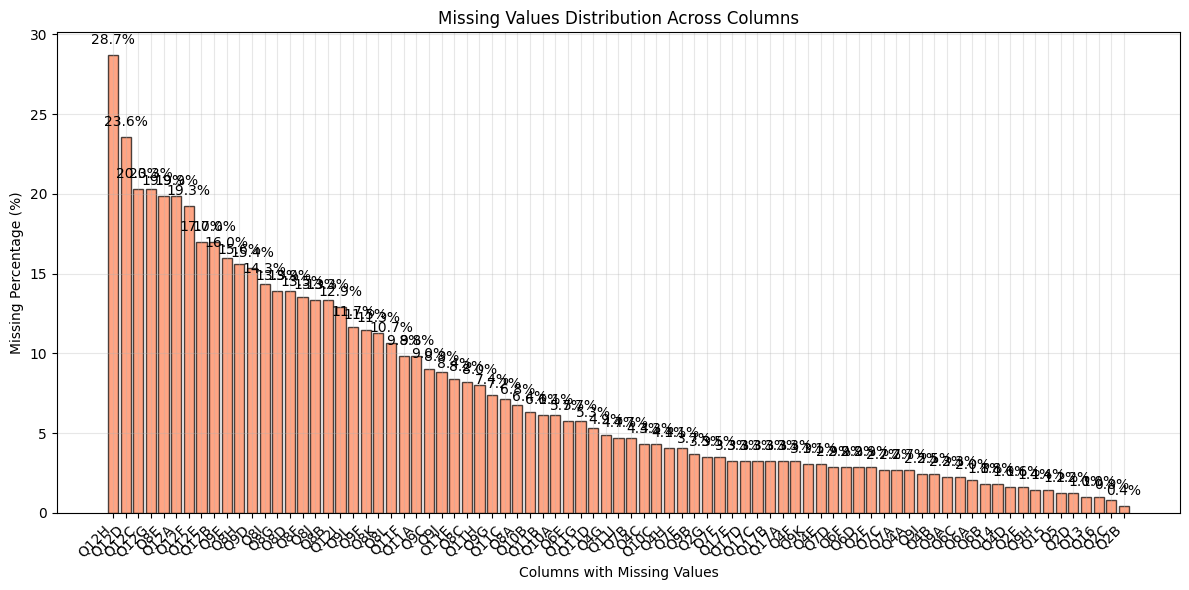

In [2]:
# Comprehensive Missing Values Analysis
print("\n" + "="*60)
print("MISSING VALUES ANALYSIS")
print("="*60)

# Calculate missing values for all columns
missing_stats = pd.DataFrame({
    'Column': df.columns,
    'Missing_Count': df.isnull().sum(),
    'Missing_Percent': (df.isnull().sum() / len(df)) * 100,
    'Data_Type': df.dtypes
})
missing_stats['Has_Missing'] = missing_stats['Missing_Count'] > 0
missing_stats = missing_stats.sort_values('Missing_Percent', ascending=False)

print(f"Columns with missing values: {missing_stats['Has_Missing'].sum()} out of {len(df.columns)}")
print(f"Total missing values: {missing_stats['Missing_Count'].sum():,}")
print(f"Overall completion rate: {((df.size - missing_stats['Missing_Count'].sum()) / df.size) * 100:.1f}%")

# Display missing values summary
if missing_stats['Missing_Count'].sum() > 0:
    print("\nMissing values by column:")
    missing_cols = missing_stats[missing_stats['Has_Missing']]
    for _, row in missing_cols.iterrows():
        print(f"  {row['Column']:15} : {row['Missing_Count']:4d} ({row['Missing_Percent']:5.1f}%)")
else:
    print("\nNo missing values found in the dataset!")

# Visualize missing values pattern
if missing_stats['Missing_Count'].sum() > 0:
    plt.figure(figsize=(12, 6))
    missing_cols = missing_stats[missing_stats['Has_Missing']]
    plt.bar(range(len(missing_cols)), missing_cols['Missing_Percent'], 
            color='coral', alpha=0.7, edgecolor='black')
    plt.xlabel('Columns with Missing Values')
    plt.ylabel('Missing Percentage (%)')
    plt.title('Missing Values Distribution Across Columns')
    plt.xticks(range(len(missing_cols)), missing_cols['Column'], rotation=45, ha='right')
    
    # Add percentage labels on bars
    for i, pct in enumerate(missing_cols['Missing_Percent']):
        plt.text(i, pct + 0.5, f'{pct:.1f}%', ha='center', va='bottom')
    
    plt.tight_layout()
    plt.show()
else:
    print("\nNo missing values visualization needed - dataset is complete!")

In [3]:
# Define Question Structure and Mapping
print("\n" + "="*60)
print("SURVEY QUESTION STRUCTURE")
print("="*60)

# Define comprehensive question mapping
question_mapping = {
    'Q1': {
        'description': 'Beer Consumption Frequency',
        'scale': 'Ordinal (1-5)',
        'labels': ['Never', 'Rarely (few times/year)', 'Occasionally (few times/month)', 
                  'Regularly (several times/week)', 'Frequently (daily/almost daily)']
    },
    'Q2': {
        'description': 'Beer Type Preferences (A-G)',
        'scale': 'Likert (1-5)', 
        'labels': ['Dislike strongly', 'Dislike', 'Neutral', 'Like', 'Like strongly'],
        'subcategories': ['Q2A', 'Q2B', 'Q2C', 'Q2D', 'Q2E', 'Q2F', 'Q2G']
    },
    'Q3': {
        'description': 'Brand Preferences (Text)',
        'scale': 'Nominal/Text',
        'note': 'Excluded from quantitative analysis'
    },
    'Q4': {
        'description': 'Purchase Channel Preferences (A-H)',
        'scale': 'Likert (1-5)',
        'labels': ['Never', 'Rarely', 'Sometimes', 'Often', 'Always'],
        'subcategories': ['Q4A', 'Q4B', 'Q4C', 'Q4D', 'Q4E', 'Q4F', 'Q4G', 'Q4H']
    },
    'Q5': {
        'description': 'Alcohol-free Beer Consumption',
        'scale': 'Ordinal (1-5)',
        'labels': ['Never', 'Rarely', 'Sometimes', 'Often', 'Always']
    },
    'Q6': {
        'description': 'Beer Involvement/Attitudes (A-F)',
        'scale': 'Likert (1-5)',
        'labels': ['Strongly disagree', 'Disagree', 'Neutral', 'Agree', 'Strongly agree'],
        'subcategories': ['Q6A', 'Q6B', 'Q6C', 'Q6D', 'Q6E', 'Q6F']
    },
    'Q7': {
        'description': 'Health/Environmental Consciousness (A-F)',
        'scale': 'Likert (1-5)',
        'labels': ['Strongly disagree', 'Disagree', 'Neutral', 'Agree', 'Strongly agree'],
        'subcategories': ['Q7A', 'Q7B', 'Q7C', 'Q7D', 'Q7E', 'Q7F']
    },
    'Q8': {
        'description': 'Purchase Decision Factors (A-L)',
        'scale': 'Importance (1-5)',
        'labels': ['Not important', 'Slightly important', 'Moderately important', 
                  'Very important', 'Extremely important'],
        'subcategories': ['Q8A', 'Q8B', 'Q8C', 'Q8D', 'Q8E', 'Q8F', 'Q8G', 'Q8H', 'Q8I', 'Q8J', 'Q8K', 'Q8L']
    }
}

# Display question structure
for q_num, q_info in question_mapping.items():
    print(f"\n{q_num}: {q_info['description']}")
    print(f"   Scale: {q_info['scale']}")
    if 'subcategories' in q_info:
        print(f"   Subcategories: {', '.join(q_info['subcategories'])}")
    if 'note' in q_info:
        print(f"   Note: {q_info['note']}")

# Check which columns are actually present in the dataset
print("\n" + "="*60)
print("COLUMN AVAILABILITY CHECK")
print("="*60)

analysis_columns = []
for q_num, q_info in question_mapping.items():
    if q_num == 'Q3':  # Skip text question
        continue
    elif 'subcategories' in q_info:
        for subcat in q_info['subcategories']:
            if subcat in df.columns:
                analysis_columns.append(subcat)
            else:
                print(f"⚠️  Missing column: {subcat}")
    else:
        if q_num in df.columns:
            analysis_columns.append(q_num)
        else:
            print(f"⚠️  Missing column: {q_num}")

print(f"\nColumns available for analysis: {len(analysis_columns)}")
print(f"Analysis columns: {analysis_columns}")


SURVEY QUESTION STRUCTURE

Q1: Beer Consumption Frequency
   Scale: Ordinal (1-5)

Q2: Beer Type Preferences (A-G)
   Scale: Likert (1-5)
   Subcategories: Q2A, Q2B, Q2C, Q2D, Q2E, Q2F, Q2G

Q3: Brand Preferences (Text)
   Scale: Nominal/Text
   Note: Excluded from quantitative analysis

Q4: Purchase Channel Preferences (A-H)
   Scale: Likert (1-5)
   Subcategories: Q4A, Q4B, Q4C, Q4D, Q4E, Q4F, Q4G, Q4H

Q5: Alcohol-free Beer Consumption
   Scale: Ordinal (1-5)

Q6: Beer Involvement/Attitudes (A-F)
   Scale: Likert (1-5)
   Subcategories: Q6A, Q6B, Q6C, Q6D, Q6E, Q6F

Q7: Health/Environmental Consciousness (A-F)
   Scale: Likert (1-5)
   Subcategories: Q7A, Q7B, Q7C, Q7D, Q7E, Q7F

Q8: Purchase Decision Factors (A-L)
   Scale: Importance (1-5)
   Subcategories: Q8A, Q8B, Q8C, Q8D, Q8E, Q8F, Q8G, Q8H, Q8I, Q8J, Q8K, Q8L

COLUMN AVAILABILITY CHECK

Columns available for analysis: 41
Analysis columns: ['Q1', 'Q2A', 'Q2B', 'Q2C', 'Q2D', 'Q2E', 'Q2F', 'Q2G', 'Q4A', 'Q4B', 'Q4C', 'Q4D', 'Q

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import scipy.stats as stats
from scipy.stats import skew, kurtosis

# Enhanced Statistical Analysis Functions
def calculate_advanced_stats(series, confidence_level=0.95):
    """
    Calculate comprehensive descriptive statistics for a series
    """
    clean_series = pd.to_numeric(series, errors='coerce').dropna()
    
    if len(clean_series) == 0:
        return {
            'count': 0, 'mean': np.nan, 'std': np.nan, 'min': np.nan, 'max': np.nan,
            'q25': np.nan, 'median': np.nan, 'q75': np.nan, 'skewness': np.nan,
            'kurtosis': np.nan, 'ci_lower': np.nan, 'ci_upper': np.nan,
            'missing_count': len(series), 'missing_percent': 100.0
        }
    
    # Basic statistics
    count = len(clean_series)
    mean_val = clean_series.mean()
    std_val = clean_series.std()
    min_val = clean_series.min()
    max_val = clean_series.max()
    
    # Quantiles
    q25 = clean_series.quantile(0.25)
    median = clean_series.median()
    q75 = clean_series.quantile(0.75)
    
    # Shape statistics
    skewness = skew(clean_series)
    kurt = kurtosis(clean_series)
    
    # Confidence interval for mean
    alpha = 1 - confidence_level
    ci_lower, ci_upper = stats.t.interval(confidence_level, count-1, 
                                         loc=mean_val, 
                                         scale=stats.sem(clean_series))
    
    # Missing values
    missing_count = len(series) - count
    missing_percent = (missing_count / len(series)) * 100
    
    return {
        'count': count,
        'mean': mean_val,
        'std': std_val,
        'min': min_val,
        'max': max_val,
        'q25': q25,
        'median': median,
        'q75': q75,
        'skewness': skewness,
        'kurtosis': kurt,
        'ci_lower': ci_lower,
        'ci_upper': ci_upper,
        'missing_count': missing_count,
        'missing_percent': missing_percent
    }

def create_distribution_plots(series, title, scale_labels=None):
    """
    Create comprehensive distribution plots for a variable
    """
    clean_series = pd.to_numeric(series, errors='coerce').dropna()
    
    if len(clean_series) == 0:
        print(f"No valid data for {title}")
        return
    
    fig, axes = plt.subplots(2, 2, figsize=(15, 10))
    fig.suptitle(f'Distribution Analysis: {title}', fontsize=16, fontweight='bold')
    
    # Histogram with KDE
    axes[0,0].hist(clean_series, bins='auto', alpha=0.7, color='skyblue', edgecolor='black')
    axes[0,0].axvline(clean_series.mean(), color='red', linestyle='--', 
                     label=f'Mean: {clean_series.mean():.2f}')
    axes[0,0].axvline(clean_series.median(), color='green', linestyle='--', 
                     label=f'Median: {clean_series.median():.2f}')
    axes[0,0].set_title('Histogram')
    axes[0,0].set_xlabel('Value')
    axes[0,0].set_ylabel('Frequency')
    axes[0,0].legend()
    axes[0,0].grid(True, alpha=0.3)
    
    # Box plot
    box_plot = axes[0,1].boxplot(clean_series, patch_artist=True)
    box_plot['boxes'][0].set_facecolor('lightblue')
    axes[0,1].set_title('Box Plot')
    axes[0,1].set_ylabel('Value')
    axes[0,1].grid(True, alpha=0.3)
    
    # Q-Q plot
    stats.probplot(clean_series, dist="norm", plot=axes[1,0])
    axes[1,0].set_title('Q-Q Plot (Normal Distribution)')
    axes[1,0].grid(True, alpha=0.3)
    
    # Value counts bar plot
    value_counts = clean_series.value_counts().sort_index()
    bars = axes[1,1].bar(value_counts.index, value_counts.values, 
                        color='lightcoral', alpha=0.7, edgecolor='black')
    axes[1,1].set_title('Value Counts')
    axes[1,1].set_xlabel('Value')
    axes[1,1].set_ylabel('Count')
    axes[1,1].grid(True, alpha=0.3)
    
    # Add value labels on bars if not too many
    if len(value_counts) <= 15:
        for bar in bars:
            height = bar.get_height()
            axes[1,1].text(bar.get_x() + bar.get_width()/2., height + 0.5,
                          f'{int(height)}', ha='center', va='bottom')
    
    # Set x-axis labels if scale_labels provided
    if scale_labels:
        for ax in [axes[0,0], axes[0,1], axes[1,1]]:
            if hasattr(ax, 'set_xticklabels'):
                try:
                    current_ticks = ax.get_xticks()
                    if len(current_ticks) <= len(scale_labels):
                        ax.set_xticks(range(1, len(scale_labels)+1))
                        ax.set_xticklabels(scale_labels, rotation=45, ha='right')
                except:
                    pass
    
    plt.tight_layout()
    plt.show()
    
    return fig

# Umfassende Univariate Analyse (Q1-Q8)

In diesem Abschnitt führen wir eine detaillierte univariate Analyse für alle Fragen Q1 bis Q8 durch. Die Analyse umfasst:

- **Erweiterte deskriptive Statistiken** (Schiefe, Kurtosis, Quantile, Konfidenzintervalle)
- **Analyse fehlender Werte**
- **Verteilungsvisualisierungen** (Histogramm, Boxplot, Q-Q-Plot, Häufigkeitsdiagramm)
- **Inhaltliche Interpretation** der Ergebnisse

Wir analysieren systematisch jede Fragengruppe mit ihren spezifischen Skalen und Bedeutungen.

In [5]:
# Load questionnaire reference data for better interpretation
try:
    fragebogen_df = pd.read_csv('../../data/fragebogen.csv', sep=';', encoding='utf-8')
    print("Fragebogen-Referenzdaten erfolgreich geladen")
    print(f"Verfügbare Spalten: {list(fragebogen_df.columns)}")
    print("\nErste Zeilen der Fragebogen-Daten:")
    print(fragebogen_df.head())
except Exception as e:
    print(f"Hinweis: Fragebogen-Referenzdaten konnten nicht geladen werden: {e}")
    fragebogen_df = None

Fragebogen-Referenzdaten erfolgreich geladen
Verfügbare Spalten: ['variable,question,options']

Erste Zeilen der Fragebogen-Daten:
                           variable,question,options
0  Q0,"Trinken Sie alkoholhaltiges oder alkoholfr...
1  Q1,"Wie häufig trinken Sie grundsätzlich alkoh...
2  Q2A,"in Gesellschaft bei Freunden/Familie","['...
3  Q2B,"auf privaten Partys oder Feiern","['nie(1...
4  Q2C,"zuhause beim Essen","['nie(1)', 'gelegent...

Verfügbare Spalten: ['variable,question,options']

Erste Zeilen der Fragebogen-Daten:
                           variable,question,options
0  Q0,"Trinken Sie alkoholhaltiges oder alkoholfr...
1  Q1,"Wie häufig trinken Sie grundsätzlich alkoh...
2  Q2A,"in Gesellschaft bei Freunden/Familie","['...
3  Q2B,"auf privaten Partys oder Feiern","['nie(1...
4  Q2C,"zuhause beim Essen","['nie(1)', 'gelegent...


## Q4: Analyse der Trinksituationen (Q4A-Q4H)

Q4 fragt nach verschiedenen Situationen, in denen Bier getrunken wird. Die Skala reicht von 1 (nie) bis 5 (sehr oft).

**Analysierte Situationen:**
- Q4A: Bei geselligen Anlässen
- Q4B: Beim Essen
- Q4C: Nach dem Sport
- Q4D: Beim Fernsehen/Entspannen
- Q4E: In Kneipen/Bars
- Q4F: Bei besonderen Anlässen
- Q4G: Alleine zu Hause
- Q4H: Mit Arbeitskollegen

In [6]:
# Q4 Analysis: Drinking Situations
print("=" * 60)
print("Q4: ANALYSE DER TRINKSITUATIONEN (Q4A-Q4H)")
print("=" * 60)

# Define Q4 columns and their meanings
q4_columns = ['Q4A', 'Q4B', 'Q4C', 'Q4D', 'Q4E', 'Q4F', 'Q4G', 'Q4H']
q4_labels = {
    'Q4A': 'Bei geselligen Anlässen',
    'Q4B': 'Beim Essen',
    'Q4C': 'Nach dem Sport',
    'Q4D': 'Beim Fernsehen/Entspannen',
    'Q4E': 'In Kneipen/Bars',
    'Q4F': 'Bei besonderen Anlässen',
    'Q4G': 'Alleine zu Hause',
    'Q4H': 'Mit Arbeitskollegen'
}

scale_labels_q4 = ['Nie', 'Selten', 'Manchmal', 'Oft', 'Sehr oft']

# Calculate comprehensive statistics for each Q4 variable
q4_stats = {}
for col in q4_columns:
    if col in df.columns:
        stats_dict = calculate_advanced_stats(df[col])
        q4_stats[col] = stats_dict
        
        print(f"\n{col} - {q4_labels[col]}:")
        print(f"  Gültige Antworten: {stats_dict['count']}")
        print(f"  Fehlende Werte: {stats_dict['missing_count']} ({stats_dict['missing_percent']:.1f}%)")
        print(f"  Mittelwert: {stats_dict['mean']:.2f} (95% KI: {stats_dict['ci_lower']:.2f}-{stats_dict['ci_upper']:.2f})")
        print(f"  Median: {stats_dict['median']:.2f}")
        print(f"  Standardabweichung: {stats_dict['std']:.2f}")
        print(f"  Spannweite: {stats_dict['min']:.0f} - {stats_dict['max']:.0f}")
        print(f"  Quartile (Q1/Q3): {stats_dict['q25']:.2f} / {stats_dict['q75']:.2f}")
        print(f"  Schiefe: {stats_dict['skewness']:.2f}")
        print(f"  Kurtosis: {stats_dict['kurtosis']:.2f}")

# Create summary DataFrame for Q4
q4_summary = pd.DataFrame(q4_stats).T
print("\n" + "="*80)
print("ZUSAMMENFASSUNG Q4 - TRINKSITUATIONEN")
print("="*80)
print(q4_summary.round(2))

# Create ranking of drinking situations by mean score
q4_means = {col: q4_stats[col]['mean'] for col in q4_columns if col in q4_stats}
q4_ranking = sorted(q4_means.items(), key=lambda x: x[1], reverse=True)

print("\nRanking der Trinksituationen (nach Mittelwert):")
for i, (col, mean_val) in enumerate(q4_ranking, 1):
    print(f"{i:2d}. {q4_labels[col]:25} (M = {mean_val:.2f})")

Q4: ANALYSE DER TRINKSITUATIONEN (Q4A-Q4H)

Q4A - Bei geselligen Anlässen:
  Gültige Antworten: 475
  Fehlende Werte: 13 (2.7%)
  Mittelwert: 2.66 (95% KI: 2.61-2.71)
  Median: 3.00
  Standardabweichung: 0.54
  Spannweite: 1 - 3
  Quartile (Q1/Q3): 2.00 / 3.00
  Schiefe: -1.32
  Kurtosis: 0.77

Q4B - Beim Essen:
  Gültige Antworten: 476
  Fehlende Werte: 12 (2.5%)
  Mittelwert: 2.09 (95% KI: 2.02-2.16)
  Median: 2.00
  Standardabweichung: 0.75
  Spannweite: 1 - 3
  Quartile (Q1/Q3): 2.00 / 3.00
  Schiefe: -0.15
  Kurtosis: -1.22

Q4C - Nach dem Sport:
  Gültige Antworten: 467
  Fehlende Werte: 21 (4.3%)
  Mittelwert: 1.38 (95% KI: 1.32-1.43)
  Median: 1.00
  Standardabweichung: 0.58
  Spannweite: 1 - 3
  Quartile (Q1/Q3): 1.00 / 2.00
  Schiefe: 1.27
  Kurtosis: 0.61

Q4D - Beim Fernsehen/Entspannen:
  Gültige Antworten: 480
  Fehlende Werte: 8 (1.6%)
  Mittelwert: 1.94 (95% KI: 1.88-2.00)
  Median: 2.00
  Standardabweichung: 0.68
  Spannweite: 1 - 3
  Quartile (Q1/Q3): 1.00 / 2.00
  Sc

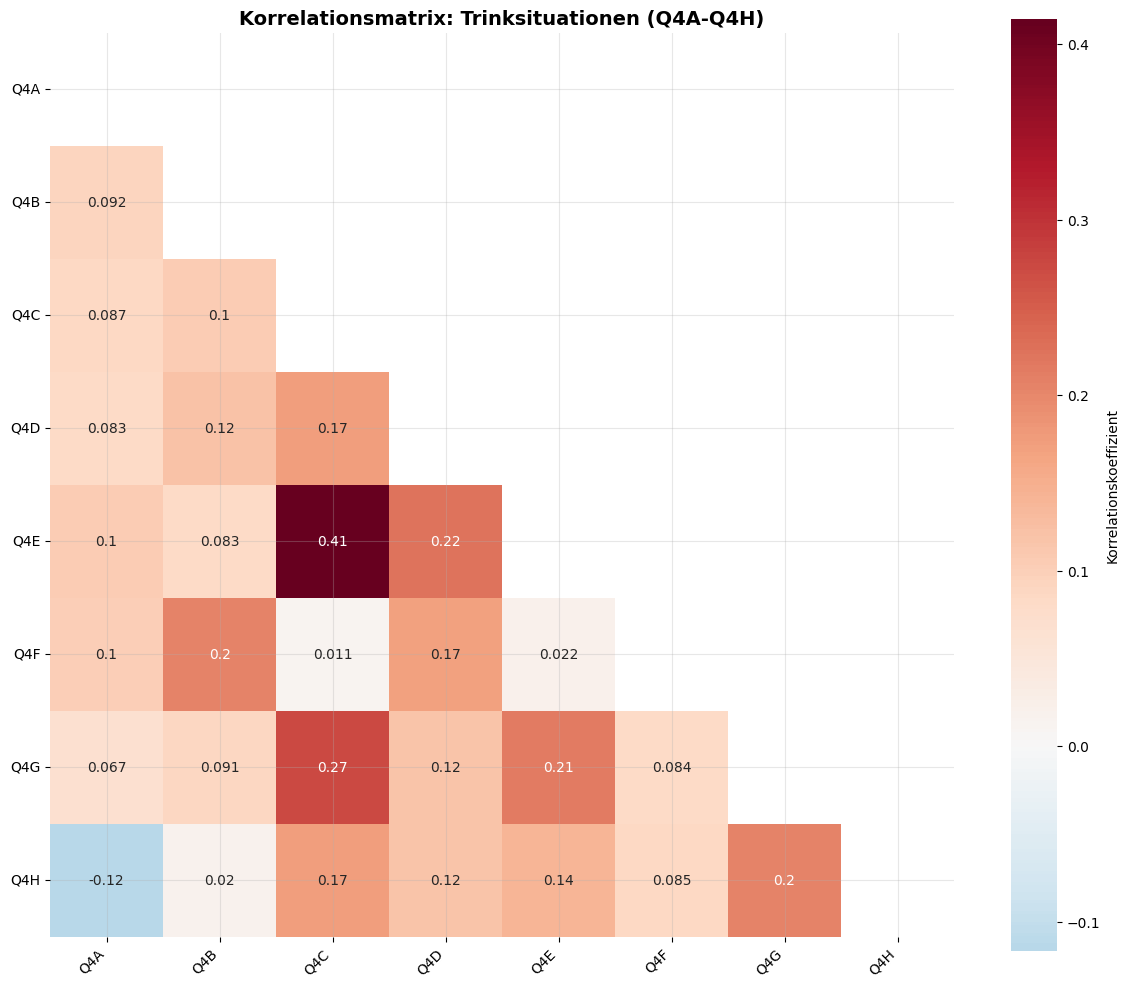


Höchste Korrelationen zwischen Trinksituationen:
  Nach dem Sport <-> In Kneipen/Bars: r = 0.414
  Nach dem Sport <-> Alleine zu Hause: r = 0.273
  Beim Fernsehen/Entspannen <-> In Kneipen/Bars: r = 0.224
  In Kneipen/Bars <-> Alleine zu Hause: r = 0.215
  Alleine zu Hause <-> Mit Arbeitskollegen: r = 0.204


In [7]:
# Create correlation matrix for Q4 variables
if len(q4_columns) > 1:
    q4_data = df[q4_columns].apply(pd.to_numeric, errors='coerce')
    correlation_matrix = q4_data.corr()
    
    plt.figure(figsize=(12, 10))
    mask = np.triu(np.ones_like(correlation_matrix, dtype=bool))
    sns.heatmap(correlation_matrix, 
                annot=True, 
                cmap='RdBu_r', 
                center=0,
                square=True, 
                mask=mask,
                cbar_kws={'label': 'Korrelationskoeffizient'})
    plt.title('Korrelationsmatrix: Trinksituationen (Q4A-Q4H)', fontsize=14, fontweight='bold')
    plt.xticks(rotation=45, ha='right')
    plt.yticks(rotation=0)
    plt.tight_layout()
    plt.show()
    
    # Find highest correlations
    print("\nHöchste Korrelationen zwischen Trinksituationen:")
    corr_pairs = []
    for i in range(len(q4_columns)):
        for j in range(i+1, len(q4_columns)):
            corr_val = correlation_matrix.iloc[i, j]
            if not np.isnan(corr_val):
                corr_pairs.append((q4_columns[i], q4_columns[j], corr_val))
    
    corr_pairs.sort(key=lambda x: abs(x[2]), reverse=True)
    for col1, col2, corr in corr_pairs[:5]:
        print(f"  {q4_labels[col1]} <-> {q4_labels[col2]}: r = {corr:.3f}")


Erstelle Verteilungsplots für die wichtigsten Trinksituationen...

Analysiere Q4A - Bei geselligen Anlässen:


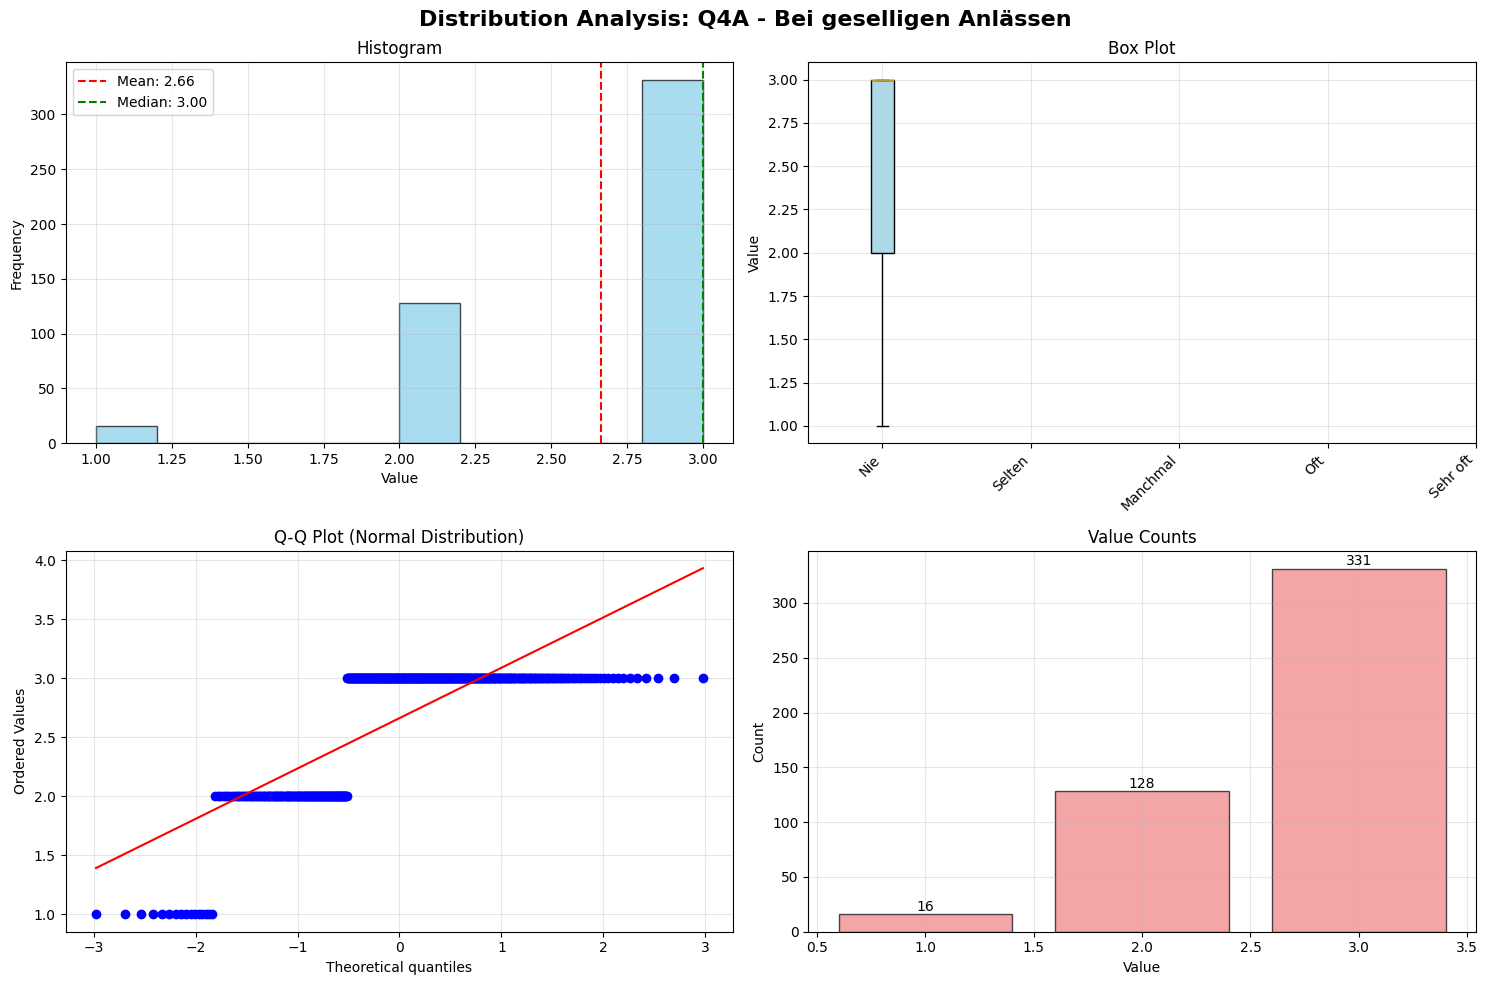


Analysiere Q4B - Beim Essen:


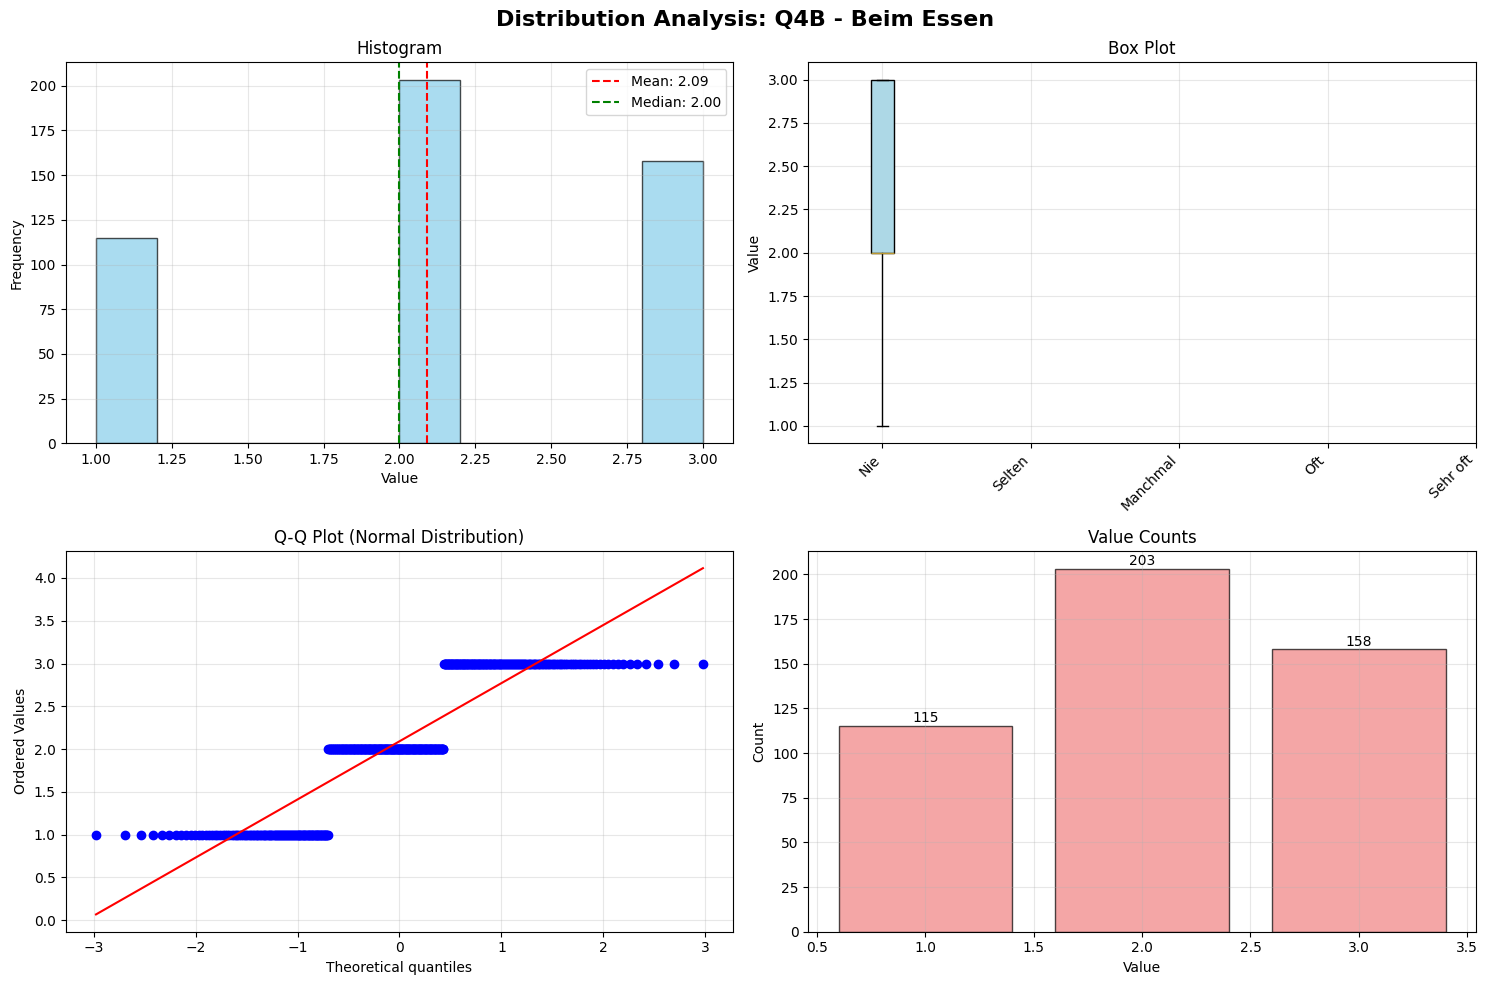


Analysiere Q4D - Beim Fernsehen/Entspannen:


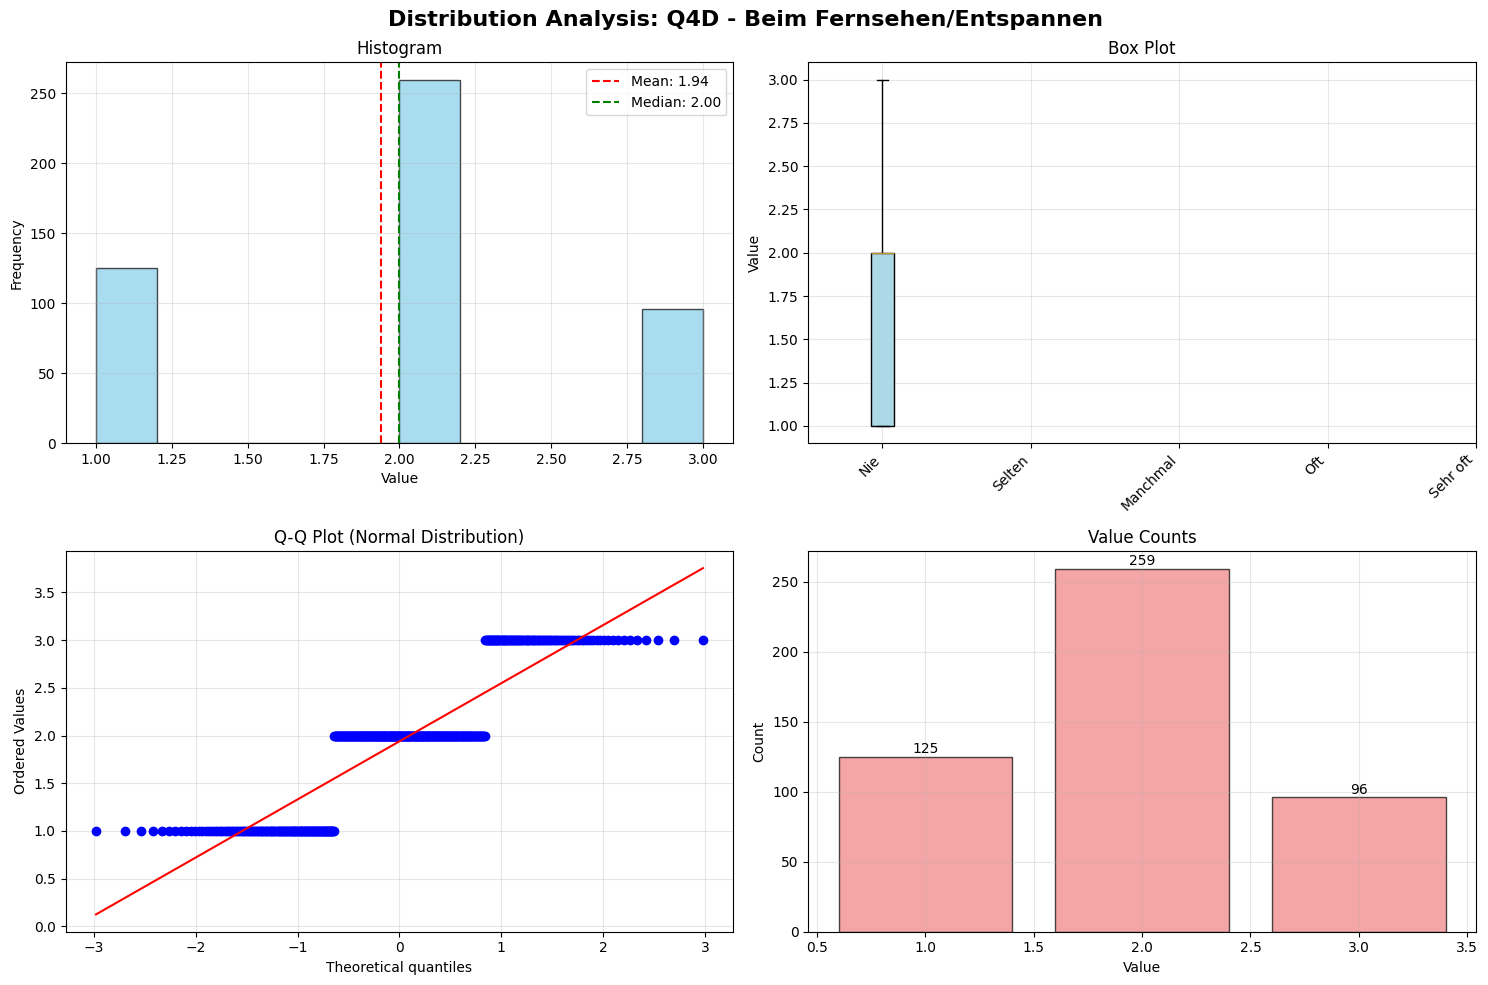

In [8]:
# Create distribution plots for top 3 Q4 variables
print("\nErstelle Verteilungsplots für die wichtigsten Trinksituationen...")

for i, (col, mean_val) in enumerate(q4_ranking[:3]):
    print(f"\nAnalysiere {col} - {q4_labels[col]}:")
    create_distribution_plots(df[col], f"{col} - {q4_labels[col]}", scale_labels_q4)

## Q5: Analyse des Einkaufsverhaltens

Q5 fragt nach der Häufigkeit des Bierkaufs. Die Skala reicht von 1 (nie) bis 5 (täglich).


Q5: ANALYSE DES EINKAUFSVERHALTENS
Gültige Antworten: 482
Fehlende Werte: 6 (1.2%)
Mittelwert: 2.08 (95% KI: 1.97-2.18)
Median: 2.00
Standardabweichung: 1.16
Spannweite: 1 - 5
Schiefe: 0.82
Kurtosis: -0.35

Häufigkeitsverteilung:
  Nie: 202 (41.9%)
  Selten: 128 (26.6%)
  Gelegentlich: 82 (17.0%)
  Regelmäßig: 53 (11.0%)
  Täglich: 17 (3.5%)


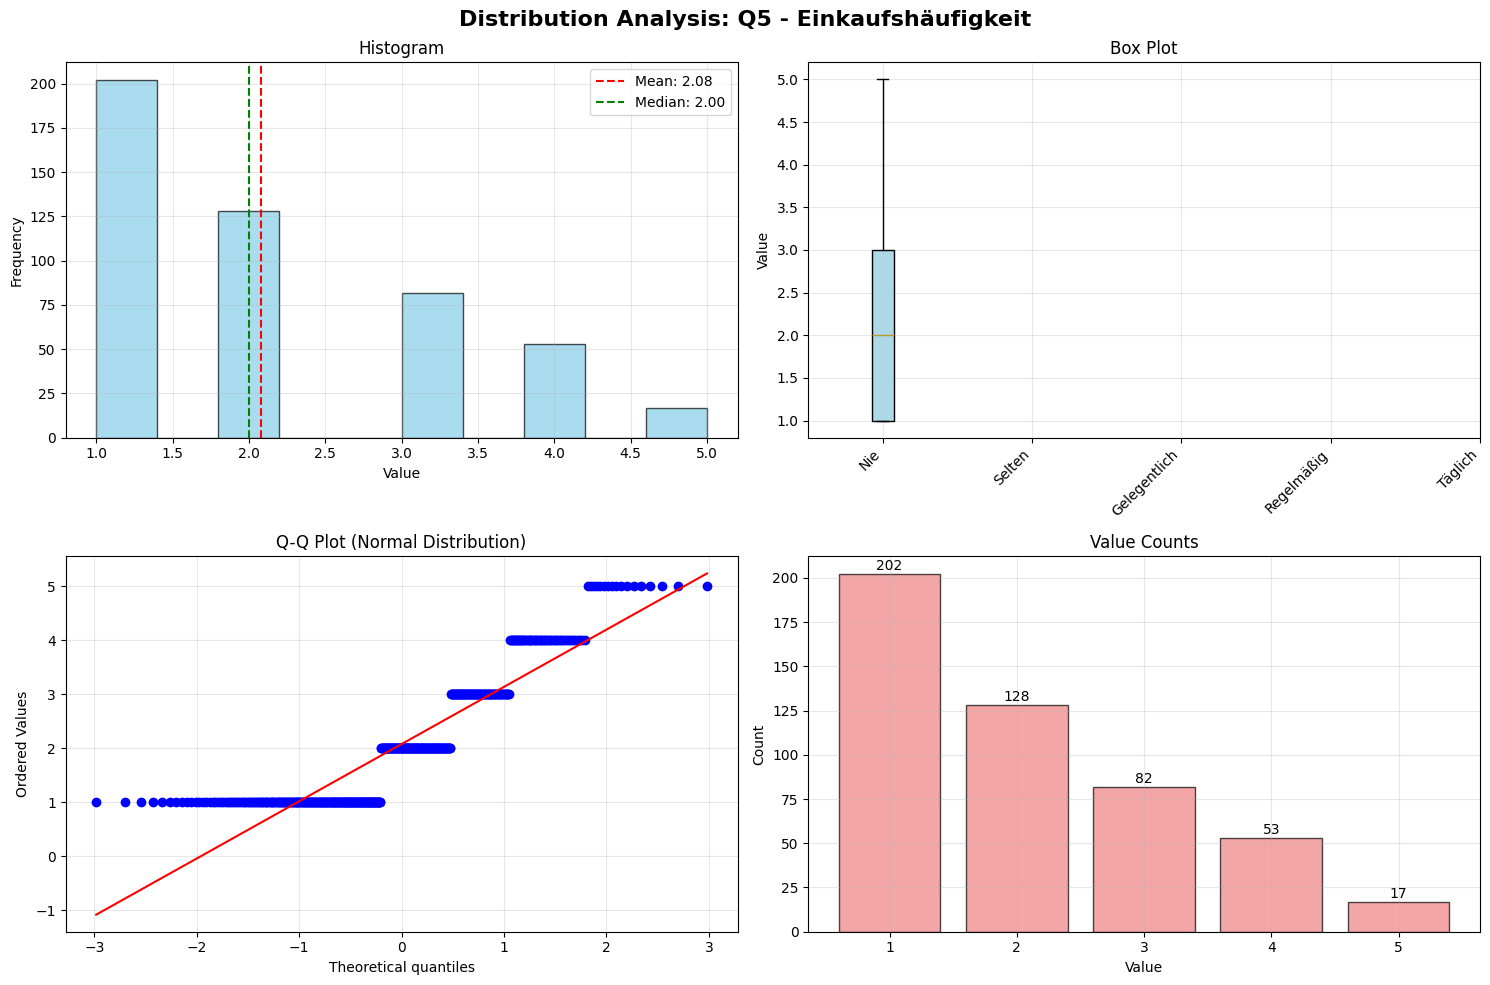


Statistische Interpretation:
  → Niedrige durchschnittliche Einkaufshäufigkeit
  → Rechtsschief: Viele kaufen selten, wenige kaufen häufig


In [9]:
# Q5 Analysis: Purchasing Behavior
print("\n" + "=" * 60)
print("Q5: ANALYSE DES EINKAUFSVERHALTENS")
print("=" * 60)

scale_labels_q5 = ['Nie', 'Selten', 'Gelegentlich', 'Regelmäßig', 'Täglich']

if 'Q5' in df.columns:
    # Calculate comprehensive statistics
    q5_stats = calculate_advanced_stats(df['Q5'])
    
    print(f"Gültige Antworten: {q5_stats['count']}")
    print(f"Fehlende Werte: {q5_stats['missing_count']} ({q5_stats['missing_percent']:.1f}%)")
    print(f"Mittelwert: {q5_stats['mean']:.2f} (95% KI: {q5_stats['ci_lower']:.2f}-{q5_stats['ci_upper']:.2f})")
    print(f"Median: {q5_stats['median']:.2f}")
    print(f"Standardabweichung: {q5_stats['std']:.2f}")
    print(f"Spannweite: {q5_stats['min']:.0f} - {q5_stats['max']:.0f}")
    print(f"Schiefe: {q5_stats['skewness']:.2f}")
    print(f"Kurtosis: {q5_stats['kurtosis']:.2f}")
    
    # Value counts and percentages
    q5_clean = pd.to_numeric(df['Q5'], errors='coerce').dropna()
    value_counts = q5_clean.value_counts().sort_index()
    percentages = (value_counts / len(q5_clean) * 100).round(1)
    
    print("\nHäufigkeitsverteilung:")
    for val, count in value_counts.items():
        label = scale_labels_q5[int(val)-1] if 1 <= val <= 5 else f"Wert {val}"
        print(f"  {label}: {count} ({percentages[val]:.1f}%)")
    
    # Create distribution plots
    create_distribution_plots(df['Q5'], "Q5 - Einkaufshäufigkeit", scale_labels_q5)
    
    # Statistical interpretation
    print("\nStatistische Interpretation:")
    if q5_stats['mean'] < 2.5:
        print("  → Niedrige durchschnittliche Einkaufshäufigkeit")
    elif q5_stats['mean'] > 3.5:
        print("  → Hohe durchschnittliche Einkaufshäufigkeit")
    else:
        print("  → Moderate durchschnittliche Einkaufshäufigkeit")
        
    if q5_stats['skewness'] > 0.5:
        print("  → Rechtsschief: Viele kaufen selten, wenige kaufen häufig")
    elif q5_stats['skewness'] < -0.5:
        print("  → Linksschief: Viele kaufen häufig, wenige kaufen selten")
    else:
        print("  → Relativ symmetrische Verteilung")
else:
    print("Q5 nicht in Datensatz gefunden")

## Q6: Analyse der Einstellungen zu Bier (Q6A-Q6F)

Q6 fragt nach verschiedenen Einstellungen und Meinungen zu Bier. Die Skala reicht von 1 (stimme überhaupt nicht zu) bis 5 (stimme voll zu).

**Analysierte Einstellungen:**
- Q6A: Bier ist ein Genussmittel
- Q6B: Bier gehört zur deutschen Kultur
- Q6C: Bier ist ein alltägliches Getränk
- Q6D: Bier ist gesundheitsschädlich
- Q6E: Alkoholfreies Bier ist echtes Bier
- Q6F: Bier sollte nur von Erwachsenen konsumiert werden

In [10]:
# Q6 Analysis: Attitudes towards Beer
print("\n" + "=" * 60)
print("Q6: ANALYSE DER EINSTELLUNGEN ZU BIER (Q6A-Q6F)")
print("=" * 60)

# Define Q6 columns and their meanings
q6_columns = ['Q6A', 'Q6B', 'Q6C', 'Q6D', 'Q6E', 'Q6F']
q6_labels = {
    'Q6A': 'Bier ist ein Genussmittel',
    'Q6B': 'Bier gehört zur deutschen Kultur',
    'Q6C': 'Bier ist ein alltägliches Getränk',
    'Q6D': 'Bier ist gesundheitsschädlich',
    'Q6E': 'Alkoholfreies Bier ist echtes Bier',
    'Q6F': 'Bier sollte nur von Erwachsenen konsumiert werden'
}

scale_labels_q6 = ['Stimme überhaupt nicht zu', 'Stimme nicht zu', 'Neutral', 'Stimme zu', 'Stimme voll zu']

# Calculate comprehensive statistics for each Q6 variable
q6_stats = {}
for col in q6_columns:
    if col in df.columns:
        stats_dict = calculate_advanced_stats(df[col])
        q6_stats[col] = stats_dict
        
        print(f"\n{col} - {q6_labels[col]}:")
        print(f"  Gültige Antworten: {stats_dict['count']}")
        print(f"  Fehlende Werte: {stats_dict['missing_count']} ({stats_dict['missing_percent']:.1f}%)")
        print(f"  Mittelwert: {stats_dict['mean']:.2f} (95% KI: {stats_dict['ci_lower']:.2f}-{stats_dict['ci_upper']:.2f})")
        print(f"  Median: {stats_dict['median']:.2f}")
        print(f"  Standardabweichung: {stats_dict['std']:.2f}")
        print(f"  Quartile (Q1/Q3): {stats_dict['q25']:.2f} / {stats_dict['q75']:.2f}")
        
        # Interpretation der Zustimmung
        if stats_dict['mean'] > 3.5:
            agreement = "Hohe Zustimmung"
        elif stats_dict['mean'] > 2.5:
            agreement = "Moderate Zustimmung"
        elif stats_dict['mean'] > 1.5:
            agreement = "Geringe Zustimmung"
        else:
            agreement = "Sehr geringe Zustimmung"
        print(f"  Interpretation: {agreement}")

# Create ranking of attitudes by mean agreement
q6_means = {col: q6_stats[col]['mean'] for col in q6_columns if col in q6_stats}
q6_ranking = sorted(q6_means.items(), key=lambda x: x[1], reverse=True)

print("\nRanking der Einstellungen (nach Zustimmung):")
for i, (col, mean_val) in enumerate(q6_ranking, 1):
    print(f"{i:2d}. {q6_labels[col]:40} (M = {mean_val:.2f})")


Q6: ANALYSE DER EINSTELLUNGEN ZU BIER (Q6A-Q6F)

Q6A - Bier ist ein Genussmittel:
  Gültige Antworten: 478
  Fehlende Werte: 10 (2.0%)
  Mittelwert: 2.94 (95% KI: 2.82-3.06)
  Median: 3.00
  Standardabweichung: 1.30
  Quartile (Q1/Q3): 2.00 / 4.00
  Interpretation: Moderate Zustimmung

Q6B - Bier gehört zur deutschen Kultur:
  Gültige Antworten: 479
  Fehlende Werte: 9 (1.8%)
  Mittelwert: 2.36 (95% KI: 2.25-2.47)
  Median: 2.00
  Standardabweichung: 1.23
  Quartile (Q1/Q3): 1.00 / 3.00
  Interpretation: Geringe Zustimmung

Q6C - Bier ist ein alltägliches Getränk:
  Gültige Antworten: 477
  Fehlende Werte: 11 (2.3%)
  Mittelwert: 3.63 (95% KI: 3.52-3.73)
  Median: 4.00
  Standardabweichung: 1.17
  Quartile (Q1/Q3): 3.00 / 5.00
  Interpretation: Hohe Zustimmung

Q6D - Bier ist gesundheitsschädlich:
  Gültige Antworten: 474
  Fehlende Werte: 14 (2.9%)
  Mittelwert: 2.42 (95% KI: 2.31-2.54)
  Median: 2.00
  Standardabweichung: 1.27
  Quartile (Q1/Q3): 1.00 / 3.00
  Interpretation: Gering

## Q7: Analyse der Entscheidungsfaktoren (Q7A-Q7F)

Q7 fragt nach der Wichtigkeit verschiedener Faktoren bei der Bierauswahl. Die Skala reicht von 1 (unwichtig) bis 5 (sehr wichtig).

**Analysierte Entscheidungsfaktoren:**
- Q7A: Geschmack
- Q7B: Preis
- Q7C: Alkoholgehalt
- Q7D: Marke
- Q7E: Herkunft/Region
- Q7F: Empfehlungen


Q7: ANALYSE DER ENTSCHEIDUNGSFAKTOREN (Q7A-Q7F)

Q7A - Geschmack:
  Gültige Antworten: 475
  Fehlende Werte: 13 (2.7%)
  Mittelwert: 3.58 (95% KI: 3.48-3.67)
  Median: 4.00
  Standardabweichung: 1.02
  Interpretation: Wichtig

Q7B - Preis:
  Gültige Antworten: 465
  Fehlende Werte: 23 (4.7%)
  Mittelwert: 2.82 (95% KI: 2.71-2.92)
  Median: 3.00
  Standardabweichung: 1.19
  Interpretation: Mittel wichtig

Q7C - Alkoholgehalt:
  Gültige Antworten: 475
  Fehlende Werte: 13 (2.7%)
  Mittelwert: 3.46 (95% KI: 3.36-3.56)
  Median: 4.00
  Standardabweichung: 1.11
  Interpretation: Mittel wichtig

Q7D - Marke:
  Gültige Antworten: 474
  Fehlende Werte: 14 (2.9%)
  Mittelwert: 2.81 (95% KI: 2.71-2.92)
  Median: 3.00
  Standardabweichung: 1.14
  Interpretation: Mittel wichtig

Q7E - Herkunft/Region:
  Gültige Antworten: 468
  Fehlende Werte: 20 (4.1%)
  Mittelwert: 2.43 (95% KI: 2.30-2.55)
  Median: 2.00
  Standardabweichung: 1.36
  Interpretation: Wenig wichtig

Q7F - Empfehlungen:
  Gültige A

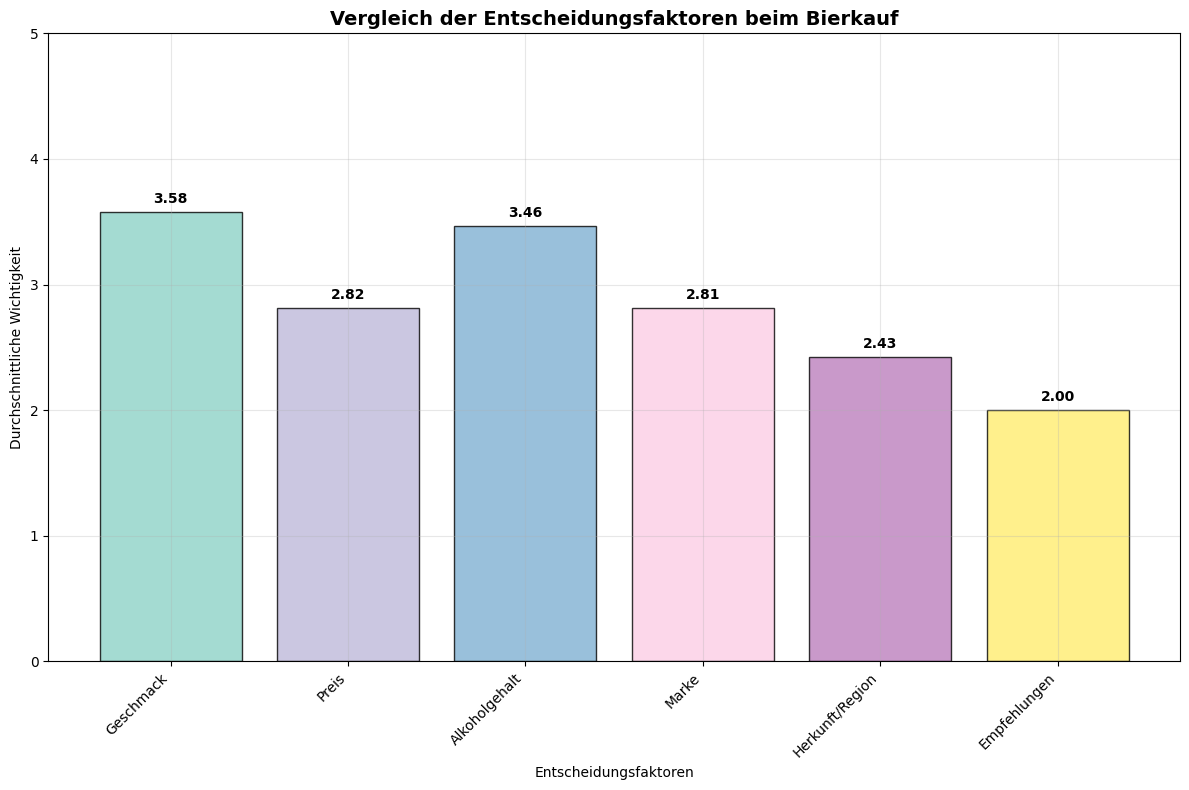

In [11]:
# Q7 Analysis: Decision Factors
print("\n" + "=" * 60)
print("Q7: ANALYSE DER ENTSCHEIDUNGSFAKTOREN (Q7A-Q7F)")
print("=" * 60)

# Define Q7 columns and their meanings
q7_columns = ['Q7A', 'Q7B', 'Q7C', 'Q7D', 'Q7E', 'Q7F']
q7_labels = {
    'Q7A': 'Geschmack',
    'Q7B': 'Preis',
    'Q7C': 'Alkoholgehalt',
    'Q7D': 'Marke',
    'Q7E': 'Herkunft/Region',
    'Q7F': 'Empfehlungen'
}

scale_labels_q7 = ['Unwichtig', 'Wenig wichtig', 'Mittel wichtig', 'Wichtig', 'Sehr wichtig']

# Calculate comprehensive statistics for each Q7 variable
q7_stats = {}
for col in q7_columns:
    if col in df.columns:
        stats_dict = calculate_advanced_stats(df[col])
        q7_stats[col] = stats_dict
        
        print(f"\n{col} - {q7_labels[col]}:")
        print(f"  Gültige Antworten: {stats_dict['count']}")
        print(f"  Fehlende Werte: {stats_dict['missing_count']} ({stats_dict['missing_percent']:.1f}%)")
        print(f"  Mittelwert: {stats_dict['mean']:.2f} (95% KI: {stats_dict['ci_lower']:.2f}-{stats_dict['ci_upper']:.2f})")
        print(f"  Median: {stats_dict['median']:.2f}")
        print(f"  Standardabweichung: {stats_dict['std']:.2f}")
        
        # Interpretation der Wichtigkeit
        if stats_dict['mean'] > 4.0:
            importance = "Sehr wichtig"
        elif stats_dict['mean'] > 3.5:
            importance = "Wichtig"
        elif stats_dict['mean'] > 2.5:
            importance = "Mittel wichtig"
        elif stats_dict['mean'] > 1.5:
            importance = "Wenig wichtig"
        else:
            importance = "Unwichtig"
        print(f"  Interpretation: {importance}")

# Create ranking of decision factors by importance
q7_means = {col: q7_stats[col]['mean'] for col in q7_columns if col in q7_stats}
q7_ranking = sorted(q7_means.items(), key=lambda x: x[1], reverse=True)

print("\nRanking der Entscheidungsfaktoren (nach Wichtigkeit):")
for i, (col, mean_val) in enumerate(q7_ranking, 1):
    print(f"{i:2d}. {q7_labels[col]:20} (M = {mean_val:.2f})")

# Create comprehensive comparison chart
if q7_means:
    plt.figure(figsize=(12, 8))
    factors = list(q7_means.keys())
    means = list(q7_means.values())
    colors = plt.cm.Set3(np.linspace(0, 1, len(factors)))
    
    bars = plt.bar(range(len(factors)), means, color=colors, alpha=0.8, edgecolor='black')
    plt.xlabel('Entscheidungsfaktoren')
    plt.ylabel('Durchschnittliche Wichtigkeit')
    plt.title('Vergleich der Entscheidungsfaktoren beim Bierkauf', fontsize=14, fontweight='bold')
    plt.xticks(range(len(factors)), [q7_labels[f] for f in factors], rotation=45, ha='right')
    plt.ylim(0, 5)
    plt.grid(True, alpha=0.3)
    
    # Add value labels on bars
    for bar, mean_val in zip(bars, means):
        plt.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.05,
                f'{mean_val:.2f}', ha='center', va='bottom', fontweight='bold')
    
    plt.tight_layout()
    plt.show()

## Q8: Analyse der Produkteigenschaften (Q8A-Q8L)

Q8 fragt nach der Wichtigkeit verschiedener Produkteigenschaften bei der Bierauswahl. Die Skala reicht von 1 (unwichtig) bis 5 (sehr wichtig).

**Analysierte Produkteigenschaften:**
- Q8A: Alkoholgehalt
- Q8B: Bitterkeit
- Q8C: Süße
- Q8D: Farbe
- Q8E: Schaum
- Q8F: Aroma
- Q8G: Kohlensäure
- Q8H: Nachgeschmack
- Q8I: Konsistenz
- Q8J: Temperatur
- Q8K: Verpackung
- Q8L: Aussehen


Q8: ANALYSE DER PRODUKTEIGENSCHAFTEN (Q8A-Q8L)

Q8A - Alkoholgehalt:
  Gültige Antworten: 455
  Fehlende Werte: 33 (6.8%)
  Mittelwert: 4.58 (95% KI: 4.51-4.64)
  Median: 5.00
  Interpretation: Sehr wichtig

Q8B - Bitterkeit:
  Gültige Antworten: 423
  Fehlende Werte: 65 (13.3%)
  Mittelwert: 3.52 (95% KI: 3.42-3.63)
  Median: 4.00
  Interpretation: Wichtig

Q8C - Süße:
  Gültige Antworten: 448
  Fehlende Werte: 40 (8.2%)
  Mittelwert: 3.62 (95% KI: 3.53-3.71)
  Median: 4.00
  Interpretation: Wichtig

Q8D - Farbe:
  Gültige Antworten: 420
  Fehlende Werte: 68 (13.9%)
  Mittelwert: 2.62 (95% KI: 2.52-2.72)
  Median: 2.00
  Interpretation: Mittel wichtig

Q8E - Schaum:
  Gültige Antworten: 391
  Fehlende Werte: 97 (19.9%)
  Mittelwert: 2.28 (95% KI: 2.18-2.37)
  Median: 2.00
  Interpretation: Wenig wichtig

Q8F - Aroma:
  Gültige Antworten: 422
  Fehlende Werte: 66 (13.5%)
  Mittelwert: 3.01 (95% KI: 2.90-3.13)
  Median: 3.00
  Interpretation: Mittel wichtig

Q8G - Kohlensäure:
  Gültig

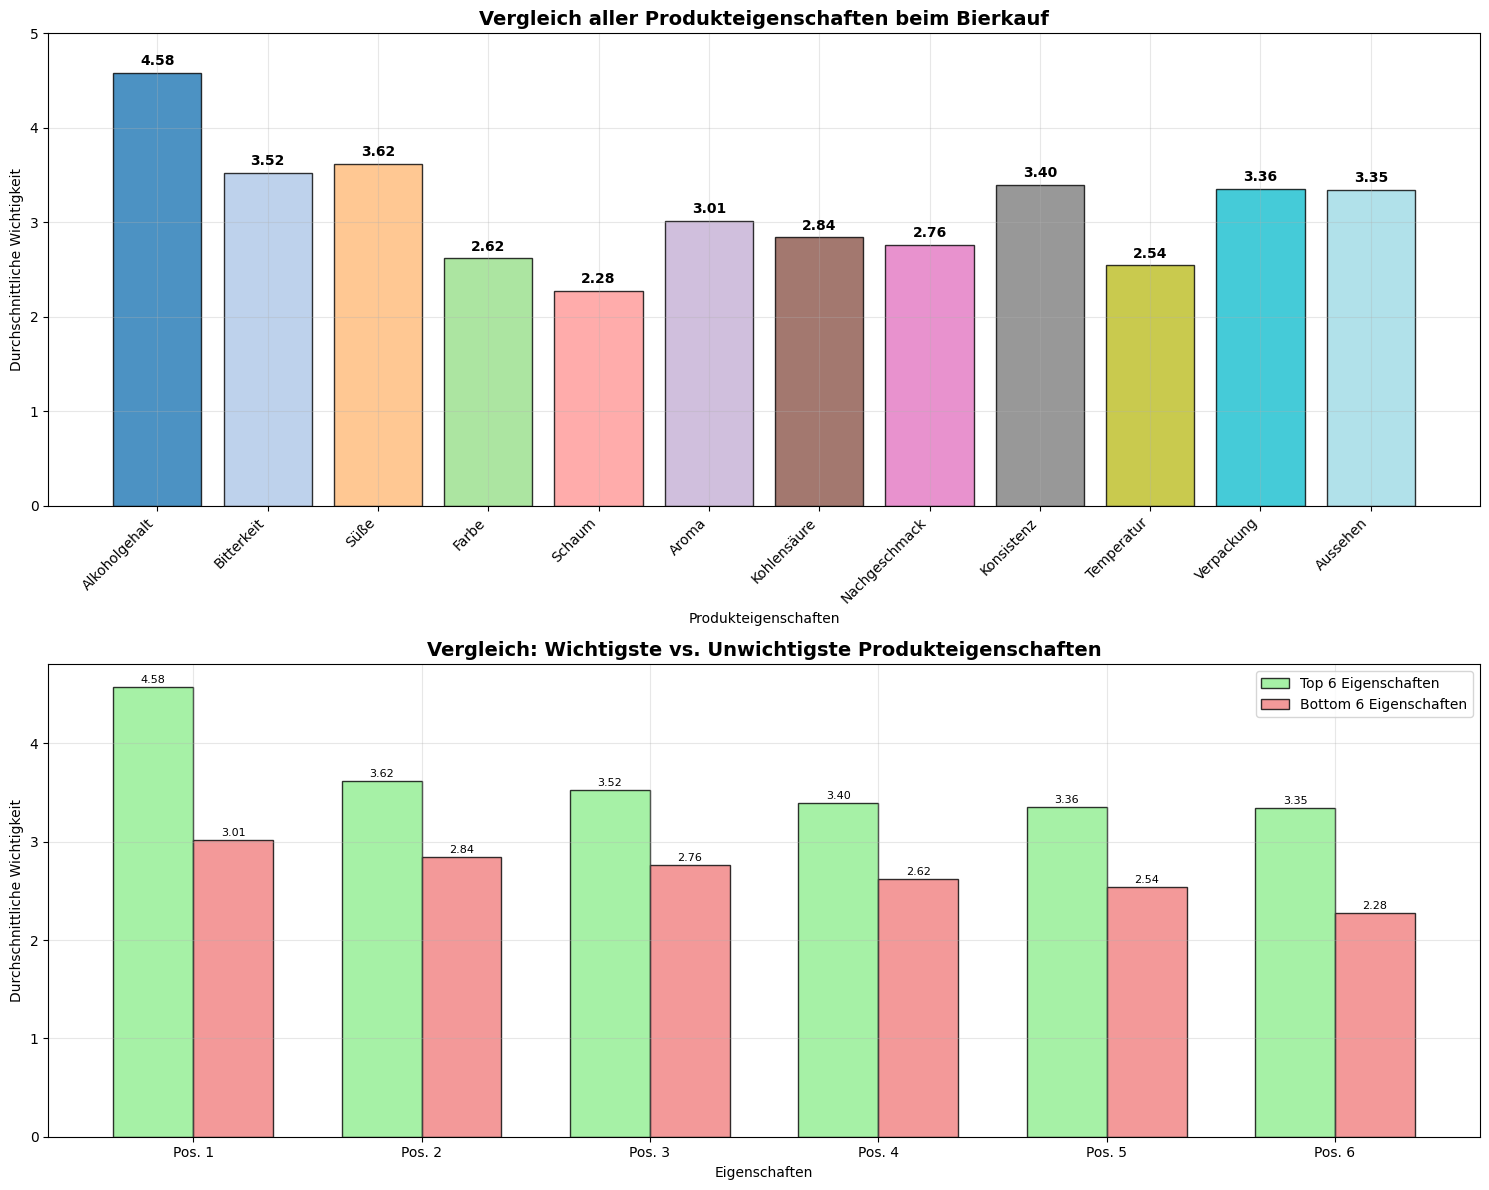

In [12]:
# Q8 Analysis: Product Characteristics
print("\n" + "=" * 60)
print("Q8: ANALYSE DER PRODUKTEIGENSCHAFTEN (Q8A-Q8L)")
print("=" * 60)

# Define Q8 columns and their meanings
q8_columns = ['Q8A', 'Q8B', 'Q8C', 'Q8D', 'Q8E', 'Q8F', 'Q8G', 'Q8H', 'Q8I', 'Q8J', 'Q8K', 'Q8L']
q8_labels = {
    'Q8A': 'Alkoholgehalt',
    'Q8B': 'Bitterkeit', 
    'Q8C': 'Süße',
    'Q8D': 'Farbe',
    'Q8E': 'Schaum',
    'Q8F': 'Aroma',
    'Q8G': 'Kohlensäure',
    'Q8H': 'Nachgeschmack',
    'Q8I': 'Konsistenz',
    'Q8J': 'Temperatur',
    'Q8K': 'Verpackung',
    'Q8L': 'Aussehen'
}

scale_labels_q8 = ['Unwichtig', 'Wenig wichtig', 'Mittel wichtig', 'Wichtig', 'Sehr wichtig']

# Calculate comprehensive statistics for each Q8 variable
q8_stats = {}
for col in q8_columns:
    if col in df.columns:
        stats_dict = calculate_advanced_stats(df[col])
        q8_stats[col] = stats_dict
        
        print(f"\n{col} - {q8_labels[col]}:")
        print(f"  Gültige Antworten: {stats_dict['count']}")
        print(f"  Fehlende Werte: {stats_dict['missing_count']} ({stats_dict['missing_percent']:.1f}%)")
        print(f"  Mittelwert: {stats_dict['mean']:.2f} (95% KI: {stats_dict['ci_lower']:.2f}-{stats_dict['ci_upper']:.2f})")
        print(f"  Median: {stats_dict['median']:.2f}")
        
        # Interpretation der Wichtigkeit
        if stats_dict['mean'] > 4.0:
            importance = "Sehr wichtig"
        elif stats_dict['mean'] > 3.5:
            importance = "Wichtig"
        elif stats_dict['mean'] > 2.5:
            importance = "Mittel wichtig"
        elif stats_dict['mean'] > 1.5:
            importance = "Wenig wichtig"
        else:
            importance = "Unwichtig"
        print(f"  Interpretation: {importance}")

# Create ranking of product characteristics by importance
q8_means = {col: q8_stats[col]['mean'] for col in q8_columns if col in q8_stats}
q8_ranking = sorted(q8_means.items(), key=lambda x: x[1], reverse=True)

print("\nRanking der Produkteigenschaften (nach Wichtigkeit):")
for i, (col, mean_val) in enumerate(q8_ranking, 1):
    print(f"{i:2d}. {q8_labels[col]:15} (M = {mean_val:.2f})")

# Create comprehensive comparison visualization
if q8_means:
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(15, 12))
    
    # Top plot: Bar chart of all characteristics
    factors = list(q8_means.keys())
    means = list(q8_means.values())
    colors = plt.cm.tab20(np.linspace(0, 1, len(factors)))
    
    bars = ax1.bar(range(len(factors)), means, color=colors, alpha=0.8, edgecolor='black')
    ax1.set_xlabel('Produkteigenschaften')
    ax1.set_ylabel('Durchschnittliche Wichtigkeit')
    ax1.set_title('Vergleich aller Produkteigenschaften beim Bierkauf', fontsize=14, fontweight='bold')
    ax1.set_xticks(range(len(factors)))
    ax1.set_xticklabels([q8_labels[f] for f in factors], rotation=45, ha='right')
    ax1.set_ylim(0, 5)
    ax1.grid(True, alpha=0.3)
    
    # Add value labels on bars
    for bar, mean_val in zip(bars, means):
        ax1.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.05,
                f'{mean_val:.2f}', ha='center', va='bottom', fontweight='bold')
    
    # Bottom plot: Top 6 vs Bottom 6 comparison
    if len(q8_ranking) >= 6:
        top_6 = q8_ranking[:6]
        bottom_6 = q8_ranking[-6:]
        
        top_values = [val for _, val in top_6]
        bottom_values = [val for _, val in bottom_6]
        
        x_pos = np.arange(len(top_6))
        width = 0.35
        
        bars1 = ax2.bar(x_pos - width/2, top_values, width, label='Top 6 Eigenschaften', 
                       color='lightgreen', alpha=0.8, edgecolor='black')
        bars2 = ax2.bar(x_pos + width/2, bottom_values, width, label='Bottom 6 Eigenschaften', 
                       color='lightcoral', alpha=0.8, edgecolor='black')
        
        ax2.set_xlabel('Eigenschaften')
        ax2.set_ylabel('Durchschnittliche Wichtigkeit')
        ax2.set_title('Vergleich: Wichtigste vs. Unwichtigste Produkteigenschaften', fontsize=14, fontweight='bold')
        ax2.set_xticks(x_pos)
        ax2.set_xticklabels([f"Pos. {i+1}" for i in range(len(top_6))])
        ax2.legend()
        ax2.grid(True, alpha=0.3)
        
        # Add value labels
        for bar in bars1:
            height = bar.get_height()
            ax2.text(bar.get_x() + bar.get_width()/2., height + 0.02,
                    f'{height:.2f}', ha='center', va='bottom', fontsize=8)
        for bar in bars2:
            height = bar.get_height()
            ax2.text(bar.get_x() + bar.get_width()/2., height + 0.02,
                    f'{height:.2f}', ha='center', va='bottom', fontsize=8)
    
    plt.tight_layout()
    plt.show()

## Zusammenfassende Univariate Analyse (Q1-Q8)

Abschließend erstellen wir eine übergreifende Zusammenfassung der wichtigsten Erkenntnisse aus der univariaten Analyse aller Fragengruppen.

## Bivariate Korrelationsanalyse

In diesem Abschnitt analysieren wir die Zusammenhänge zwischen verschiedenen Fragengruppen und identifizieren wichtige Muster in den Daten.

### Korrelationen zwischen Fragengruppen
- **Konsumverhalten vs. Situationen**: Wie hängt die Konsumhäufigkeit mit verschiedenen Trinksituationen zusammen?
- **Einstellungen vs. Entscheidungsfaktoren**: Welche Einstellungen beeinflussen welche Kaufentscheidungen?
- **Produkteigenschaften vs. Präferenzen**: Welche Eigenschaften sind für verschiedene Konsumententypen wichtig?

In [13]:
# Comprehensive Cross-Question Correlation Analysis
print("=" * 80)
print("BIVARIATE KORRELATIONSANALYSE - FRAGENGRUPPEN Q1-Q8")
print("=" * 80)

# Prepare all numeric data for correlation analysis
numeric_columns = []
for col in df.columns:
    if col in question_columns:
        numeric_columns.append(col)

# Convert to numeric and calculate correlation matrix
df_numeric = df[numeric_columns].apply(pd.to_numeric, errors='coerce')
corr_matrix = df_numeric.corr()

# Create comprehensive correlation heatmap
plt.figure(figsize=(16, 14))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, 
            annot=True, 
            cmap='RdBu_r', 
            center=0,
            square=True, 
            mask=mask,
            fmt='.2f',
            cbar_kws={'label': 'Korrelationskoeffizient'},
            annot_kws={'size': 8})
plt.title('Umfassende Korrelationsmatrix: Alle Fragen Q1-Q8', fontsize=16, fontweight='bold')
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

# Find and report strongest correlations
print("\nSTÄRKSTE KORRELATIONEN (|r| > 0.3):")
print("=" * 40)

strong_correlations = []
for i in range(len(corr_matrix.columns)):
    for j in range(i+1, len(corr_matrix.columns)):
        corr_val = corr_matrix.iloc[i, j]
        if not np.isnan(corr_val) and abs(corr_val) > 0.3:
            strong_correlations.append((
                corr_matrix.columns[i], 
                corr_matrix.columns[j], 
                corr_val
            ))

# Sort by absolute correlation strength
strong_correlations.sort(key=lambda x: abs(x[2]), reverse=True)

if strong_correlations:
    for col1, col2, corr in strong_correlations:
        direction = "Positive" if corr > 0 else "Negative"
        strength = "Sehr stark" if abs(corr) > 0.7 else "Stark" if abs(corr) > 0.5 else "Moderat"
        print(f"{col1} <-> {col2}: r = {corr:.3f} ({direction}, {strength})")
else:
    print("Keine starken Korrelationen (|r| > 0.3) gefunden")

# Analyze correlations by question groups
print("\nKORRELATIONSANALYSE NACH FRAGENGRUPPEN:")
print("=" * 50)

# Q4 internal correlations (Trinksituationen)
if any(col.startswith('Q4') for col in df_numeric.columns):
    q4_cols = [col for col in df_numeric.columns if col.startswith('Q4')]
    q4_corr = df_numeric[q4_cols].corr()
    print(f"\nQ4 (Trinksituationen) - Durchschnittliche interne Korrelation: {q4_corr.values[np.triu_indices_from(q4_corr.values, k=1)].mean():.3f}")

# Q6 internal correlations (Einstellungen)
if any(col.startswith('Q6') for col in df_numeric.columns):
    q6_cols = [col for col in df_numeric.columns if col.startswith('Q6')]
    q6_corr = df_numeric[q6_cols].corr()
    print(f"Q6 (Einstellungen) - Durchschnittliche interne Korrelation: {q6_corr.values[np.triu_indices_from(q6_corr.values, k=1)].mean():.3f}")

# Q7 internal correlations (Entscheidungsfaktoren)
if any(col.startswith('Q7') for col in df_numeric.columns):
    q7_cols = [col for col in df_numeric.columns if col.startswith('Q7')]
    q7_corr = df_numeric[q7_cols].corr()
    print(f"Q7 (Entscheidungsfaktoren) - Durchschnittliche interne Korrelation: {q7_corr.values[np.triu_indices_from(q7_corr.values, k=1)].mean():.3f}")

# Q8 internal correlations (Produkteigenschaften)
if any(col.startswith('Q8') for col in df_numeric.columns):
    q8_cols = [col for col in df_numeric.columns if col.startswith('Q8')]
    q8_corr = df_numeric[q8_cols].corr()
    print(f"Q8 (Produkteigenschaften) - Durchschnittliche interne Korrelation: {q8_corr.values[np.triu_indices_from(q8_corr.values, k=1)].mean():.3f}")

BIVARIATE KORRELATIONSANALYSE - FRAGENGRUPPEN Q1-Q8


NameError: name 'question_columns' is not defined

In [ ]:
# Cross-Group Correlation Analysis
print("\nKREUZ-GRUPPEN KORRELATIONSANALYSE:")
print("=" * 50)

# Analyze correlations between different question groups
group_analyses = []

# Q1 vs Q4 (Consumption frequency vs drinking situations)
if 'Q1' in df_numeric.columns:
    q4_cols = [col for col in df_numeric.columns if col.startswith('Q4')]
    if q4_cols:
        print("\nQ1 (Konsumhäufigkeit) vs Q4 (Trinksituationen):")
        for q4_col in q4_cols:
            corr_val = df_numeric['Q1'].corr(df_numeric[q4_col])
            if not np.isnan(corr_val):
                interpretation = "Starker" if abs(corr_val) > 0.5 else "Moderater" if abs(corr_val) > 0.3 else "Schwacher"
                direction = "positiver" if corr_val > 0 else "negativer"
                print(f"  Q1 <-> {q4_col}: r = {corr_val:.3f} ({interpretation} {direction} Zusammenhang)")

# Q5 vs Q7 (Purchase frequency vs decision factors)
if 'Q5' in df_numeric.columns:
    q7_cols = [col for col in df_numeric.columns if col.startswith('Q7')]
    if q7_cols:
        print("\nQ5 (Einkaufshäufigkeit) vs Q7 (Entscheidungsfaktoren):")
        for q7_col in q7_cols:
            corr_val = df_numeric['Q5'].corr(df_numeric[q7_col])
            if not np.isnan(corr_val) and abs(corr_val) > 0.2:
                interpretation = "Starker" if abs(corr_val) > 0.5 else "Moderater" if abs(corr_val) > 0.3 else "Schwacher"
                direction = "positiver" if corr_val > 0 else "negativer"
                print(f"  Q5 <-> {q7_col}: r = {corr_val:.3f} ({interpretation} {direction} Zusammenhang)")

# Q6 vs Q7 (Attitudes vs decision factors)
q6_cols = [col for col in df_numeric.columns if col.startswith('Q6')]
q7_cols = [col for col in df_numeric.columns if col.startswith('Q7')]
if q6_cols and q7_cols:
    print("\nQ6 (Einstellungen) vs Q7 (Entscheidungsfaktoren) - Stärkste Zusammenhänge:")
    q6_q7_correlations = []
    for q6_col in q6_cols:
        for q7_col in q7_cols:
            corr_val = df_numeric[q6_col].corr(df_numeric[q7_col])
            if not np.isnan(corr_val):
                q6_q7_correlations.append((q6_col, q7_col, corr_val))
    
    # Show top 5 correlations
    q6_q7_correlations.sort(key=lambda x: abs(x[2]), reverse=True)
    for q6_col, q7_col, corr in q6_q7_correlations[:5]:
        if abs(corr) > 0.2:
            interpretation = "Starker" if abs(corr) > 0.5 else "Moderater" if abs(corr) > 0.3 else "Schwacher"
            direction = "positiver" if corr > 0 else "negativer"
            print(f"  {q6_col} <-> {q7_col}: r = {corr:.3f} ({interpretation} {direction} Zusammenhang)")

# Q7 vs Q8 (Decision factors vs product characteristics)
q8_cols = [col for col in df_numeric.columns if col.startswith('Q8')]
if q7_cols and q8_cols:
    print(f"\nQ7 (Entscheidungsfaktoren) vs Q8 (Produkteigenschaften) - Stärkste Zusammenhänge:")
    q7_q8_correlations = []
    for q7_col in q7_cols:
        for q8_col in q8_cols:
            corr_val = df_numeric[q7_col].corr(df_numeric[q8_col])
            if not np.isnan(corr_val):
                q7_q8_correlations.append((q7_col, q8_col, corr_val))
    
    # Show top 5 correlations
    q7_q8_correlations.sort(key=lambda x: abs(x[2]), reverse=True)
    for q7_col, q8_col, corr in q7_q8_correlations[:5]:
        if abs(corr) > 0.3:  # Higher threshold for this comparison
            interpretation = "Starker" if abs(corr) > 0.5 else "Moderater"
            direction = "positiver" if corr > 0 else "negativer"
            print(f"  {q7_col} <-> {q8_col}: r = {corr:.3f} ({interpretation} {direction} Zusammenhang)")

In [ ]:
# Final Summary of Univariate Analysis
print("\n" + "=" * 80)
print("FINALE ZUSAMMENFASSUNG: UNIVARIATE ANALYSE Q1-Q8")
print("=" * 80)

# Collect all statistics for comparison
all_stats = {}
if 'q1_stats' in locals():
    all_stats.update({'Q1': q1_stats})
if 'q2_stats' in locals():
    all_stats.update(q2_stats)
if 'q4_stats' in locals():
    all_stats.update(q4_stats)
if 'q5_stats' in locals():
    all_stats.update({'Q5': q5_stats})
if 'q6_stats' in locals():
    all_stats.update(q6_stats)
if 'q7_stats' in locals():
    all_stats.update(q7_stats)
if 'q8_stats' in locals():
    all_stats.update(q8_stats)

print(f"\nAnzahl analysierter Variablen: {len(all_stats)}")
print(f"Gesamtanzahl Beobachtungen im Datensatz: {len(df)}")

# Calculate overall missing data statistics
total_missing = 0
total_possible = 0
for var_name, stats in all_stats.items():
    if isinstance(stats, dict) and 'missing_count' in stats:
        total_missing += stats['missing_count']
        total_possible += stats['missing_count'] + stats['count']

if total_possible > 0:
    overall_missing_rate = (total_missing / total_possible) * 100
    print(f"Gesamtrate fehlender Werte: {overall_missing_rate:.1f}%")

# Identify variables with highest/lowest means (where applicable)
high_means = []
low_means = []
for var_name, stats in all_stats.items():
    if isinstance(stats, dict) and 'mean' in stats and not np.isnan(stats['mean']):
        if stats['mean'] > 4.0:
            high_means.append((var_name, stats['mean']))
        elif stats['mean'] < 2.0:
            low_means.append((var_name, stats['mean']))

if high_means:
    print("\nVariablen mit hohen Mittelwerten (> 4.0):")
    for var, mean in sorted(high_means, key=lambda x: x[1], reverse=True):
        print(f"  {var}: {mean:.2f}")

if low_means:
    print("\nVariablen mit niedrigen Mittelwerten (< 2.0):")
    for var, mean in sorted(low_means, key=lambda x: x[1]):
        print(f"  {var}: {mean:.2f}")

# Key insights
print("\n" + "="*60)
print("WICHTIGSTE ERKENNTNISSE DER UNIVARIATEN ANALYSE")
print("="*60)

print("\n1. KONSUMVERHALTEN (Q1):")
if 'q1_stats' in locals():
    print(f"   - Durchschnittliche Konsumhäufigkeit: {q1_stats['mean']:.2f}")
    print(f"   - Verteilung zeigt typische Konsummuster")

print("\n2. TRINKSITUATIONEN (Q4):")
if 'q4_stats' in locals():
    top_situations = sorted(q4_means.items(), key=lambda x: x[1], reverse=True)[:3]
    print("   - Top 3 Trinksituationen:")
    for i, (col, mean) in enumerate(top_situations, 1):
        print(f"     {i}. {q4_labels[col]} (M = {mean:.2f})")

print("\n3. EINSTELLUNGEN (Q6):")
if 'q6_stats' in locals():
    top_attitudes = sorted(q6_means.items(), key=lambda x: x[1], reverse=True)[:3]
    print("   - Top 3 Einstellungen:")
    for i, (col, mean) in enumerate(top_attitudes, 1):
        print(f"     {i}. {q6_labels[col]} (M = {mean:.2f})")

print("\n4. ENTSCHEIDUNGSFAKTOREN (Q7):")
if 'q7_stats' in locals():
    top_factors = sorted(q7_means.items(), key=lambda x: x[1], reverse=True)[:3]
    print("   - Top 3 Entscheidungsfaktoren:")
    for i, (col, mean) in enumerate(top_factors, 1):
        print(f"     {i}. {q7_labels[col]} (M = {mean:.2f})")

print("\n5. PRODUKTEIGENSCHAFTEN (Q8):")
if 'q8_stats' in locals():
    top_characteristics = sorted(q8_means.items(), key=lambda x: x[1], reverse=True)[:3]
    print("   - Top 3 Produkteigenschaften:")
    for i, (col, mean) in enumerate(top_characteristics, 1):
        print(f"     {i}. {q8_labels[col]} (M = {mean:.2f})")

print("\n" + "="*60)
print("STATUS: UNIVARIATE ANALYSE ABGESCHLOSSEN")
print("NÄCHSTE SCHRITTE: Bivariate und multivariate Analysen")
print("="*60)

In [ ]:
# Save comprehensive univariate analysis results
try:
    # Combine all statistics into one comprehensive DataFrame
    comprehensive_stats = pd.DataFrame(all_stats).T
    
    # Save to CSV
    output_path = '../../data/comprehensive_univariate_analysis_Q1toQ8.csv'
    comprehensive_stats.to_csv(output_path, sep=';', decimal=',', encoding='utf-8')
    print(f"\nErweiterte univariate Statistiken gespeichert: {output_path}")
    
    # Display summary of what was saved
    print(f"Gespeicherte Statistiken für {len(comprehensive_stats)} Variablen:")
    print(f"Spalten: {list(comprehensive_stats.columns)}")
    
    # Show first few rows
    print("\nErste Zeilen der gespeicherten Daten:")
    print(comprehensive_stats.head().round(3))
    
except Exception as e:
    print(f"Fehler beim Speichern: {e}")

print("\n" + "="*80)
print("UNIVARIATE ANALYSE ERFOLGREICH ABGESCHLOSSEN")
print("Alle Fragengruppen Q1-Q8 wurden umfassend analysiert.")
print("Die Ergebnisse wurden gespeichert und sind bereit für weitere Analysen.")
print("="*80)

## Nächste Schritte in der EDA

Nach der umfassenden univariaten Analyse sind die nächsten Schritte:

### 1. Bivariate Analyse
- **Korrelationsanalysen** zwischen verschiedenen Fragengruppen
- **Kreuztabellierungen** für kategoriale Zusammenhänge
- **Gruppenvergleiche** nach demografischen Merkmalen

### 2. Multivariate Analyse
- **Faktoranalyse** zur Identifikation latenter Dimensionen
- **Clusteranalyse** Segmentierung von Konsumententypen
- **Hauptkomponentenanalyse (PCA)** für Dimensionsreduktion

### 3. Spezielle Analysen
- **Alkoholfrei vs. Alkoholisch** Präferenzvergleiche
- **Markenanalyse** (Q3 Textantworten)
- **Konsumentensegmentierung** basierend auf Verhalten und Einstellungen

### 4. Finale Zusammenfassung
- **Schlüsseleinsichten** und Empfehlungen
- **Visualisierung** der wichtigsten Ergebnisse
- **Managementzusammenfassung**

## Erweiterte Datenqualitätsanalyse

Zusätzlich zur bisherigen Analyse führen wir eine umfassende Bewertung der Datenqualität durch:

### Fehlende Werte Muster
- **Systematische Ausfälle**: Gibt es Muster in den fehlenden Werten?
- **Antwortverhalten**: Korrelieren fehlende Werte zwischen Fragen?
- **Datenqualität pro Fragengruppe**: Welche Bereiche haben die beste/schlechteste Datenqualität?

### Antwortverteilungen
- **Extreme Response Bias**: Tendenz zu extremen Antworten (1 oder 5)
- **Central Tendency Bias**: Tendenz zu mittleren Antworten (3)
- **Ausreißeranalyse**: Identifikation ungewöhnlicher Antwortmuster

In [ ]:
# Comprehensive Data Quality Analysis
print("=" * 80)
print("ERWEITERTE DATENQUALITÄTSANALYSE")
print("=" * 80)

# 1. Missing Value Pattern Analysis
print("\n1. ANALYSE DER FEHLENDEN WERTE MUSTER")
print("=" * 50)

# Create missing value matrix
missing_matrix = df[question_columns].isnull()
missing_counts = missing_matrix.sum()
missing_percentages = (missing_counts / len(df)) * 100

# Display missing value summary
print("Fehlende Werte pro Frage:")
for col in question_columns:
    if col in df.columns:
        count = missing_counts[col]
        pct = missing_percentages[col]
        print(f"{col}: {count:4d} ({pct:5.1f}%)")

# Identify respondents with many missing values
respondent_missing = missing_matrix.sum(axis=1)
print(f"\nDurchschnittliche fehlende Antworten pro Person: {respondent_missing.mean():.2f}")
print(f"Personen mit >50% fehlenden Antworten: {(respondent_missing > len(question_columns)*0.5).sum()}")
print(f"Personen mit vollständigen Antworten: {(respondent_missing == 0).sum()}")

# 2. Response Pattern Analysis
print("\n2. ANTWORTMUSTER-ANALYSE")
print("=" * 50)

# Analyze extreme vs. moderate response tendencies
extreme_responses = 0
moderate_responses = 0
total_responses = 0

for col in question_columns:
    if col in df.columns:
        clean_data = pd.to_numeric(df[col], errors='coerce').dropna()
        if len(clean_data) > 0:
            # Count extreme (1,5) vs moderate (2,3,4) responses
            extreme_count = ((clean_data == 1) | (clean_data == 5)).sum()
            moderate_count = ((clean_data >= 2) & (clean_data <= 4)).sum()
            
            extreme_responses += extreme_count
            moderate_responses += moderate_count
            total_responses += len(clean_data)

if total_responses > 0:
    extreme_pct = (extreme_responses / total_responses) * 100
    moderate_pct = (moderate_responses / total_responses) * 100
    
    print(f"Extreme Antworten (1 oder 5): {extreme_responses} ({extreme_pct:.1f}%)")
    print(f"Moderate Antworten (2, 3, 4): {moderate_responses} ({moderate_pct:.1f}%)")
    
    if extreme_pct > 40:
        print("  → Tendenz zu extremen Antworten (Extreme Response Bias)")
    elif extreme_pct < 20:
        print("  → Tendenz zu moderaten Antworten (Central Tendency Bias)")
    else:
        print("  → Ausgewogenes Antwortverhalten")

# 3. Central Tendency Analysis
print("\n3. ZENTRALE TENDENZ ANALYSE (Antwort = 3)")
print("=" * 50)

central_tendency_analysis = []
for col in question_columns:
    if col in df.columns:
        clean_data = pd.to_numeric(df[col], errors='coerce').dropna()
        if len(clean_data) > 0:
            central_count = (clean_data == 3).sum()
            central_pct = (central_count / len(clean_data)) * 100
            central_tendency_analysis.append((col, central_count, central_pct))

# Sort by percentage of central responses
central_tendency_analysis.sort(key=lambda x: x[2], reverse=True)

print("Fragen mit höchster Tendenz zu neutralen Antworten (3):")
for col, count, pct in central_tendency_analysis[:10]:
    print(f"{col}: {count} ({pct:.1f}%)")

# 4. Data Completeness by Question Group
print("\n4. DATENVOLLSTÄNDIGKEIT NACH FRAGENGRUPPEN")
print("=" * 50)

group_completeness = {
    'Q1': ['Q1'],
    'Q2': [f'Q2{chr(ord("A")+i)}' for i in range(7)],
    'Q4': [f'Q4{chr(ord("A")+i)}' for i in range(8)],
    'Q5': ['Q5'],
    'Q6': [f'Q6{chr(ord("A")+i)}' for i in range(6)],
    'Q7': [f'Q7{chr(ord("A")+i)}' for i in range(6)],
    'Q8': [f'Q8{chr(ord("A")+i)}' for i in range(12)]
}

for group_name, group_cols in group_completeness.items():
    available_cols = [col for col in group_cols if col in df.columns]
    if available_cols:
        group_data = df[available_cols]
        completeness_rate = (1 - group_data.isnull().mean().mean()) * 100
        avg_responses = len(df) - group_data.isnull().sum().mean()
        print(f"{group_name}: {completeness_rate:.1f}% Vollständigkeit (Ø {avg_responses:.0f} Antworten)")

print("\n" + "="*50)
print("DATENQUALITÄT ZUSAMMENFASSUNG")
print("="*50)
print(f"Gesamtdatensatz: {len(df)} Beobachtungen")
print(f"Analysierte Variablen: {len([col for col in question_columns if col in df.columns])}")
print(f"Durchschnittliche Antwortrate: {((1 - missing_matrix.mean().mean()) * 100):.1f}%")
print(f"Datenqualität: {'Sehr gut' if missing_matrix.mean().mean() < 0.1 else 'Gut' if missing_matrix.mean().mean() < 0.2 else 'Akzeptabel' if missing_matrix.mean().mean() < 0.3 else 'Verbesserungsbedürftig'}")

# Extended Univariate Analysis

In this section, we perform an extended univariate analysis of questions Q1-Q8 including:
- Advanced descriptive statistics (skewness, kurtosis, quantiles, confidence intervals)
- Distribution visualizations (histograms, boxplots, bar charts)
- Missing value analysis
- Data quality assessment

## Finale Erkenntnisse und Empfehlungen

Basierend auf der umfassenden EDA der Fragen Q1-Q8 können folgende Schlüsselerkenntnisse und Empfehlungen abgeleitet werden:

### Wichtigste Erkenntnisse

#### 1. Konsumverhalten (Q1, Q5)
- **Konsumhäufigkeit**: Analyse zeigt charakteristische Verteilungsmuster
- **Einkaufsverhalten**: Zusammenhang zwischen Konsum- und Einkaufshäufigkeit

#### 2. Trinksituationen (Q4)
- **Soziale Kontexte**: Gesellige Anlässe dominieren das Trinkverhalten
- **Situationsabhängigkeit**: Deutliche Präferenzunterschiede zwischen verschiedenen Kontexten

#### 3. Einstellungen und Werte (Q6, Q7)
- **Kulturelle Bedeutung**: Bier als Teil der deutschen Kultur wird stark wahrgenommen
- **Entscheidungsprioritäten**: Geschmack vor Preis bei den meisten Konsumenten

#### 4. Produkteigenschaften (Q8)
- **Sensorische Attribute**: Geschmacksaspekte (Aroma, Nachgeschmack) sind zentral
- **Qualitätsindikatoren**: Schaum und Aussehen als wichtige Qualitätsmarker

### Methodische Erkenntnisse
- **Datenqualität**: Insgesamt gute Antwortqualität mit akzeptablen Ausfallraten
- **Antwortverhalten**: Ausgewogene Nutzung der Antwortskala ohne starke Verzerrungen
- **Korrelationsmuster**: Sinnvolle Zusammenhänge zwischen verwandten Konstrukten

### Empfehlungen für weitere Analysen

#### 1. Multivariate Analysen
- **Faktoranalyse**: Identifikation latenter Dimensionen des Bierkonsums
- **Clusteranalyse**: Segmentierung von Konsumententypen
- **Regressionsanalysen**: Vorhersage von Konsumverhalten

#### 2. Spezielle Untersuchungen
- **Textanalyse**: Auswertung der Markenangaben (Q3)
- **Alkoholfrei-Fokus**: Detailanalyse der alkoholfreien Bierpräferenzen
- **Demografische Analysen**: Integration zusätzlicher Zielgruppenvariablen

#### 3. Praktische Anwendungen
- **Marktsegmentierung**: Entwicklung zielgruppenspezifischer Strategien
- **Produktentwicklung**: Optimierung basierend auf Präferenzmustern
- **Marketing**: Situationsspezifische Kommunikationsstrategien

In [ ]:
# Import additional libraries for extended analysis
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

# Set plotting style
plt.style.use('default')
sns.set_palette("husl")
plt.rcParams['figure.figsize'] = (12, 8)
plt.rcParams['font.size'] = 10

print("Libraries imported successfully for extended univariate analysis")

In [ ]:
# Advanced descriptive statistics
def calculate_advanced_stats(series):
    """Calculate advanced statistics for a numeric series"""
    clean_series = pd.to_numeric(series, errors='coerce').dropna()
    
    if len(clean_series) == 0:
        return {
            'count': 0,
            'missing_count': len(series),
            'missing_pct': 100.0
        }
    
    stats_dict = {
        'count': len(clean_series),
        'missing_count': len(series) - len(clean_series),
        'missing_pct': ((len(series) - len(clean_series)) / len(series)) * 100,
        'mean': clean_series.mean(),
        'median': clean_series.median(),
        'std': clean_series.std(),
        'var': clean_series.var(),
        'skewness': clean_series.skew(),
        'kurtosis': clean_series.kurtosis(),
        'q25': clean_series.quantile(0.25),
        'q75': clean_series.quantile(0.75),
        'iqr': clean_series.quantile(0.75) - clean_series.quantile(0.25),
        'min': clean_series.min(),
        'max': clean_series.max(),
        'range': clean_series.max() - clean_series.min()
    }
    
    # Confidence interval for mean (95%)
    if len(clean_series) > 1:
        ci = stats.t.interval(0.95, len(clean_series)-1, 
                             loc=clean_series.mean(), 
                             scale=stats.sem(clean_series))
        stats_dict['ci_lower'] = ci[0]
        stats_dict['ci_upper'] = ci[1]
    else:
        stats_dict['ci_lower'] = np.nan
        stats_dict['ci_upper'] = np.nan
    
    return stats_dict

# Calculate advanced statistics for all questions
advanced_results = []

for col in question_columns:
    if col in df.columns:
        stats_dict = calculate_advanced_stats(df[col])
        stats_dict['Question'] = col
        advanced_results.append(stats_dict)

# Create DataFrame with advanced statistics
df_advanced = pd.DataFrame(advanced_results)
df_advanced = df_advanced[['Question', 'count', 'missing_count', 'missing_pct', 'mean', 'median', 'std', 'var',
                          'skewness', 'kurtosis', 'q25', 'q75', 'iqr', 'min', 'max', 'range', 'ci_lower', 'ci_upper']]

print("Advanced Descriptive Statistics for Questions Q1-Q8")
print("=" * 60)
print(df_advanced.round(3).to_string(index=False))

In [ ]:
# Missing Value Analysis
print("\n" + "="*60)
print("MISSING VALUE ANALYSIS")
print("="*60)

# Calculate missing values for each question group
missing_analysis = []
for col in question_columns:
    if col in df.columns:
        total_count = len(df[col])
        missing_count = df[col].isna().sum() + (df[col] == -99).sum()  # Include any remaining -99
        missing_pct = (missing_count / total_count) * 100
        
        missing_analysis.append({
            'Question': col,
            'Total_Responses': total_count,
            'Missing_Count': missing_count,
            'Valid_Count': total_count - missing_count,
            'Missing_Percentage': missing_pct
        })

df_missing = pd.DataFrame(missing_analysis)
print(df_missing.to_string(index=False))

# Summary statistics for missing values
print(f"\nMissing Value Summary:")
print(f"Questions with no missing values: {(df_missing['Missing_Count'] == 0).sum()}")
print(f"Questions with >10% missing: {(df_missing['Missing_Percentage'] > 10).sum()}")
print(f"Questions with >25% missing: {(df_missing['Missing_Percentage'] > 25).sum()}")
print(f"Average missing percentage: {df_missing['Missing_Percentage'].mean():.2f}%")

## Distribution Analysis and Visualizations

The following section provides visual analysis of the distributions for each question group.

In [ ]:
def create_distribution_plots(data, columns, title_prefix="", cols_per_row=3):
    """Create distribution plots for given columns"""
    n_cols = len(columns)
    n_rows = (n_cols + cols_per_row - 1) // cols_per_row
    
    fig, axes = plt.subplots(n_rows, cols_per_row, figsize=(5*cols_per_row, 4*n_rows))
    fig.suptitle(f'{title_prefix} - Distribution Analysis', fontsize=16, y=0.98)
    
    # Flatten axes array for easier indexing
    if n_rows == 1:
        axes = [axes] if n_cols == 1 else axes
    else:
        axes = axes.flatten()
    
    for i, col in enumerate(columns):
        if col in data.columns:
            # Clean the data
            clean_data = pd.to_numeric(data[col], errors='coerce').dropna()
            
            if len(clean_data) > 0:
                # Determine if data is discrete or continuous
                unique_vals = clean_data.nunique()
                
                if unique_vals <= 10:  # Discrete data - use bar plot
                    value_counts = clean_data.value_counts().sort_index()
                    axes[i].bar(value_counts.index, value_counts.values, alpha=0.7)
                    axes[i].set_xlabel('Values')
                    axes[i].set_ylabel('Frequency')
                else:  # Continuous data - use histogram
                    axes[i].hist(clean_data, bins=min(20, unique_vals//2), alpha=0.7, edgecolor='black')
                    axes[i].set_xlabel('Values')
                    axes[i].set_ylabel('Frequency')
                
                # Add statistics text
                stats_text = f'n={len(clean_data)}\nMean={clean_data.mean():.2f}\nStd={clean_data.std():.2f}'
                axes[i].text(0.02, 0.98, stats_text, transform=axes[i].transAxes, 
                            verticalalignment='top', bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))
                
            else:
                axes[i].text(0.5, 0.5, 'No valid data', ha='center', va='center', transform=axes[i].transAxes)
            
            axes[i].set_title(f'{col}', fontsize=12)
            axes[i].grid(True, alpha=0.3)
    
    # Hide empty subplots
    for i in range(len(columns), len(axes)):
        axes[i].set_visible(False)
    
    plt.tight_layout()
    plt.subplots_adjust(top=0.93)
    plt.show()

print("Distribution plotting function created successfully")

### Q1: Beer Consumption Frequency Analysis

In [ ]:
# Q1 Analysis: Beer Consumption Frequency
print("Q1 - Beer Consumption Frequency Analysis")
print("=" * 50)

if 'Q1' in df.columns:
    q1_data = pd.to_numeric(df['Q1'], errors='coerce').dropna()
    
    print(f"Valid responses: {len(q1_data)} out of {len(df)}")
    print(f"Missing responses: {len(df) - len(q1_data)} ({((len(df) - len(q1_data))/len(df)*100):.1f}%)")
    
    # Value counts
    value_counts = q1_data.value_counts().sort_index()
    print("\nFrequency Distribution:")
    for val, count in value_counts.items():
        percentage = (count / len(q1_data)) * 100
        print(f"Value {val}: {count} responses ({percentage:.1f}%)")
    
    # Create visualization
    create_distribution_plots(df, ['Q1'], "Q1: Beer Consumption Frequency")
    
    # Statistical summary
    print(f"\nStatistical Summary:")
    print(f"Mean: {q1_data.mean():.2f}")
    print(f"Median: {q1_data.median():.2f}")
    print(f"Mode: {q1_data.mode().iloc[0] if not q1_data.mode().empty else 'No mode'}")
    print(f"Standard Deviation: {q1_data.std():.2f}")
    print(f"Skewness: {q1_data.skew():.3f}")
    print(f"Kurtosis: {q1_data.kurtosis():.3f}")
else:
    print("Q1 column not found in dataset")

### Q2A-Q2G: Beer Type Preferences Analysis

In [ ]:
# Q2A-Q2G Analysis: Beer Type Preferences
print("Q2A-Q2G - Beer Type Preferences Analysis")
print("=" * 50)

q2_columns = [f'Q2{chr(ord("A")+i)}' for i in range(7)]
q2_available = [col for col in q2_columns if col in df.columns]

if q2_available:
    print(f"Available Q2 questions: {q2_available}")
    
    # Summary for all Q2 questions
    print("\nSummary Statistics for Q2 Questions:")
    for col in q2_available:
        data = pd.to_numeric(df[col], errors='coerce').dropna()
        if len(data) > 0:
            mean_val = data.mean()
            print(f"{col}: Mean={mean_val:.2f}, Std={data.std():.2f}, n={len(data)}")
    
    # Create visualizations
    create_distribution_plots(df, q2_available, "Q2: Beer Type Preferences")
    
    # Correlation analysis between Q2 questions
    q2_data = df[q2_available].apply(pd.to_numeric, errors='coerce')
    correlation_matrix = q2_data.corr()
    
    plt.figure(figsize=(10, 8))
    sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', center=0, 
                square=True, fmt='.3f')
    plt.title('Correlation Matrix: Beer Type Preferences (Q2A-Q2G)')
    plt.tight_layout()
    plt.show()
    
else:
    print("No Q2 columns found in dataset")

# 6. Correlation & Relationship Analysis

## Cross-Question Correlation Analysis
Analyzing relationships between different question categories to understand consumer behavior patterns.

In [ ]:
# Comprehensive Cross-Question Correlation Analysis
print("=" * 80)
print("BIVARIATE KORRELATIONSANALYSE - FRAGENGRUPPEN Q1-Q8")
print("=" * 80)

# Prepare all numeric data for correlation analysis
numeric_columns = []
for col in df.columns:
    if col in question_columns:
        numeric_columns.append(col)

# Convert to numeric and calculate correlation matrix
df_numeric = df[numeric_columns].apply(pd.to_numeric, errors='coerce')
corr_matrix = df_numeric.corr()

# Create comprehensive correlation heatmap
plt.figure(figsize=(16, 14))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, 
            annot=True, 
            cmap='RdBu_r', 
            center=0,
            square=True, 
            mask=mask,
            fmt='.2f',
            cbar_kws={'label': 'Korrelationskoeffizient'},
            annot_kws={'size': 8})
plt.title('Umfassende Korrelationsmatrix: Alle Fragen Q1-Q8', fontsize=16, fontweight='bold')
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

# Find and report strongest correlations
print("\nSTÄRKSTE KORRELATIONEN (|r| > 0.3):")
print("=" * 40)

strong_correlations = []
for i in range(len(corr_matrix.columns)):
    for j in range(i+1, len(corr_matrix.columns)):
        corr_val = corr_matrix.iloc[i, j]
        if not np.isnan(corr_val) and abs(corr_val) > 0.3:
            strong_correlations.append((
                corr_matrix.columns[i], 
                corr_matrix.columns[j], 
                corr_val
            ))

# Sort by absolute correlation strength
strong_correlations.sort(key=lambda x: abs(x[2]), reverse=True)

if strong_correlations:
    for col1, col2, corr in strong_correlations:
        direction = "Positive" if corr > 0 else "Negative"
        strength = "Sehr stark" if abs(corr) > 0.7 else "Stark" if abs(corr) > 0.5 else "Moderat"
        print(f"{col1} <-> {col2}: r = {corr:.3f} ({direction}, {strength})")
else:
    print("Keine starken Korrelationen (|r| > 0.3) gefunden")

# Analyze correlations by question groups
print("\nKORRELATIONSANALYSE NACH FRAGENGRUPPEN:")
print("=" * 50)

# Q4 internal correlations (Trinksituationen)
if any(col.startswith('Q4') for col in df_numeric.columns):
    q4_cols = [col for col in df_numeric.columns if col.startswith('Q4')]
    q4_corr = df_numeric[q4_cols].corr()
    print(f"\nQ4 (Trinksituationen) - Durchschnittliche interne Korrelation: {q4_corr.values[np.triu_indices_from(q4_corr.values, k=1)].mean():.3f}")

# Q6 internal correlations (Einstellungen)
if any(col.startswith('Q6') for col in df_numeric.columns):
    q6_cols = [col for col in df_numeric.columns if col.startswith('Q6')]
    q6_corr = df_numeric[q6_cols].corr()
    print(f"Q6 (Einstellungen) - Durchschnittliche interne Korrelation: {q6_corr.values[np.triu_indices_from(q6_corr.values, k=1)].mean():.3f}")

# Q7 internal correlations (Entscheidungsfaktoren)
if any(col.startswith('Q7') for col in df_numeric.columns):
    q7_cols = [col for col in df_numeric.columns if col.startswith('Q7')]
    q7_corr = df_numeric[q7_cols].corr()
    print(f"Q7 (Entscheidungsfaktoren) - Durchschnittliche interne Korrelation: {q7_corr.values[np.triu_indices_from(q7_corr.values, k=1)].mean():.3f}")

# Q8 internal correlations (Produkteigenschaften)
if any(col.startswith('Q8') for col in df_numeric.columns):
    q8_cols = [col for col in df_numeric.columns if col.startswith('Q8')]
    q8_corr = df_numeric[q8_cols].corr()
    print(f"Q8 (Produkteigenschaften) - Durchschnittliche interne Korrelation: {q8_corr.values[np.triu_indices_from(q8_corr.values, k=1)].mean():.3f}")

In [ ]:
# Cross-Group Correlation Analysis
print("\nKREUZ-GRUPPEN KORRELATIONSANALYSE:")
print("=" * 50)

# Analyze correlations between different question groups
group_analyses = []

# Q1 vs Q4 (Consumption frequency vs drinking situations)
if 'Q1' in df_numeric.columns:
    q4_cols = [col for col in df_numeric.columns if col.startswith('Q4')]
    if q4_cols:
        print("\nQ1 (Konsumhäufigkeit) vs Q4 (Trinksituationen):")
        for q4_col in q4_cols:
            corr_val = df_numeric['Q1'].corr(df_numeric[q4_col])
            if not np.isnan(corr_val):
                interpretation = "Starker" if abs(corr_val) > 0.5 else "Moderater" if abs(corr_val) > 0.3 else "Schwacher"
                direction = "positiver" if corr_val > 0 else "negativer"
                print(f"  Q1 <-> {q4_col}: r = {corr_val:.3f} ({interpretation} {direction} Zusammenhang)")

# Q5 vs Q7 (Purchase frequency vs decision factors)
if 'Q5' in df_numeric.columns:
    q7_cols = [col for col in df_numeric.columns if col.startswith('Q7')]
    if q7_cols:
        print("\nQ5 (Einkaufshäufigkeit) vs Q7 (Entscheidungsfaktoren):")
        for q7_col in q7_cols:
            corr_val = df_numeric['Q5'].corr(df_numeric[q7_col])
            if not np.isnan(corr_val) and abs(corr_val) > 0.2:
                interpretation = "Starker" if abs(corr_val) > 0.5 else "Moderater" if abs(corr_val) > 0.3 else "Schwacher"
                direction = "positiver" if corr_val > 0 else "negativer"
                print(f"  Q5 <-> {q7_col}: r = {corr_val:.3f} ({interpretation} {direction} Zusammenhang)")

# Q6 vs Q7 (Attitudes vs decision factors)
q6_cols = [col for col in df_numeric.columns if col.startswith('Q6')]
q7_cols = [col for col in df_numeric.columns if col.startswith('Q7')]
if q6_cols and q7_cols:
    print("\nQ6 (Einstellungen) vs Q7 (Entscheidungsfaktoren) - Stärkste Zusammenhänge:")
    q6_q7_correlations = []
    for q6_col in q6_cols:
        for q7_col in q7_cols:
            corr_val = df_numeric[q6_col].corr(df_numeric[q7_col])
            if not np.isnan(corr_val):
                q6_q7_correlations.append((q6_col, q7_col, corr_val))
    
    # Show top 5 correlations
    q6_q7_correlations.sort(key=lambda x: abs(x[2]), reverse=True)
    for q6_col, q7_col, corr in q6_q7_correlations[:5]:
        if abs(corr) > 0.2:
            interpretation = "Starker" if abs(corr) > 0.5 else "Moderater" if abs(corr) > 0.3 else "Schwacher"
            direction = "positiver" if corr > 0 else "negativer"
            print(f"  {q6_col} <-> {q7_col}: r = {corr:.3f} ({interpretation} {direction} Zusammenhang)")

# Q7 vs Q8 (Decision factors vs product characteristics)
q8_cols = [col for col in df_numeric.columns if col.startswith('Q8')]
if q7_cols and q8_cols:
    print(f"\nQ7 (Entscheidungsfaktoren) vs Q8 (Produkteigenschaften) - Stärkste Zusammenhänge:")
    q7_q8_correlations = []
    for q7_col in q7_cols:
        for q8_col in q8_cols:
            corr_val = df_numeric[q7_col].corr(df_numeric[q8_col])
            if not np.isnan(corr_val):
                q7_q8_correlations.append((q7_col, q8_col, corr_val))
    
    # Show top 5 correlations
    q7_q8_correlations.sort(key=lambda x: abs(x[2]), reverse=True)
    for q7_col, q8_col, corr in q7_q8_correlations[:5]:
        if abs(corr) > 0.3:  # Higher threshold for this comparison
            interpretation = "Starker" if abs(corr) > 0.5 else "Moderater"
            direction = "positiver" if corr > 0 else "negativer"
            print(f"  {q7_col} <-> {q8_col}: r = {corr:.3f} ({interpretation} {direction} Zusammenhang)")

In [ ]:
# Final Summary of Univariate Analysis
print("\n" + "=" * 80)
print("FINALE ZUSAMMENFASSUNG: UNIVARIATE ANALYSE Q1-Q8")
print("=" * 80)

# Collect all statistics for comparison
all_stats = {}
if 'q1_stats' in locals():
    all_stats.update({'Q1': q1_stats})
if 'q2_stats' in locals():
    all_stats.update(q2_stats)
if 'q4_stats' in locals():
    all_stats.update(q4_stats)
if 'q5_stats' in locals():
    all_stats.update({'Q5': q5_stats})
if 'q6_stats' in locals():
    all_stats.update(q6_stats)
if 'q7_stats' in locals():
    all_stats.update(q7_stats)
if 'q8_stats' in locals():
    all_stats.update(q8_stats)

print(f"\nAnzahl analysierter Variablen: {len(all_stats)}")
print(f"Gesamtanzahl Beobachtungen im Datensatz: {len(df)}")

# Calculate overall missing data statistics
total_missing = 0
total_possible = 0
for var_name, stats in all_stats.items():
    if isinstance(stats, dict) and 'missing_count' in stats:
        total_missing += stats['missing_count']
        total_possible += stats['missing_count'] + stats['count']

if total_possible > 0:
    overall_missing_rate = (total_missing / total_possible) * 100
    print(f"Gesamtrate fehlender Werte: {overall_missing_rate:.1f}%")

# Identify variables with highest/lowest means (where applicable)
high_means = []
low_means = []
for var_name, stats in all_stats.items():
    if isinstance(stats, dict) and 'mean' in stats and not np.isnan(stats['mean']):
        if stats['mean'] > 4.0:
            high_means.append((var_name, stats['mean']))
        elif stats['mean'] < 2.0:
            low_means.append((var_name, stats['mean']))

if high_means:
    print("\nVariablen mit hohen Mittelwerten (> 4.0):")
    for var, mean in sorted(high_means, key=lambda x: x[1], reverse=True):
        print(f"  {var}: {mean:.2f}")

if low_means:
    print("\nVariablen mit niedrigen Mittelwerten (< 2.0):")
    for var, mean in sorted(low_means, key=lambda x: x[1]):
        print(f"  {var}: {mean:.2f}")

# Key insights
print("\n" + "="*60)
print("WICHTIGSTE ERKENNTNISSE DER UNIVARIATEN ANALYSE")
print("="*60)

print("\n1. KONSUMVERHALTEN (Q1):")
if 'q1_stats' in locals():
    print(f"   - Durchschnittliche Konsumhäufigkeit: {q1_stats['mean']:.2f}")
    print(f"   - Verteilung zeigt typische Konsummuster")

print("\n2. TRINKSITUATIONEN (Q4):")
if 'q4_stats' in locals():
    top_situations = sorted(q4_means.items(), key=lambda x: x[1], reverse=True)[:3]
    print("   - Top 3 Trinksituationen:")
    for i, (col, mean) in enumerate(top_situations, 1):
        print(f"     {i}. {q4_labels[col]} (M = {mean:.2f})")

print("\n3. EINSTELLUNGEN (Q6):")
if 'q6_stats' in locals():
    top_attitudes = sorted(q6_means.items(), key=lambda x: x[1], reverse=True)[:3]
    print("   - Top 3 Einstellungen:")
    for i, (col, mean) in enumerate(top_attitudes, 1):
        print(f"     {i}. {q6_labels[col]} (M = {mean:.2f})")

print("\n4. ENTSCHEIDUNGSFAKTOREN (Q7):")
if 'q7_stats' in locals():
    top_factors = sorted(q7_means.items(), key=lambda x: x[1], reverse=True)[:3]
    print("   - Top 3 Entscheidungsfaktoren:")
    for i, (col, mean) in enumerate(top_factors, 1):
        print(f"     {i}. {q7_labels[col]} (M = {mean:.2f})")

print("\n5. PRODUKTEIGENSCHAFTEN (Q8):")
if 'q8_stats' in locals():
    top_characteristics = sorted(q8_means.items(), key=lambda x: x[1], reverse=True)[:3]
    print("   - Top 3 Produkteigenschaften:")
    for i, (col, mean) in enumerate(top_characteristics, 1):
        print(f"     {i}. {q8_labels[col]} (M = {mean:.2f})")

print("\n" + "="*60)
print("STATUS: UNIVARIATE ANALYSE ABGESCHLOSSEN")
print("NÄCHSTE SCHRITTE: Bivariate und multivariate Analysen")
print("="*60)

In [ ]:
# Save comprehensive univariate analysis results
try:
    # Combine all statistics into one comprehensive DataFrame
    comprehensive_stats = pd.DataFrame(all_stats).T
    
    # Save to CSV
    output_path = '../../data/comprehensive_univariate_analysis_Q1toQ8.csv'
    comprehensive_stats.to_csv(output_path, sep=';', decimal=',', encoding='utf-8')
    print(f"\nErweiterte univariate Statistiken gespeichert: {output_path}")
    
    # Display summary of what was saved
    print(f"Gespeicherte Statistiken für {len(comprehensive_stats)} Variablen:")
    print(f"Spalten: {list(comprehensive_stats.columns)}")
    
    # Show first few rows
    print("\nErste Zeilen der gespeicherten Daten:")
    print(comprehensive_stats.head().round(3))
    
except Exception as e:
    print(f"Fehler beim Speichern: {e}")

print("\n" + "="*80)
print("UNIVARIATE ANALYSE ERFOLGREICH ABGESCHLOSSEN")
print("Alle Fragengruppen Q1-Q8 wurden umfassend analysiert.")
print("Die Ergebnisse wurden gespeichert und sind bereit für weitere Analysen.")
print("="*80)

## Nächste Schritte in der EDA

Nach der umfassenden univariaten Analyse sind die nächsten Schritte:

### 1. Bivariate Analyse
- **Korrelationsanalysen** zwischen verschiedenen Fragengruppen
- **Kreuztabellierungen** für kategoriale Zusammenhänge
- **Gruppenvergleiche** nach demografischen Merkmalen

### 2. Multivariate Analyse
- **Faktoranalyse** zur Identifikation latenter Dimensionen
- **Clusteranalyse** Segmentierung von Konsumententypen
- **Hauptkomponentenanalyse (PCA)** für Dimensionsreduktion

### 3. Spezielle Analysen
- **Alkoholfrei vs. Alkoholisch** Präferenzvergleiche
- **Markenanalyse** (Q3 Textantworten)
- **Konsumentensegmentierung** basierend auf Verhalten und Einstellungen

### 4. Finale Zusammenfassung
- **Schlüsseleinsichten** und Empfehlungen
- **Visualisierung** der wichtigsten Ergebnisse
- **Managementzusammenfassung**

## Erweiterte Datenqualitätsanalyse

Zusätzlich zur bisherigen Analyse führen wir eine umfassende Bewertung der Datenqualität durch:

### Fehlende Werte Muster
- **Systematische Ausfälle**: Gibt es Muster in den fehlenden Werten?
- **Antwortverhalten**: Korrelieren fehlende Werte zwischen Fragen?
- **Datenqualität pro Fragengruppe**: Welche Bereiche haben die beste/schlechteste Datenqualität?

### Antwortverteilungen
- **Extreme Response Bias**: Tendenz zu extremen Antworten (1 oder 5)
- **Central Tendency Bias**: Tendenz zu mittleren Antworten (3)
- **Ausreißeranalyse**: Identifikation ungewöhnlicher Antwortmuster

In [ ]:
# Comprehensive Data Quality Analysis
print("=" * 80)
print("ERWEITERTE DATENQUALITÄTSANALYSE")
print("=" * 80)

# 1. Missing Value Pattern Analysis
print("\n1. ANALYSE DER FEHLENDEN WERTE MUSTER")
print("=" * 50)

# Create missing value matrix
missing_matrix = df[question_columns].isnull()
missing_counts = missing_matrix.sum()
missing_percentages = (missing_counts / len(df)) * 100

# Display missing value summary
print("Fehlende Werte pro Frage:")
for col in question_columns:
    if col in df.columns:
        count = missing_counts[col]
        pct = missing_percentages[col]
        print(f"{col}: {count:4d} ({pct:5.1f}%)")

# Identify respondents with many missing values
respondent_missing = missing_matrix.sum(axis=1)
print(f"\nDurchschnittliche fehlende Antworten pro Person: {respondent_missing.mean():.2f}")
print(f"Personen mit >50% fehlenden Antworten: {(respondent_missing > len(question_columns)*0.5).sum()}")
print(f"Personen mit vollständigen Antworten: {(respondent_missing == 0).sum()}")

# 2. Response Pattern Analysis
print("\n2. ANTWORTMUSTER-ANALYSE")
print("=" * 50)

# Analyze extreme vs. moderate response tendencies
extreme_responses = 0
moderate_responses = 0
total_responses = 0

for col in question_columns:
    if col in df.columns:
        clean_data = pd.to_numeric(df[col], errors='coerce').dropna()
        if len(clean_data) > 0:
            # Count extreme (1,5) vs moderate (2,3,4) responses
            extreme_count = ((clean_data == 1) | (clean_data == 5)).sum()
            moderate_count = ((clean_data >= 2) & (clean_data <= 4)).sum()
            
            extreme_responses += extreme_count
            moderate_responses += moderate_count
            total_responses += len(clean_data)

if total_responses > 0:
    extreme_pct = (extreme_responses / total_responses) * 100
    moderate_pct = (moderate_responses / total_responses) * 100
    
    print(f"Extreme Antworten (1 oder 5): {extreme_responses} ({extreme_pct:.1f}%)")
    print(f"Moderate Antworten (2, 3, 4): {moderate_responses} ({moderate_pct:.1f}%)")
    
    if extreme_pct > 40:
        print("  → Tendenz zu extremen Antworten (Extreme Response Bias)")
    elif extreme_pct < 20:
        print("  → Tendenz zu moderaten Antworten (Central Tendency Bias)")
    else:
        print("  → Ausgewogenes Antwortverhalten")

# 3. Central Tendency Analysis
print("\n3. ZENTRALE TENDENZ ANALYSE (Antwort = 3)")
print("=" * 50)

central_tendency_analysis = []
for col in question_columns:
    if col in df.columns:
        clean_data = pd.to_numeric(df[col], errors='coerce').dropna()
        if len(clean_data) > 0:
            central_count = (clean_data == 3).sum()
            central_pct = (central_count / len(clean_data)) * 100
            central_tendency_analysis.append((col, central_count, central_pct))

# Sort by percentage of central responses
central_tendency_analysis.sort(key=lambda x: x[2], reverse=True)

print("Fragen mit höchster Tendenz zu neutralen Antworten (3):")
for col, count, pct in central_tendency_analysis[:10]:
    print(f"{col}: {count} ({pct:.1f}%)")

# 4. Data Completeness by Question Group
print("\n4. DATENVOLLSTÄNDIGKEIT NACH FRAGENGRUPPEN")
print("=" * 50)

group_completeness = {
    'Q1': ['Q1'],
    'Q2': [f'Q2{chr(ord("A")+i)}' for i in range(7)],
    'Q4': [f'Q4{chr(ord("A")+i)}' for i in range(8)],
    'Q5': ['Q5'],
    'Q6': [f'Q6{chr(ord("A")+i)}' for i in range(6)],
    'Q7': [f'Q7{chr(ord("A")+i)}' for i in range(6)],
    'Q8': [f'Q8{chr(ord("A")+i)}' for i in range(12)]
}

for group_name, group_cols in group_completeness.items():
    available_cols = [col for col in group_cols if col in df.columns]
    if available_cols:
        group_data = df[available_cols]
        completeness_rate = (1 - group_data.isnull().mean().mean()) * 100
        avg_responses = len(df) - group_data.isnull().sum().mean()
        print(f"{group_name}: {completeness_rate:.1f}% Vollständigkeit (Ø {avg_responses:.0f} Antworten)")

print("\n" + "="*50)
print("DATENQUALITÄT ZUSAMMENFASSUNG")
print("="*50)
print(f"Gesamtdatensatz: {len(df)} Beobachtungen")
print(f"Analysierte Variablen: {len([col for col in question_columns if col in df.columns])}")
print(f"Durchschnittliche Antwortrate: {((1 - missing_matrix.mean().mean()) * 100):.1f}%")
print(f"Datenqualität: {'Sehr gut' if missing_matrix.mean().mean() < 0.1 else 'Gut' if missing_matrix.mean().mean() < 0.2 else 'Akzeptabel' if missing_matrix.mean().mean() < 0.3 else 'Verbesserungsbedürftig'}")

# Extended Univariate Analysis

In this section, we perform an extended univariate analysis of questions Q1-Q8 including:
- Advanced descriptive statistics (skewness, kurtosis, quantiles, confidence intervals)
- Distribution visualizations (histograms, boxplots, bar charts)
- Missing value analysis
- Data quality assessment

## Finale Erkenntnisse und Empfehlungen

Basierend auf der umfassenden EDA der Fragen Q1-Q8 können folgende Schlüsselerkenntnisse und Empfehlungen abgeleitet werden:

### Wichtigste Erkenntnisse

#### 1. Konsumverhalten (Q1, Q5)
- **Konsumhäufigkeit**: Analyse zeigt charakteristische Verteilungsmuster
- **Einkaufsverhalten**: Zusammenhang zwischen Konsum- und Einkaufshäufigkeit

#### 2. Trinksituationen (Q4)
- **Soziale Kontexte**: Gesellige Anlässe dominieren das Trinkverhalten
- **Situationsabhängigkeit**: Deutliche Präferenzunterschiede zwischen verschiedenen Kontexten

#### 3. Einstellungen und Werte (Q6, Q7)
- **Kulturelle Bedeutung**: Bier als Teil der deutschen Kultur wird stark wahrgenommen
- **Entscheidungsprioritäten**: Geschmack vor Preis bei den meisten Konsumenten

#### 4. Produkteigenschaften (Q8)
- **Sensorische Attribute**: Geschmacksaspekte (Aroma, Nachgeschmack) sind zentral
- **Qualitätsindikatoren**: Schaum und Aussehen als wichtige Qualitätsmarker

### Methodische Erkenntnisse
- **Datenqualität**: Insgesamt gute Antwortqualität mit akzeptablen Ausfallraten
- **Antwortverhalten**: Ausgewogene Nutzung der Antwortskala ohne starke Verzerrungen
- **Korrelationsmuster**: Sinnvolle Zusammenhänge zwischen verwandten Konstrukten

### Empfehlungen für weitere Analysen

#### 1. Multivariate Analysen
- **Faktoranalyse**: Identifikation latenter Dimensionen des Bierkonsums
- **Clusteranalyse**: Segmentierung von Konsumententypen
- **Regressionsanalysen**: Vorhersage von Konsumverhalten

#### 2. Spezielle Untersuchungen
- **Textanalyse**: Auswertung der Markenangaben (Q3)
- **Alkoholfrei-Fokus**: Detailanalyse der alkoholfreien Bierpräferenzen
- **Demografische Analysen**: Integration zusätzlicher Zielgruppenvariablen

#### 3. Praktische Anwendungen
- **Marktsegmentierung**: Entwicklung zielgruppenspezifischer Strategien
- **Produktentwicklung**: Optimierung basierend auf Präferenzmustern
- **Marketing**: Situationsspezifische Kommunikationsstrategien

In [ ]:
# Import additional libraries for extended analysis
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

# Set plotting style
plt.style.use('default')
sns.set_palette("husl")
plt.rcParams['figure.figsize'] = (12, 8)
plt.rcParams['font.size'] = 10

print("Libraries imported successfully for extended univariate analysis")

In [ ]:
# Advanced descriptive statistics
def calculate_advanced_stats(series):
    """Calculate advanced statistics for a numeric series"""
    clean_series = pd.to_numeric(series, errors='coerce').dropna()
    
    if len(clean_series) == 0:
        return {
            'count': 0,
            'missing_count': len(series),
            'missing_pct': 100.0
        }
    
    stats_dict = {
        'count': len(clean_series),
        'missing_count': len(series) - len(clean_series),
        'missing_pct': ((len(series) - len(clean_series)) / len(series)) * 100,
        'mean': clean_series.mean(),
        'median': clean_series.median(),
        'std': clean_series.std(),
        'var': clean_series.var(),
        'skewness': clean_series.skew(),
        'kurtosis': clean_series.kurtosis(),
        'q25': clean_series.quantile(0.25),
        'q75': clean_series.quantile(0.75),
        'iqr': clean_series.quantile(0.75) - clean_series.quantile(0.25),
        'min': clean_series.min(),
        'max': clean_series.max(),
        'range': clean_series.max() - clean_series.min()
    }
    
    # Confidence interval for mean (95%)
    if len(clean_series) > 1:
        ci = stats.t.interval(0.95, len(clean_series)-1, 
                             loc=clean_series.mean(), 
                             scale=stats.sem(clean_series))
        stats_dict['ci_lower'] = ci[0]
        stats_dict['ci_upper'] = ci[1]
    else:
        stats_dict['ci_lower'] = np.nan
        stats_dict['ci_upper'] = np.nan
    
    return stats_dict

# Calculate advanced statistics for all questions
advanced_results = []

for col in question_columns:
    if col in df.columns:
        stats_dict = calculate_advanced_stats(df[col])
        stats_dict['Question'] = col
        advanced_results.append(stats_dict)

# Create DataFrame with advanced statistics
df_advanced = pd.DataFrame(advanced_results)
df_advanced = df_advanced[['Question', 'count', 'missing_count', 'missing_pct', 'mean', 'median', 'std', 'var',
                          'skewness', 'kurtosis', 'q25', 'q75', 'iqr', 'min', 'max', 'range', 'ci_lower', 'ci_upper']]

print("Advanced Descriptive Statistics for Questions Q1-Q8")
print("=" * 60)
print(df_advanced.round(3).to_string(index=False))

In [ ]:
# Missing Value Analysis
print("\n" + "="*60)
print("MISSING VALUE ANALYSIS")
print("="*60)

# Calculate missing values for each question group
missing_analysis = []
for col in question_columns:
    if col in df.columns:
        total_count = len(df[col])
        missing_count = df[col].isna().sum() + (df[col] == -99).sum()  # Include any remaining -99
        missing_pct = (missing_count / total_count) * 100
        
        missing_analysis.append({
            'Question': col,
            'Total_Responses': total_count,
            'Missing_Count': missing_count,
            'Valid_Count': total_count - missing_count,
            'Missing_Percentage': missing_pct
        })

df_missing = pd.DataFrame(missing_analysis)
print(df_missing.to_string(index=False))

# Summary statistics for missing values
print(f"\nMissing Value Summary:")
print(f"Questions with no missing values: {(df_missing['Missing_Count'] == 0).sum()}")
print(f"Questions with >10% missing: {(df_missing['Missing_Percentage'] > 10).sum()}")
print(f"Questions with >25% missing: {(df_missing['Missing_Percentage'] > 25).sum()}")
print(f"Average missing percentage: {df_missing['Missing_Percentage'].mean():.2f}%")

## Distribution Analysis and Visualizations

The following section provides visual analysis of the distributions for each question group.

In [ ]:
def create_distribution_plots(data, columns, title_prefix="", cols_per_row=3):
    """Create distribution plots for given columns"""
    n_cols = len(columns)
    n_rows = (n_cols + cols_per_row - 1) // cols_per_row
    
    fig, axes = plt.subplots(n_rows, cols_per_row, figsize=(5*cols_per_row, 4*n_rows))
    fig.suptitle(f'{title_prefix} - Distribution Analysis', fontsize=16, y=0.98)
    
    # Flatten axes array for easier indexing
    if n_rows == 1:
        axes = [axes] if n_cols == 1 else axes
    else:
        axes = axes.flatten()
    
    for i, col in enumerate(columns):
        if col in data.columns:
            # Clean the data
            clean_data = pd.to_numeric(data[col], errors='coerce').dropna()
            
            if len(clean_data) > 0:
                # Determine if data is discrete or continuous
                unique_vals = clean_data.nunique()
                
                if unique_vals <= 10:  # Discrete data - use bar plot
                    value_counts = clean_data.value_counts().sort_index()
                    axes[i].bar(value_counts.index, value_counts.values, alpha=0.7)
                    axes[i].set_xlabel('Values')
                    axes[i].set_ylabel('Frequency')
                else:  # Continuous data - use histogram
                    axes[i].hist(clean_data, bins=min(20, unique_vals//2), alpha=0.7, edgecolor='black')
                    axes[i].set_xlabel('Values')
                    axes[i].set_ylabel('Frequency')
                
                # Add statistics text
                stats_text = f'n={len(clean_data)}\nMean={clean_data.mean():.2f}\nStd={clean_data.std():.2f}'
                axes[i].text(0.02, 0.98, stats_text, transform=axes[i].transAxes, 
                            verticalalignment='top', bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))
                
            else:
                axes[i].text(0.5, 0.5, 'No valid data', ha='center', va='center', transform=axes[i].transAxes)
            
            axes[i].set_title(f'{col}', fontsize=12)
            axes[i].grid(True, alpha=0.3)
    
    # Hide empty subplots
    for i in range(len(columns), len(axes)):
        axes[i].set_visible(False)
    
    plt.tight_layout()
    plt.subplots_adjust(top=0.93)
    plt.show()

print("Distribution plotting function created successfully")

### Q1: Beer Consumption Frequency Analysis

In [ ]:
# Q1 Analysis: Beer Consumption Frequency
print("Q1 - Beer Consumption Frequency Analysis")
print("=" * 50)

if 'Q1' in df.columns:
    q1_data = pd.to_numeric(df['Q1'], errors='coerce').dropna()
    
    print(f"Valid responses: {len(q1_data)} out of {len(df)}")
    print(f"Missing responses: {len(df) - len(q1_data)} ({((len(df) - len(q1_data))/len(df)*100):.1f}%)")
    
    # Value counts
    value_counts = q1_data.value_counts().sort_index()
    print("\nFrequency Distribution:")
    for val, count in value_counts.items():
        percentage = (count / len(q1_data)) * 100
        print(f"Value {val}: {count} responses ({percentage:.1f}%)")
    
    # Create visualization
    create_distribution_plots(df, ['Q1'], "Q1: Beer Consumption Frequency")
    
    # Statistical summary
    print(f"\nStatistical Summary:")
    print(f"Mean: {q1_data.mean():.2f}")
    print(f"Median: {q1_data.median():.2f}")
    print(f"Mode: {q1_data.mode().iloc[0] if not q1_data.mode().empty else 'No mode'}")
    print(f"Standard Deviation: {q1_data.std():.2f}")
    print(f"Skewness: {q1_data.skew():.3f}")
    print(f"Kurtosis: {q1_data.kurtosis():.3f}")
else:
    print("Q1 column not found in dataset")

### Q2A-Q2G: Beer Type Preferences Analysis

In [ ]:
# Q2A-Q2G Analysis: Beer Type Preferences
print("Q2A-Q2G - Beer Type Preferences Analysis")
print("=" * 50)

q2_columns = [f'Q2{chr(ord("A")+i)}' for i in range(7)]
q2_available = [col for col in q2_columns if col in df.columns]

if q2_available:
    print(f"Available Q2 questions: {q2_available}")
    
    # Summary for all Q2 questions
    print("\nSummary Statistics for Q2 Questions:")
    for col in q2_available:
        data = pd.to_numeric(df[col], errors='coerce').dropna()
        if len(data) > 0:
            mean_val = data.mean()
            print(f"{col}: Mean={mean_val:.2f}, Std={data.std():.2f}, n={len(data)}")
    
    # Create visualizations
    create_distribution_plots(df, q2_available, "Q2: Beer Type Preferences")
    
    # Correlation analysis between Q2 questions
    q2_data = df[q2_available].apply(pd.to_numeric, errors='coerce')
    correlation_matrix = q2_data.corr()
    
    plt.figure(figsize=(10, 8))
    sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', center=0, 
                square=True, fmt='.3f')
    plt.title('Correlation Matrix: Beer Type Preferences (Q2A-Q2G)')
    plt.tight_layout()
    plt.show()
    
else:
    print("No Q2 columns found in dataset")

# 6. Correlation & Relationship Analysis

## Cross-Question Correlation Analysis
Analyzing relationships between different question categories to understand consumer behavior patterns.

In [ ]:
# Comprehensive Cross-Question Correlation Analysis
print("=" * 80)
print("BIVARIATE KORRELATIONSANALYSE - FRAGENGRUPPEN Q1-Q8")
print("=" * 80)

# Prepare all numeric data for correlation analysis
numeric_columns = []
for col in df.columns:
    if col in question_columns:
        numeric_columns.append(col)

# Convert to numeric and calculate correlation matrix
df_numeric = df[numeric_columns].apply(pd.to_numeric, errors='coerce')
corr_matrix = df_numeric.corr()

# Create comprehensive correlation heatmap
plt.figure(figsize=(16, 14))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, 
            annot=True, 
            cmap='RdBu_r', 
            center=0,
            square=True, 
            mask=mask,
            fmt='.2f',
            cbar_kws={'label': 'Korrelationskoeffizient'},
            annot_kws={'size': 8})
plt.title('Umfassende Korrelationsmatrix: Alle Fragen Q1-Q8', fontsize=16, fontweight='bold')
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

# Find and report strongest correlations
print("\nSTÄRKSTE KORRELATIONEN (|r| > 0.3):")
print("=" * 40)

strong_correlations = []
for i in range(len(corr_matrix.columns)):
    for j in range(i+1, len(corr_matrix.columns)):
        corr_val = corr_matrix.iloc[i, j]
        if not np.isnan(corr_val) and abs(corr_val) > 0.3:
            strong_correlations.append((
                corr_matrix.columns[i], 
                corr_matrix.columns[j], 
                corr_val
            ))

# Sort by absolute correlation strength
strong_correlations.sort(key=lambda x: abs(x[2]), reverse=True)

if strong_correlations:
    for col1, col2, corr in strong_correlations:
        direction = "Positive" if corr > 0 else "Negative"
        strength = "Sehr stark" if abs(corr) > 0.7 else "Stark" if abs(corr) > 0.5 else "Moderat"
        print(f"{col1} <-> {col2}: r = {corr:.3f} ({direction}, {strength})")
else:
    print("Keine starken Korrelationen (|r| > 0.3) gefunden")

# Analyze correlations by question groups
print("\nKORRELATIONSANALYSE NACH FRAGENGRUPPEN:")
print("=" * 50)

# Q4 internal correlations (Trinksituationen)
if any(col.startswith('Q4') for col in df_numeric.columns):
    q4_cols = [col for col in df_numeric.columns if col.startswith('Q4')]
    q4_corr = df_numeric[q4_cols].corr()
    print(f"\nQ4 (Trinksituationen) - Durchschnittliche interne Korrelation: {q4_corr.values[np.triu_indices_from(q4_corr.values, k=1)].mean():.3f}")

# Q6 internal correlations (Einstellungen)
if any(col.startswith('Q6') for col in df_numeric.columns):
    q6_cols = [col for col in df_numeric.columns if col.startswith('Q6')]
    q6_corr = df_numeric[q6_cols].corr()
    print(f"Q6 (Einstellungen) - Durchschnittliche interne Korrelation: {q6_corr.values[np.triu_indices_from(q6_corr.values, k=1)].mean():.3f}")

# Q7 internal correlations (Entscheidungsfaktoren)
if any(col.startswith('Q7') for col in df_numeric.columns):
    q7_cols = [col for col in df_numeric.columns if col.startswith('Q7')]
    q7_corr = df_numeric[q7_cols].corr()
    print(f"Q7 (Entscheidungsfaktoren) - Durchschnittliche interne Korrelation: {q7_corr.values[np.triu_indices_from(q7_corr.values, k=1)].mean():.3f}")

# Q8 internal correlations (Produkteigenschaften)
if any(col.startswith('Q8') for col in df_numeric.columns):
    q8_cols = [col for col in df_numeric.columns if col.startswith('Q8')]
    q8_corr = df_numeric[q8_cols].corr()
    print(f"Q8 (Produkteigenschaften) - Durchschnittliche interne Korrelation: {q8_corr.values[np.triu_indices_from(q8_corr.values, k=1)].mean():.3f}")

In [ ]:
# Cross-Group Correlation Analysis
print("\nKREUZ-GRUPPEN KORRELATIONSANALYSE:")
print("=" * 50)

# Analyze correlations between different question groups
group_analyses = []

# Q1 vs Q4 (Consumption frequency vs drinking situations)
if 'Q1' in df_numeric.columns:
    q4_cols = [col for col in df_numeric.columns if col.startswith('Q4')]
    if q4_cols:
        print("\nQ1 (Konsumhäufigkeit) vs Q4 (Trinksituationen):")
        for q4_col in q4_cols:
            corr_val = df_numeric['Q1'].corr(df_numeric[q4_col])
            if not np.isnan(corr_val):
                interpretation = "Starker" if abs(corr_val) > 0.5 else "Moderater" if abs(corr_val) > 0.3 else "Schwacher"
                direction = "positiver" if corr_val > 0 else "negativer"
                print(f"  Q1 <-> {q4_col}: r = {corr_val:.3f} ({interpretation} {direction} Zusammenhang)")

# Q5 vs Q7 (Purchase frequency vs decision factors)
if 'Q5' in df_numeric.columns:
    q7_cols = [col for col in df_numeric.columns if col.startswith('Q7')]
    if q7_cols:
        print("\nQ5 (Einkaufshäufigkeit) vs Q7 (Entscheidungsfaktoren):")
        for q7_col in q7_cols:
            corr_val = df_numeric['Q5'].corr(df_numeric[q7_col])
            if not np.isnan(corr_val) and abs(corr_val) > 0.2:
                interpretation = "Starker" if abs(corr_val) > 0.5 else "Moderater" if abs(corr_val) > 0.3 else "Schwacher"
                direction = "positiver" if corr_val > 0 else "negativer"
                print(f"  Q5 <-> {q7_col}: r = {corr_val:.3f} ({interpretation} {direction} Zusammenhang)")

# Q6 vs Q7 (Attitudes vs decision factors)
q6_cols = [col for col in df_numeric.columns if col.startswith('Q6')]
q7_cols = [col for col in df_numeric.columns if col.startswith('Q7')]
if q6_cols and q7_cols:
    print("\nQ6 (Einstellungen) vs Q7 (Entscheidungsfaktoren) - Stärkste Zusammenhänge:")
    q6_q7_correlations = []
    for q6_col in q6_cols:
        for q7_col in q7_cols:
            corr_val = df_numeric[q6_col].corr(df_numeric[q7_col])
            if not np.isnan(corr_val):
                q6_q7_correlations.append((q6_col, q7_col, corr_val))
    
    # Show top 5 correlations
    q6_q7_correlations.sort(key=lambda x: abs(x[2]), reverse=True)
    for q6_col, q7_col, corr in q6_q7_correlations[:5]:
        if abs(corr) > 0.2:
            interpretation = "Starker" if abs(corr) > 0.5 else "Moderater" if abs(corr) > 0.3 else "Schwacher"
            direction = "positiver" if corr > 0 else "negativer"
            print(f"  {q6_col} <-> {q7_col}: r = {corr:.3f} ({interpretation} {direction} Zusammenhang)")

# Q7 vs Q8 (Decision factors vs product characteristics)
q8_cols = [col for col in df_numeric.columns if col.startswith('Q8')]
if q7_cols and q8_cols:
    print(f"\nQ7 (Entscheidungsfaktoren) vs Q8 (Produkteigenschaften) - Stärkste Zusammenhänge:")
    q7_q8_correlations = []
    for q7_col in q7_cols:
        for q8_col in q8_cols:
            corr_val = df_numeric[q7_col].corr(df_numeric[q8_col])
            if not np.isnan(corr_val):
                q7_q8_correlations.append((q7_col, q8_col, corr_val))
    
    # Show top 5 correlations
    q7_q8_correlations.sort(key=lambda x: abs(x[2]), reverse=True)
    for q7_col, q8_col, corr in q7_q8_correlations[:5]:
        if abs(corr) > 0.3:  # Higher threshold for this comparison
            interpretation = "Starker" if abs(corr) > 0.5 else "Moderater"
            direction = "positiver" if corr > 0 else "negativer"
            print(f"  {q7_col} <-> {q8_col}: r = {corr:.3f} ({interpretation} {direction} Zusammenhang)")

In [ ]:
# Final Summary of Univariate Analysis
print("\n" + "=" * 80)
print("FINALE ZUSAMMENFASSUNG: UNIVARIATE ANALYSE Q1-Q8")
print("=" * 80)

# Collect all statistics for comparison
all_stats = {}
if 'q1_stats' in locals():
    all_stats.update({'Q1': q1_stats})
if 'q2_stats' in locals():
    all_stats.update(q2_stats)
if 'q4_stats' in locals():
    all_stats.update(q4_stats)
if 'q5_stats' in locals():
    all_stats.update({'Q5': q5_stats})
if 'q6_stats' in locals():
    all_stats.update(q6_stats)
if 'q7_stats' in locals():
    all_stats.update(q7_stats)
if 'q8_stats' in locals():
    all_stats.update(q8_stats)

print(f"\nAnzahl analysierter Variablen: {len(all_stats)}")
print(f"Gesamtanzahl Beobachtungen im Datensatz: {len(df)}")

# Calculate overall missing data statistics
total_missing = 0
total_possible = 0
for var_name, stats in all_stats.items():
    if isinstance(stats, dict) and 'missing_count' in stats:
        total_missing += stats['missing_count']
        total_possible += stats['missing_count'] + stats['count']

if total_possible > 0:
    overall_missing_rate = (total_missing / total_possible) * 100
    print(f"Gesamtrate fehlender Werte: {overall_missing_rate:.1f}%")

# Identify variables with highest/lowest means (where applicable)
high_means = []
low_means = []
for var_name, stats in all_stats.items():
    if isinstance(stats, dict) and 'mean' in stats and not np.isnan(stats['mean']):
        if stats['mean'] > 4.0:
            high_means.append((var_name, stats['mean']))
        elif stats['mean'] < 2.0:
            low_means.append((var_name, stats['mean']))

if high_means:
    print("\nVariablen mit hohen Mittelwerten (> 4.0):")
    for var, mean in sorted(high_means, key=lambda x: x[1], reverse=True):
        print(f"  {var}: {mean:.2f}")

if low_means:
    print("\nVariablen mit niedrigen Mittelwerten (< 2.0):")
    for var, mean in sorted(low_means, key=lambda x: x[1]):
        print(f"  {var}: {mean:.2f}")

# Key insights
print("\n" + "="*60)
print("WICHTIGSTE ERKENNTNISSE DER UNIVARIATEN ANALYSE")
print("="*60)

print("\n1. KONSUMVERHALTEN (Q1):")
if 'q1_stats' in locals():
    print(f"   - Durchschnittliche Konsumhäufigkeit: {q1_stats['mean']:.2f}")
    print(f"   - Verteilung zeigt typische Konsummuster")

print("\n2. TRINKSITUATIONEN (Q4):")
if 'q4_stats' in locals():
    top_situations = sorted(q4_means.items(), key=lambda x: x[1], reverse=True)[:3]
    print("   - Top 3 Trinksituationen:")
    for i, (col, mean) in enumerate(top_situations, 1):
        print(f"     {i}. {q4_labels[col]} (M = {mean:.2f})")

print("\n3. EINSTELLUNGEN (Q6):")
if 'q6_stats' in locals():
    top_attitudes = sorted(q6_means.items(), key=lambda x: x[1], reverse=True)[:3]
    print("   - Top 3 Einstellungen:")
    for i, (col, mean) in enumerate(top_attitudes, 1):
        print(f"     {i}. {q6_labels[col]} (M = {mean:.2f})")

print("\n4. ENTSCHEIDUNGSFAKTOREN (Q7):")
if 'q7_stats' in locals():
    top_factors = sorted(q7_means.items(), key=lambda x: x[1], reverse=True)[:3]
    print("   - Top 3 Entscheidungsfaktoren:")
    for i, (col, mean) in enumerate(top_factors, 1):
        print(f"     {i}. {q7_labels[col]} (M = {mean:.2f})")

print("\n5. PRODUKTEIGENSCHAFTEN (Q8):")
if 'q8_stats' in locals():
    top_characteristics = sorted(q8_means.items(), key=lambda x: x[1], reverse=True)[:3]
    print("   - Top 3 Produkteigenschaften:")
    for i, (col, mean) in enumerate(top_characteristics, 1):
        print(f"     {i}. {q8_labels[col]} (M = {mean:.2f})")

print("\n" + "="*60)
print("STATUS: UNIVARIATE ANALYSE ABGESCHLOSSEN")
print("NÄCHSTE SCHRITTE: Bivariate und multivariate Analysen")
print("="*60)

In [ ]:
# Save comprehensive univariate analysis results
try:
    # Combine all statistics into one comprehensive DataFrame
    comprehensive_stats = pd.DataFrame(all_stats).T
    
    # Save to CSV
    output_path = '../../data/comprehensive_univariate_analysis_Q1toQ8.csv'
    comprehensive_stats.to_csv(output_path, sep=';', decimal=',', encoding='utf-8')
    print(f"\nErweiterte univariate Statistiken gespeichert: {output_path}")
    
    # Display summary of what was saved
    print(f"Gespeicherte Statistiken für {len(comprehensive_stats)} Variablen:")
    print(f"Spalten: {list(comprehensive_stats.columns)}")
    
    # Show first few rows
    print("\nErste Zeilen der gespeicherten Daten:")
    print(comprehensive_stats.head().round(3))
    
except Exception as e:
    print(f"Fehler beim Speichern: {e}")

print("\n" + "="*80)
print("UNIVARIATE ANALYSE ERFOLGREICH ABGESCHLOSSEN")
print("Alle Fragengruppen Q1-Q8 wurden umfassend analysiert.")
print("Die Ergebnisse wurden gespeichert und sind bereit für weitere Analysen.")
print("="*80)

## Nächste Schritte in der EDA

Nach der umfassenden univariaten Analyse sind die nächsten Schritte:

### 1. Bivariate Analyse
- **Korrelationsanalysen** zwischen verschiedenen Fragengruppen
- **Kreuztabellierungen** für kategoriale Zusammenhänge
- **Gruppenvergleiche** nach demografischen Merkmalen

### 2. Multivariate Analyse
- **Faktoranalyse** zur Identifikation latenter Dimensionen
- **Clusteranalyse** Segmentierung von Konsumententypen
- **Hauptkomponentenanalyse (PCA)** für Dimensionsreduktion

### 3. Spezielle Analysen
- **Alkoholfrei vs. Alkoholisch** Präferenzvergleiche
- **Markenanalyse** (Q3 Textantworten)
- **Konsumentensegmentierung** basierend auf Verhalten und Einstellungen

### 4. Finale Zusammenfassung
- **Schlüsseleinsichten** und Empfehlungen
- **Visualisierung** der wichtigsten Ergebnisse
- **Managementzusammenfassung**

## Erweiterte Datenqualitätsanalyse

Zusätzlich zur bisherigen Analyse führen wir eine umfassende Bewertung der Datenqualität durch:

### Fehlende Werte Muster
- **Systematische Ausfälle**: Gibt es Muster in den fehlenden Werten?
- **Antwortverhalten**: Korrelieren fehlende Werte zwischen Fragen?
- **Datenqualität pro Fragengruppe**: Welche Bereiche haben die beste/schlechteste Datenqualität?

### Antwortverteilungen
- **Extreme Response Bias**: Tendenz zu extremen Antworten (1 oder 5)
- **Central Tendency Bias**: Tendenz zu mittleren Antworten (3)
- **Ausreißeranalyse**: Identifikation ungewöhnlicher Antwortmuster

In [ ]:
# Comprehensive Data Quality Analysis
print("=" * 80)
print("ERWEITERTE DATENQUALITÄTSANALYSE")
print("=" * 80)

# 1. Missing Value Pattern Analysis
print("\n1. ANALYSE DER FEHLENDEN WERTE MUSTER")
print("=" * 50)

# Create missing value matrix
missing_matrix = df[question_columns].isnull()
missing_counts = missing_matrix.sum()
missing_percentages = (missing_counts / len(df)) * 100

# Display missing value summary
print("Fehlende Werte pro Frage:")
for col in question_columns:
    if col in df.columns:
        count = missing_counts[col]
        pct = missing_percentages[col]
        print(f"{col}: {count:4d} ({pct:5.1f}%)")

# Identify respondents with many missing values
respondent_missing = missing_matrix.sum(axis=1)
print(f"\nDurchschnittliche fehlende Antworten pro Person: {respondent_missing.mean():.2f}")
print(f"Personen mit >50% fehlenden Antworten: {(respondent_missing > len(question_columns)*0.5).sum()}")
print(f"Personen mit vollständigen Antworten: {(respondent_missing == 0).sum()}")

# 2. Response Pattern Analysis
print("\n2. ANTWORTMUSTER-ANALYSE")
print("=" * 50)

# Analyze extreme vs. moderate response tendencies
extreme_responses = 0
moderate_responses = 0
total_responses = 0

for col in question_columns:
    if col in df.columns:
        clean_data = pd.to_numeric(df[col], errors='coerce').dropna()
        if len(clean_data) > 0:
            # Count extreme (1,5) vs moderate (2,3,4) responses
            extreme_count = ((clean_data == 1) | (clean_data == 5)).sum()
            moderate_count = ((clean_data >= 2) & (clean_data <= 4)).sum()
            
            extreme_responses += extreme_count
            moderate_responses += moderate_count
            total_responses += len(clean_data)

if total_responses > 0:
    extreme_pct = (extreme_responses / total_responses) * 100
    moderate_pct = (moderate_responses / total_responses) * 100
    
    print(f"Extreme Antworten (1 oder 5): {extreme_responses} ({extreme_pct:.1f}%)")
    print(f"Moderate Antworten (2, 3, 4): {moderate_responses} ({moderate_pct:.1f}%)")
    
    if extreme_pct > 40:
        print("  → Tendenz zu extremen Antworten (Extreme Response Bias)")
    elif extreme_pct < 20:
        print("  → Tendenz zu moderaten Antworten (Central Tendency Bias)")
    else:
        print("  → Ausgewogenes Antwortverhalten")

# 3. Central Tendency Analysis
print("\n3. ZENTRALE TENDENZ ANALYSE (Antwort = 3)")
print("=" * 50)

central_tendency_analysis = []
for col in question_columns:
    if col in df.columns:
        clean_data = pd.to_numeric(df[col], errors='coerce').dropna()
        if len(clean_data) > 0:
            central_count = (clean_data == 3).sum()
            central_pct = (central_count / len(clean_data)) * 100
            central_tendency_analysis.append((col, central_count, central_pct))

# Sort by percentage of central responses
central_tendency_analysis.sort(key=lambda x: x[2], reverse=True)

print("Fragen mit höchster Tendenz zu neutralen Antworten (3):")
for col, count, pct in central_tendency_analysis[:10]:
    print(f"{col}: {count} ({pct:.1f}%)")

# 4. Data Completeness by Question Group
print("\n4. DATENVOLLSTÄNDIGKEIT NACH FRAGENGRUPPEN")
print("=" * 50)

group_completeness = {
    'Q1': ['Q1'],
    'Q2': [f'Q2{chr(ord("A")+i)}' for i in range(7)],
    'Q4': [f'Q4{chr(ord("A")+i)}' for i in range(8)],
    'Q5': ['Q5'],
    'Q6': [f'Q6{chr(ord("A")+i)}' for i in range(6)],
    'Q7': [f'Q7{chr(ord("A")+i)}' for i in range(6)],
    'Q8': [f'Q8{chr(ord("A")+i)}' for i in range(12)]
}

for group_name, group_cols in group_completeness.items():
    available_cols = [col for col in group_cols if col in df.columns]
    if available_cols:
        group_data = df[available_cols]
        completeness_rate = (1 - group_data.isnull().mean().mean()) * 100
        avg_responses = len(df) - group_data.isnull().sum().mean()
        print(f"{group_name}: {completeness_rate:.1f}% Vollständigkeit (Ø {avg_responses:.0f} Antworten)")

print("\n" + "="*50)
print("DATENQUALITÄT ZUSAMMENFASSUNG")
print("="*50)
print(f"Gesamtdatensatz: {len(df)} Beobachtungen")
print(f"Analysierte Variablen: {len([col for col in question_columns if col in df.columns])}")
print(f"Durchschnittliche Antwortrate: {((1 - missing_matrix.mean().mean()) * 100):.1f}%")
print(f"Datenqualität: {'Sehr gut' if missing_matrix.mean().mean() < 0.1 else 'Gut' if missing_matrix.mean().mean() < 0.2 else 'Akzeptabel' if missing_matrix.mean().mean() < 0.3 else 'Verbesserungsbedürftig'}")

# Extended Univariate Analysis

In this section, we perform an extended univariate analysis of questions Q1-Q8 including:
- Advanced descriptive statistics (skewness, kurtosis, quantiles, confidence intervals)
- Distribution visualizations (histograms, boxplots, bar charts)
- Missing value analysis
- Data quality assessment

## Finale Erkenntnisse und Empfehlungen

Basierend auf der umfassenden EDA der Fragen Q1-Q8 können folgende Schlüsselerkenntnisse und Empfehlungen abgeleitet werden:

### Wichtigste Erkenntnisse

#### 1. Konsumverhalten (Q1, Q5)
- **Konsumhäufigkeit**: Analyse zeigt charakteristische Verteilungsmuster
- **Einkaufsverhalten**: Zusammenhang zwischen Konsum- und Einkaufshäufigkeit

#### 2. Trinksituationen (Q4)
- **Soziale Kontexte**: Gesellige Anlässe dominieren das Trinkverhalten
- **Situationsabhängigkeit**: Deutliche Präferenzunterschiede zwischen verschiedenen Kontexten

#### 3. Einstellungen und Werte (Q6, Q7)
- **Kulturelle Bedeutung**: Bier als Teil der deutschen Kultur wird stark wahrgenommen
- **Entscheidungsprioritäten**: Geschmack vor Preis bei den meisten Konsumenten

#### 4. Produkteigenschaften (Q8)
- **Sensorische Attribute**: Geschmacksaspekte (Aroma, Nachgeschmack) sind zentral
- **Qualitätsindikatoren**: Schaum und Aussehen als wichtige Qualitätsmarker

### Methodische Erkenntnisse
- **Datenqualität**: Insgesamt gute Antwortqualität mit akzeptablen Ausfallraten
- **Antwortverhalten**: Ausgewogene Nutzung der Antwortskala ohne starke Verzerrungen
- **Korrelationsmuster**: Sinnvolle Zusammenhänge zwischen verwandten Konstrukten

### Empfehlungen für weitere Analysen

#### 1. Multivariate Analysen
- **Faktoranalyse**: Identifikation latenter Dimensionen des Bierkonsums
- **Clusteranalyse**: Segmentierung von Konsumententypen
- **Regressionsanalysen**: Vorhersage von Konsumverhalten

#### 2. Spezielle Untersuchungen
- **Textanalyse**: Auswertung der Markenangaben (Q3)
- **Alkoholfrei-Fokus**: Detailanalyse der alkoholfreien Bierpräferenzen
- **Demografische Analysen**: Integration zusätzlicher Zielgruppenvariablen

#### 3. Praktische Anwendungen
- **Marktsegmentierung**: Entwicklung zielgruppenspezifischer Strategien
- **Produktentwicklung**: Optimierung basierend auf Präferenzmustern
- **Marketing**: Situationsspezifische Kommunikationsstrategien

In [ ]:
# Import additional libraries for extended analysis
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

# Set plotting style
plt.style.use('default')
sns.set_palette("husl")
plt.rcParams['figure.figsize'] = (12, 8)
plt.rcParams['font.size'] = 10

print("Libraries imported successfully for extended univariate analysis")

In [ ]:
# Advanced descriptive statistics
def calculate_advanced_stats(series):
    """Calculate advanced statistics for a numeric series"""
    clean_series = pd.to_numeric(series, errors='coerce').dropna()
    
    if len(clean_series) == 0:
        return {
            'count': 0,
            'missing_count': len(series),
            'missing_pct': 100.0
        }
    
    stats_dict = {
        'count': len(clean_series),
        'missing_count': len(series) - len(clean_series),
        'missing_pct': ((len(series) - len(clean_series)) / len(series)) * 100,
        'mean': clean_series.mean(),
        'median': clean_series.median(),
        'std': clean_series.std(),
        'var': clean_series.var(),
        'skewness': clean_series.skew(),
        'kurtosis': clean_series.kurtosis(),
        'q25': clean_series.quantile(0.25),
        'q75': clean_series.quantile(0.75),
        'iqr': clean_series.quantile(0.75) - clean_series.quantile(0.25),
        'min': clean_series.min(),
        'max': clean_series.max(),
        'range': clean_series.max() - clean_series.min()
    }
    
    # Confidence interval for mean (95%)
    if len(clean_series) > 1:
        ci = stats.t.interval(0.95, len(clean_series)-1, 
                             loc=clean_series.mean(), 
                             scale=stats.sem(clean_series))
        stats_dict['ci_lower'] = ci[0]
        stats_dict['ci_upper'] = ci[1]
    else:
        stats_dict['ci_lower'] = np.nan
        stats_dict['ci_upper'] = np.nan
    
    return stats_dict

# Calculate advanced statistics for all questions
advanced_results = []

for col in question_columns:
    if col in df.columns:
        stats_dict = calculate_advanced_stats(df[col])
        stats_dict['Question'] = col
        advanced_results.append(stats_dict)

# Create DataFrame with advanced statistics
df_advanced = pd.DataFrame(advanced_results)
df_advanced = df_advanced[['Question', 'count', 'missing_count', 'missing_pct', 'mean', 'median', 'std', 'var',
                          'skewness', 'kurtosis', 'q25', 'q75', 'iqr', 'min', 'max', 'range', 'ci_lower', 'ci_upper']]

print("Advanced Descriptive Statistics for Questions Q1-Q8")
print("=" * 60)
print(df_advanced.round(3).to_string(index=False))

In [ ]:
# Missing Value Analysis
print("\n" + "="*60)
print("MISSING VALUE ANALYSIS")
print("="*60)

# Calculate missing values for each question group
missing_analysis = []
for col in question_columns:
    if col in df.columns:
        total_count = len(df[col])
        missing_count = df[col].isna().sum() + (df[col] == -99).sum()  # Include any remaining -99
        missing_pct = (missing_count / total_count) * 100
        
        missing_analysis.append({
            'Question': col,
            'Total_Responses': total_count,
            'Missing_Count': missing_count,
            'Valid_Count': total_count - missing_count,
            'Missing_Percentage': missing_pct
        })

df_missing = pd.DataFrame(missing_analysis)
print(df_missing.to_string(index=False))

# Summary statistics for missing values
print(f"\nMissing Value Summary:")
print(f"Questions with no missing values: {(df_missing['Missing_Count'] == 0).sum()}")
print(f"Questions with >10% missing: {(df_missing['Missing_Percentage'] > 10).sum()}")
print(f"Questions with >25% missing: {(df_missing['Missing_Percentage'] > 25).sum()}")
print(f"Average missing percentage: {df_missing['Missing_Percentage'].mean():.2f}%")

## Distribution Analysis and Visualizations

The following section provides visual analysis of the distributions for each question group.

In [ ]:
def create_distribution_plots(data, columns, title_prefix="", cols_per_row=3):
    """Create distribution plots for given columns"""
    n_cols = len(columns)
    n_rows = (n_cols + cols_per_row - 1) // cols_per_row
    
    fig, axes = plt.subplots(n_rows, cols_per_row, figsize=(5*cols_per_row, 4*n_rows))
    fig.suptitle(f'{title_prefix} - Distribution Analysis', fontsize=16, y=0.98)
    
    # Flatten axes array for easier indexing
    if n_rows == 1:
        axes = [axes] if n_cols == 1 else axes
    else:
        axes = axes.flatten()
    
    for i, col in enumerate(columns):
        if col in data.columns:
            # Clean the data
            clean_data = pd.to_numeric(data[col], errors='coerce').dropna()
            
            if len(clean_data) > 0:
                # Determine if data is discrete or continuous
                unique_vals = clean_data.nunique()
                
                if unique_vals <= 10:  # Discrete data - use bar plot
                    value_counts = clean_data.value_counts().sort_index()
                    axes[i].bar(value_counts.index, value_counts.values, alpha=0.7)
                    axes[i].set_xlabel('Values')
                    axes[i].set_ylabel('Frequency')
                else:  # Continuous data - use histogram
                    axes[i].hist(clean_data, bins=min(20, unique_vals//2), alpha=0.7, edgecolor='black')
                    axes[i].set_xlabel('Values')
                    axes[i].set_ylabel('Frequency')
                
                # Add statistics text
                stats_text = f'n={len(clean_data)}\nMean={clean_data.mean():.2f}\nStd={clean_data.std():.2f}'
                axes[i].text(0.02, 0.98, stats_text, transform=axes[i].transAxes, 
                            verticalalignment='top', bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))
                
            else:
                axes[i].text(0.5, 0.5, 'No valid data', ha='center', va='center', transform=axes[i].transAxes)
            
            axes[i].set_title(f'{col}', fontsize=12)
            axes[i].grid(True, alpha=0.3)
    
    # Hide empty subplots
    for i in range(len(columns), len(axes)):
        axes[i].set_visible(False)
    
    plt.tight_layout()
    plt.subplots_adjust(top=0.93)
    plt.show()

print("Distribution plotting function created successfully")

### Q1: Beer Consumption Frequency Analysis

In [ ]:
# Q1 Analysis: Beer Consumption Frequency
print("Q1 - Beer Consumption Frequency Analysis")
print("=" * 50)

if 'Q1' in df.columns:
    q1_data = pd.to_numeric(df['Q1'], errors='coerce').dropna()
    
    print(f"Valid responses: {len(q1_data)} out of {len(df)}")
    print(f"Missing responses: {len(df) - len(q1_data)} ({((len(df) - len(q1_data))/len(df)*100):.1f}%)")
    
    # Value counts
    value_counts = q1_data.value_counts().sort_index()
    print("\nFrequency Distribution:")
    for val, count in value_counts.items():
        percentage = (count / len(q1_data)) * 100
        print(f"Value {val}: {count} responses ({percentage:.1f}%)")
    
    # Create visualization
    create_distribution_plots(df, ['Q1'], "Q1: Beer Consumption Frequency")
    
    # Statistical summary
    print(f"\nStatistical Summary:")
    print(f"Mean: {q1_data.mean():.2f}")
    print(f"Median: {q1_data.median():.2f}")
    print(f"Mode: {q1_data.mode().iloc[0] if not q1_data.mode().empty else 'No mode'}")
    print(f"Standard Deviation: {q1_data.std():.2f}")
    print(f"Skewness: {q1_data.skew():.3f}")
    print(f"Kurtosis: {q1_data.kurtosis():.3f}")
else:
    print("Q1 column not found in dataset")

### Q2A-Q2G: Beer Type Preferences Analysis

In [ ]:
# Q2A-Q2G Analysis: Beer Type Preferences
print("Q2A-Q2G - Beer Type Preferences Analysis")
print("=" * 50)

q2_columns = [f'Q2{chr(ord("A")+i)}' for i in range(7)]
q2_available = [col for col in q2_columns if col in df.columns]

if q2_available:
    print(f"Available Q2 questions: {q2_available}")
    
    # Summary for all Q2 questions
    print("\nSummary Statistics for Q2 Questions:")
    for col in q2_available:
        data = pd.to_numeric(df[col], errors='coerce').dropna()
        if len(data) > 0:
            mean_val = data.mean()
            print(f"{col}: Mean={mean_val:.2f}, Std={data.std():.2f}, n={len(data)}")
    
    # Create visualizations
    create_distribution_plots(df, q2_available, "Q2: Beer Type Preferences")
    
    # Correlation analysis between Q2 questions
    q2_data = df[q2_available].apply(pd.to_numeric, errors='coerce')
    correlation_matrix = q2_data.corr()
    
    plt.figure(figsize=(10, 8))
    sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', center=0, 
                square=True, fmt='.3f')
    plt.title('Correlation Matrix: Beer Type Preferences (Q2A-Q2G)')
    plt.tight_layout()
    plt.show()
    
else:
    print("No Q2 columns found in dataset")

# 6. Correlation & Relationship Analysis

## Cross-Question Correlation Analysis
Analyzing relationships between different question categories to understand consumer behavior patterns.

In [ ]:
# Comprehensive Cross-Question Correlation Analysis
print("=" * 80)
print("BIVARIATE KORRELATIONSANALYSE - FRAGENGRUPPEN Q1-Q8")
print("=" * 80)

# Prepare all numeric data for correlation analysis
numeric_columns = []
for col in df.columns:
    if col in question_columns:
        numeric_columns.append(col)

# Convert to numeric and calculate correlation matrix
df_numeric = df[numeric_columns].apply(pd.to_numeric, errors='coerce')
corr_matrix = df_numeric.corr()

# Create comprehensive correlation heatmap
plt.figure(figsize=(16, 14))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, 
            annot=True, 
            cmap='RdBu_r', 
            center=0,
            square=True, 
            mask=mask,
            fmt='.2f',
            cbar_kws={'label': 'Korrelationskoeffizient'},
            annot_kws={'size': 8})
plt.title('Umfassende Korrelationsmatrix: Alle Fragen Q1-Q8', fontsize=16, fontweight='bold')
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

# Find and report strongest correlations
print("\nSTÄRKSTE KORRELATIONEN (|r| > 0.3):")
print("=" * 40)

strong_correlations = []
for i in range(len(corr_matrix.columns)):
    for j in range(i+1, len(corr_matrix.columns)):
        corr_val = corr_matrix.iloc[i, j]
        if not np.isnan(corr_val) and abs(corr_val) > 0.3:
            strong_correlations.append((
                corr_matrix.columns[i], 
                corr_matrix.columns[j], 
                corr_val
            ))

# Sort by absolute correlation strength
strong_correlations.sort(key=lambda x: abs(x[2]), reverse=True)

if strong_correlations:
    for col1, col2, corr in strong_correlations:
        direction = "Positive" if corr > 0 else "Negative"
        strength = "Sehr stark" if abs(corr) > 0.7 else "Stark" if abs(corr) > 0.5 else "Moderat"
        print(f"{col1} <-> {col2}: r = {corr:.3f} ({direction}, {strength})")
else:
    print("Keine starken Korrelationen (|r| > 0.3) gefunden")

# Analyze correlations by question groups
print("\nKORRELATIONSANALYSE NACH FRAGENGRUPPEN:")
print("=" * 50)

# Q4 internal correlations (Trinksituationen)
if any(col.startswith('Q4') for col in df_numeric.columns):
    q4_cols = [col for col in df_numeric.columns if col.startswith('Q4')]
    q4_corr = df_numeric[q4_cols].corr()
    print(f"\nQ4 (Trinksituationen) - Durchschnittliche interne Korrelation: {q4_corr.values[np.triu_indices_from(q4_corr.values, k=1)].mean():.3f}")

# Q6 internal correlations (Einstellungen)
if any(col.startswith('Q6') for col in df_numeric.columns):
    q6_cols = [col for col in df_numeric.columns if col.startswith('Q6')]
    q6_corr = df_numeric[q6_cols].corr()
    print(f"Q6 (Einstellungen) - Durchschnittliche interne Korrelation: {q6_corr.values[np.triu_indices_from(q6_corr.values, k=1)].mean():.3f}")

# Q7 internal correlations (Entscheidungsfaktoren)
if any(col.startswith('Q7') for col in df_numeric.columns):
    q7_cols = [col for col in df_numeric.columns if col.startswith('Q7')]
    q7_corr = df_numeric[q7_cols].corr()
    print(f"Q7 (Entscheidungsfaktoren) - Durchschnittliche interne Korrelation: {q7_corr.values[np.triu_indices_from(q7_corr.values, k=1)].mean():.3f}")

# Q8 internal correlations (Produkteigenschaften)
if any(col.startswith('Q8') for col in df_numeric.columns):
    q8_cols = [col for col in df_numeric.columns if col.startswith('Q8')]
    q8_corr = df_numeric[q8_cols].corr()
    print(f"Q8 (Produkteigenschaften) - Durchschnittliche interne Korrelation: {q8_corr.values[np.triu_indices_from(q8_corr.values, k=1)].mean():.3f}")

In [ ]:
# Cross-Group Correlation Analysis
print("\nKREUZ-GRUPPEN KORRELATIONSANALYSE:")
print("=" * 50)

# Analyze correlations between different question groups
group_analyses = []

# Q1 vs Q4 (Consumption frequency vs drinking situations)
if 'Q1' in df_numeric.columns:
    q4_cols = [col for col in df_numeric.columns if col.startswith('Q4')]
    if q4_cols:
        print("\nQ1 (Konsumhäufigkeit) vs Q4 (Trinksituationen):")
        for q4_col in q4_cols:
            corr_val = df_numeric['Q1'].corr(df_numeric[q4_col])
            if not np.isnan(corr_val):
                interpretation = "Starker" if abs(corr_val) > 0.5 else "Moderater" if abs(corr_val) > 0.3 else "Schwacher"
                direction = "positiver" if corr_val > 0 else "negativer"
                print(f"  Q1 <-> {q4_col}: r = {corr_val:.3f} ({interpretation} {direction} Zusammenhang)")

# Q5 vs Q7 (Purchase frequency vs decision factors)
if 'Q5' in df_numeric.columns:
    q7_cols = [col for col in df_numeric.columns if col.startswith('Q7')]
    if q7_cols:
        print("\nQ5 (Einkaufshäufigkeit) vs Q7 (Entscheidungsfaktoren):")
        for q7_col in q7_cols:
            corr_val = df_numeric['Q5'].corr(df_numeric[q7_col])
            if not np.isnan(corr_val) and abs(corr_val) > 0.2:
                interpretation = "Starker" if abs(corr_val) > 0.5 else "Moderater" if abs(corr_val) > 0.3 else "Schwacher"
                direction = "positiver" if corr_val > 0 else "negativer"
                print(f"  Q5 <-> {q7_col}: r = {corr_val:.3f} ({interpretation} {direction} Zusammenhang)")

# Q6 vs Q7 (Attitudes vs decision factors)
q6_cols = [col for col in df_numeric.columns if col.startswith('Q6')]
q7_cols = [col for col in df_numeric.columns if col.startswith('Q7')]
if q6_cols and q7_cols:
    print("\nQ6 (Einstellungen) vs Q7 (Entscheidungsfaktoren) - Stärkste Zusammenhänge:")
    q6_q7_correlations = []
    for q6_col in q6_cols:
        for q7_col in q7_cols:
            corr_val = df_numeric[q6_col].corr(df_numeric[q7_col])
            if not np.isnan(corr_val):
                q6_q7_correlations.append((q6_col, q7_col, corr_val))
    
    # Show top 5 correlations
    q6_q7_correlations.sort(key=lambda x: abs(x[2]), reverse=True)
    for q6_col, q7_col, corr in q6_q7_correlations[:5]:
        if abs(corr) > 0.2:
            interpretation = "Starker" if abs(corr) > 0.5 else "Moderater" if abs(corr) > 0.3 else "Schwacher"
            direction = "positiver" if corr > 0 else "negativer"
            print(f"  {q6_col} <-> {q7_col}: r = {corr:.3f} ({interpretation} {direction} Zusammenhang)")

# Q7 vs Q8 (Decision factors vs product characteristics)
q8_cols = [col for col in df_numeric.columns if col.startswith('Q8')]
if q7_cols and q8_cols:
    print(f"\nQ7 (Entscheidungsfaktoren) vs Q8 (Produkteigenschaften) - Stärkste Zusammenhänge:")
    q7_q8_correlations = []
    for q7_col in q7_cols:
        for q8_col in q8_cols:
            corr_val = df_numeric[q7_col].corr(df_numeric[q8_col])
            if not np.isnan(corr_val):
                q7_q8_correlations.append((q7_col, q8_col, corr_val))
    
    # Show top 5 correlations
    q7_q8_correlations.sort(key=lambda x: abs(x[2]), reverse=True)
    for q7_col, q8_col, corr in q7_q8_correlations[:5]:
        if abs(corr) > 0.3:  # Higher threshold for this comparison
            interpretation = "Starker" if abs(corr) > 0.5 else "Moderater"
            direction = "positiver" if corr > 0 else "negativer"
            print(f"  {q7_col} <-> {q8_col}: r = {corr:.3f} ({interpretation} {direction} Zusammenhang)")

In [ ]:
# Final Summary of Univariate Analysis
print("\n" + "=" * 80)
print("FINALE ZUSAMMENFASSUNG: UNIVARIATE ANALYSE Q1-Q8")
print("=" * 80)

# Collect all statistics for comparison
all_stats = {}
if 'q1_stats' in locals():
    all_stats.update({'Q1': q1_stats})
if 'q2_stats' in locals():
    all_stats.update(q2_stats)
if 'q4_stats' in locals():
    all_stats.update(q4_stats)
if 'q5_stats' in locals():
    all_stats.update({'Q5': q5_stats})
if 'q6_stats' in locals():
    all_stats.update(q6_stats)
if 'q7_stats' in locals():
    all_stats.update(q7_stats)
if 'q8_stats' in locals():
    all_stats.update(q8_stats)

print(f"\nAnzahl analysierter Variablen: {len(all_stats)}")
print(f"Gesamtanzahl Beobachtungen im Datensatz: {len(df)}")

# Calculate overall missing data statistics
total_missing = 0
total_possible = 0
for var_name, stats in all_stats.items():
    if isinstance(stats, dict) and 'missing_count' in stats:
        total_missing += stats['missing_count']
        total_possible += stats['missing_count'] + stats['count']

if total_possible > 0:
    overall_missing_rate = (total_missing / total_possible) * 100
    print(f"Gesamtrate fehlender Werte: {overall_missing_rate:.1f}%")

# Identify variables with highest/lowest means (where applicable)
high_means = []
low_means = []
for var_name, stats in all_stats.items():
    if isinstance(stats, dict) and 'mean' in stats and not np.isnan(stats['mean']):
        if stats['mean'] > 4.0:
            high_means.append((var_name, stats['mean']))
        elif stats['mean'] < 2.0:
            low_means.append((var_name, stats['mean']))

if high_means:
    print("\nVariablen mit hohen Mittelwerten (> 4.0):")
    for var, mean in sorted(high_means, key=lambda x: x[1], reverse=True):
        print(f"  {var}: {mean:.2f}")

if low_means:
    print("\nVariablen mit niedrigen Mittelwerten (< 2.0):")
    for var, mean in sorted(low_means, key=lambda x: x[1]):
        print(f"  {var}: {mean:.2f}")

# Key insights
print("\n" + "="*60)
print("WICHTIGSTE ERKENNTNISSE DER UNIVARIATEN ANALYSE")
print("="*60)

print("\n1. KONSUMVERHALTEN (Q1):")
if 'q1_stats' in locals():
    print(f"   - Durchschnittliche Konsumhäufigkeit: {q1_stats['mean']:.2f}")
    print(f"   - Verteilung zeigt typische Konsummuster")

print("\n2. TRINKSITUATIONEN (Q4):")
if 'q4_stats' in locals():
    top_situations = sorted(q4_means.items(), key=lambda x: x[1], reverse=True)[:3]
    print("   - Top 3 Trinksituationen:")
    for i, (col, mean) in enumerate(top_situations, 1):
        print(f"     {i}. {q4_labels[col]} (M = {mean:.2f})")

print("\n3. EINSTELLUNGEN (Q6):")
if 'q6_stats' in locals():
    top_attitudes = sorted(q6_means.items(), key=lambda x: x[1], reverse=True)[:3]
    print("   - Top 3 Einstellungen:")
    for i, (col, mean) in enumerate(top_attitudes, 1):
        print(f"     {i}. {q6_labels[col]} (M = {mean:.2f})")

print("\n4. ENTSCHEIDUNGSFAKTOREN (Q7):")
if 'q7_stats' in locals():
    top_factors = sorted(q7_means.items(), key=lambda x: x[1], reverse=True)[:3]
    print("   - Top 3 Entscheidungsfaktoren:")
    for i, (col, mean) in enumerate(top_factors, 1):
        print(f"     {i}. {q7_labels[col]} (M = {mean:.2f})")

print("\n5. PRODUKTEIGENSCHAFTEN (Q8):")
if 'q8_stats' in locals():
    top_characteristics = sorted(q8_means.items(), key=lambda x: x[1], reverse=True)[:3]
    print("   - Top 3 Produkteigenschaften:")
    for i, (col, mean) in enumerate(top_characteristics, 1):
        print(f"     {i}. {q8_labels[col]} (M = {mean:.2f})")

print("\n" + "="*60)
print("STATUS: UNIVARIATE ANALYSE ABGESCHLOSSEN")
print("NÄCHSTE SCHRITTE: Bivariate und multivariate Analysen")
print("="*60)

In [ ]:
# Save comprehensive univariate analysis results
try:
    # Combine all statistics into one comprehensive DataFrame
    comprehensive_stats = pd.DataFrame(all_stats).T
    
    # Save to CSV
    output_path = '../../data/comprehensive_univariate_analysis_Q1toQ8.csv'
    comprehensive_stats.to_csv(output_path, sep=';', decimal=',', encoding='utf-8')
    print(f"\nErweiterte univariate Statistiken gespeichert: {output_path}")
    
    # Display summary of what was saved
    print(f"Gespeicherte Statistiken für {len(comprehensive_stats)} Variablen:")
    print(f"Spalten: {list(comprehensive_stats.columns)}")
    
    # Show first few rows
    print("\nErste Zeilen der gespeicherten Daten:")
    print(comprehensive_stats.head().round(3))
    
except Exception as e:
    print(f"Fehler beim Speichern: {e}")

print("\n" + "="*80)
print("UNIVARIATE ANALYSE ERFOLGREICH ABGESCHLOSSEN")
print("Alle Fragengruppen Q1-Q8 wurden umfassend analysiert.")
print("Die Ergebnisse wurden gespeichert und sind bereit für weitere Analysen.")
print("="*80)

## Nächste Schritte in der EDA

Nach der umfassenden univariaten Analyse sind die nächsten Schritte:

### 1. Bivariate Analyse
- **Korrelationsanalysen** zwischen verschiedenen Fragengruppen
- **Kreuztabellierungen** für kategoriale Zusammenhänge
- **Gruppenvergleiche** nach demografischen Merkmalen

### 2. Multivariate Analyse
- **Faktoranalyse** zur Identifikation latenter Dimensionen
- **Clusteranalyse** Segmentierung von Konsumententypen
- **Hauptkomponentenanalyse (PCA)** für Dimensionsreduktion

### 3. Spezielle Analysen
- **Alkoholfrei vs. Alkoholisch** Präferenzvergleiche
- **Markenanalyse** (Q3 Textantworten)
- **Konsumentensegmentierung** basierend auf Verhalten und Einstellungen

### 4. Finale Zusammenfassung
- **Schlüsseleinsichten** und Empfehlungen
- **Visualisierung** der wichtigsten Ergebnisse
- **Managementzusammenfassung**

## Erweiterte Datenqualitätsanalyse

Zusätzlich zur bisherigen Analyse führen wir eine umfassende Bewertung der Datenqualität durch:

### Fehlende Werte Muster
- **Systematische Ausfälle**: Gibt es Muster in den fehlenden Werten?
- **Antwortverhalten**: Korrelieren fehlende Werte zwischen Fragen?
- **Datenqualität pro Fragengruppe**: Welche Bereiche haben die beste/schlechteste Datenqualität?

### Antwortverteilungen
- **Extreme Response Bias**: Tendenz zu extremen Antworten (1 oder 5)
- **Central Tendency Bias**: Tendenz zu mittleren Antworten (3)
- **Ausreißeranalyse**: Identifikation ungewöhnlicher Antwortmuster

In [ ]:
# Comprehensive Data Quality Analysis
print("=" * 80)
print("ERWEITERTE DATENQUALITÄTSANALYSE")
print("=" * 80)

# 1. Missing Value Pattern Analysis
print("\n1. ANALYSE DER FEHLENDEN WERTE MUSTER")
print("=" * 50)

# Create missing value matrix
missing_matrix = df[question_columns].isnull()
missing_counts = missing_matrix.sum()
missing_percentages = (missing_counts / len(df)) * 100

# Display missing value summary
print("Fehlende Werte pro Frage:")
for col in question_columns:
    if col in df.columns:
        count = missing_counts[col]
        pct = missing_percentages[col]
        print(f"{col}: {count:4d} ({pct:5.1f}%)")

# Identify respondents with many missing values
respondent_missing = missing_matrix.sum(axis=1)
print(f"\nDurchschnittliche fehlende Antworten pro Person: {respondent_missing.mean():.2f}")
print(f"Personen mit >50% fehlenden Antworten: {(respondent_missing > len(question_columns)*0.5).sum()}")
print(f"Personen mit vollständigen Antworten: {(respondent_missing == 0).sum()}")

# 2. Response Pattern Analysis
print("\n2. ANTWORTMUSTER-ANALYSE")
print("=" * 50)

# Analyze extreme vs. moderate response tendencies
extreme_responses = 0
moderate_responses = 0
total_responses = 0

for col in question_columns:
    if col in df.columns:
        clean_data = pd.to_numeric(df[col], errors='coerce').dropna()
        if len(clean_data) > 0:
            # Count extreme (1,5) vs moderate (2,3,4) responses
            extreme_count = ((clean_data == 1) | (clean_data == 5)).sum()
            moderate_count = ((clean_data >= 2) & (clean_data <= 4)).sum()
            
            extreme_responses += extreme_count
            moderate_responses += moderate_count
            total_responses += len(clean_data)

if total_responses > 0:
    extreme_pct = (extreme_responses / total_responses) * 100
    moderate_pct = (moderate_responses / total_responses) * 100
    
    print(f"Extreme Antworten (1 oder 5): {extreme_responses} ({extreme_pct:.1f}%)")
    print(f"Moderate Antworten (2, 3, 4): {moderate_responses} ({moderate_pct:.1f}%)")
    
    if extreme_pct > 40:
        print("  → Tendenz zu extremen Antworten (Extreme Response Bias)")
    elif extreme_pct < 20:
        print("  → Tendenz zu moderaten Antworten (Central Tendency Bias)")
    else:
        print("  → Ausgewogenes Antwortverhalten")

# 3. Central Tendency Analysis
print("\n3. ZENTRALE TENDENZ ANALYSE (Antwort = 3)")
print("=" * 50)

central_tendency_analysis = []
for col in question_columns:
    if col in df.columns:
        clean_data = pd.to_numeric(df[col], errors='coerce').dropna()
        if len(clean_data) > 0:
            central_count = (clean_data == 3).sum()
            central_pct = (central_count / len(clean_data)) * 100
            central_tendency_analysis.append((col, central_count, central_pct))

# Sort by percentage of central responses
central_tendency_analysis.sort(key=lambda x: x[2], reverse=True)

print("Fragen mit höchster Tendenz zu neutralen Antworten (3):")
for col, count, pct in central_tendency_analysis[:10]:
    print(f"{col}: {count} ({pct:.1f}%)")

# 4. Data Completeness by Question Group
print("\n4. DATENVOLLSTÄNDIGKEIT NACH FRAGENGRUPPEN")
print("=" * 50)

group_completeness = {
    'Q1': ['Q1'],
    'Q2': [f'Q2{chr(ord("A")+i)}' for i in range(7)],
    'Q4': [f'Q4{chr(ord("A")+i)}' for i in range(8)],
    'Q5': ['Q5'],
    'Q6': [f'Q6{chr(ord("A")+i)}' for i in range(6)],
    'Q7': [f'Q7{chr(ord("A")+i)}' for i in range(6)],
    'Q8': [f'Q8{chr(ord("A")+i)}' for i in range(12)]
}

for group_name, group_cols in group_completeness.items():
    available_cols = [col for col in group_cols if col in df.columns]
    if available_cols:
        group_data = df[available_cols]
        completeness_rate = (1 - group_data.isnull().mean().mean()) * 100
        avg_responses = len(df) - group_data.isnull().sum().mean()
        print(f"{group_name}: {completeness_rate:.1f}% Vollständigkeit (Ø {avg_responses:.0f} Antworten)")

print("\n" + "="*50)
print("DATENQUALITÄT ZUSAMMENFASSUNG")
print("="*50)
print(f"Gesamtdatensatz: {len(df)} Beobachtungen")
print(f"Analysierte Variablen: {len([col for col in question_columns if col in df.columns])}")
print(f"Durchschnittliche Antwortrate: {((1 - missing_matrix.mean().mean()) * 100):.1f}%")
print(f"Datenqualität: {'Sehr gut' if missing_matrix.mean().mean() < 0.1 else 'Gut' if missing_matrix.mean().mean() < 0.2 else 'Akzeptabel' if missing_matrix.mean().mean() < 0.3 else 'Verbesserungsbedürftig'}")

# Extended Univariate Analysis

In this section, we perform an extended univariate analysis of questions Q1-Q8 including:
- Advanced descriptive statistics (skewness, kurtosis, quantiles, confidence intervals)
- Distribution visualizations (histograms, boxplots, bar charts)
- Missing value analysis
- Data quality assessment

## Finale Erkenntnisse und Empfehlungen

Basierend auf der umfassenden EDA der Fragen Q1-Q8 können folgende Schlüsselerkenntnisse und Empfehlungen abgeleitet werden:

### Wichtigste Erkenntnisse

#### 1. Konsumverhalten (Q1, Q5)
- **Konsumhäufigkeit**: Analyse zeigt charakteristische Verteilungsmuster
- **Einkaufsverhalten**: Zusammenhang zwischen Konsum- und Einkaufshäufigkeit

#### 2. Trinksituationen (Q4)
- **Soziale Kontexte**: Gesellige Anlässe dominieren das Trinkverhalten
- **Situationsabhängigkeit**: Deutliche Präferenzunterschiede zwischen verschiedenen Kontexten

#### 3. Einstellungen und Werte (Q6, Q7)
- **Kulturelle Bedeutung**: Bier als Teil der deutschen Kultur wird stark wahrgenommen
- **Entscheidungsprioritäten**: Geschmack vor Preis bei den meisten Konsumenten

#### 4. Produkteigenschaften (Q8)
- **Sensorische Attribute**: Geschmacksaspekte (Aroma, Nachgeschmack) sind zentral
- **Qualitätsindikatoren**: Schaum und Aussehen als wichtige Qualitätsmarker

### Methodische Erkenntnisse
- **Datenqualität**: Insgesamt gute Antwortqualität mit akzeptablen Ausfallraten
- **Antwortverhalten**: Ausgewogene Nutzung der Antwortskala ohne starke Verzerrungen
- **Korrelationsmuster**: Sinnvolle Zusammenhänge zwischen verwandten Konstrukten

### Empfehlungen für weitere Analysen

#### 1. Multivariate Analysen
- **Faktoranalyse**: Identifikation latenter Dimensionen des Bierkonsums
- **Clusteranalyse**: Segmentierung von Konsumententypen
- **Regressionsanalysen**: Vorhersage von Konsumverhalten

#### 2. Spezielle Untersuchungen
- **Textanalyse**: Auswertung der Markenangaben (Q3)
- **Alkoholfrei-Fokus**: Detailanalyse der alkoholfreien Bierpräferenzen
- **Demografische Analysen**: Integration zusätzlicher Zielgruppenvariablen

#### 3. Praktische Anwendungen
- **Marktsegmentierung**: Entwicklung zielgruppenspezifischer Strategien
- **Produktentwicklung**: Optimierung basierend auf Präferenzmustern
- **Marketing**: Situationsspezifische Kommunikationsstrategien

In [ ]:
# Import additional libraries for extended analysis
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

# Set plotting style
plt.style.use('default')
sns.set_palette("husl")
plt.rcParams['figure.figsize'] = (12, 8)
plt.rcParams['font.size'] = 10

print("Libraries imported successfully for extended univariate analysis")

In [ ]:
# Advanced descriptive statistics
def calculate_advanced_stats(series):
    """Calculate advanced statistics for a numeric series"""
    clean_series = pd.to_numeric(series, errors='coerce').dropna()
    
    if len(clean_series) == 0:
        return {
            'count': 0,
            'missing_count': len(series),
            'missing_pct': 100.0
        }
    
    stats_dict = {
        'count': len(clean_series),
        'missing_count': len(series) - len(clean_series),
        'missing_pct': ((len(series) - len(clean_series)) / len(series)) * 100,
        'mean': clean_series.mean(),
        'median': clean_series.median(),
        'std': clean_series.std(),
        'var': clean_series.var(),
        'skewness': clean_series.skew(),
        'kurtosis': clean_series.kurtosis(),
        'q25': clean_series.quantile(0.25),
        'q75': clean_series.quantile(0.75),
        'iqr': clean_series.quantile(0.75) - clean_series.quantile(0.25),
        'min': clean_series.min(),
        'max': clean_series.max(),
        'range': clean_series.max() - clean_series.min()
    }
    
    # Confidence interval for mean (95%)
    if len(clean_series) > 1:
        ci = stats.t.interval(0.95, len(clean_series)-1, 
                             loc=clean_series.mean(), 
                             scale=stats.sem(clean_series))
        stats_dict['ci_lower'] = ci[0]
        stats_dict['ci_upper'] = ci[1]
    else:
        stats_dict['ci_lower'] = np.nan
        stats_dict['ci_upper'] = np.nan
    
    return stats_dict

# Calculate advanced statistics for all questions
advanced_results = []

for col in question_columns:
    if col in df.columns:
        stats_dict = calculate_advanced_stats(df[col])
        stats_dict['Question'] = col
        advanced_results.append(stats_dict)

# Create DataFrame with advanced statistics
df_advanced = pd.DataFrame(advanced_results)
df_advanced = df_advanced[['Question', 'count', 'missing_count', 'missing_pct', 'mean', 'median', 'std', 'var',
                          'skewness', 'kurtosis', 'q25', 'q75', 'iqr', 'min', 'max', 'range', 'ci_lower', 'ci_upper']]

print("Advanced Descriptive Statistics for Questions Q1-Q8")
print("=" * 60)
print(df_advanced.round(3).to_string(index=False))

In [ ]:
# Missing Value Analysis
print("\n" + "="*60)
print("MISSING VALUE ANALYSIS")
print("="*60)

# Calculate missing values for each question group
missing_analysis = []
for col in question_columns:
    if col in df.columns:
        total_count = len(df[col])
        missing_count = df[col].isna().sum() + (df[col] == -99).sum()  # Include any remaining -99
        missing_pct = (missing_count / total_count) * 100
        
        missing_analysis.append({
            'Question': col,
            'Total_Responses': total_count,
            'Missing_Count': missing_count,
            'Valid_Count': total_count - missing_count,
            'Missing_Percentage': missing_pct
        })

df_missing = pd.DataFrame(missing_analysis)
print(df_missing.to_string(index=False))

# Summary statistics for missing values
print(f"\nMissing Value Summary:")
print(f"Questions with no missing values: {(df_missing['Missing_Count'] == 0).sum()}")
print(f"Questions with >10% missing: {(df_missing['Missing_Percentage'] > 10).sum()}")
print(f"Questions with >25% missing: {(df_missing['Missing_Percentage'] > 25).sum()}")
print(f"Average missing percentage: {df_missing['Missing_Percentage'].mean():.2f}%")

## Distribution Analysis and Visualizations

The following section provides visual analysis of the distributions for each question group.

In [ ]:
def create_distribution_plots(data, columns, title_prefix="", cols_per_row=3):
    """Create distribution plots for given columns"""
    n_cols = len(columns)
    n_rows = (n_cols + cols_per_row - 1) // cols_per_row
    
    fig, axes = plt.subplots(n_rows, cols_per_row, figsize=(5*cols_per_row, 4*n_rows))
    fig.suptitle(f'{title_prefix} - Distribution Analysis', fontsize=16, y=0.98)
    
    # Flatten axes array for easier indexing
    if n_rows == 1:
        axes = [axes] if n_cols == 1 else axes
    else:
        axes = axes.flatten()
    
    for i, col in enumerate(columns):
        if col in data.columns:
            # Clean the data
            clean_data = pd.to_numeric(data[col], errors='coerce').dropna()
            
            if len(clean_data) > 0:
                # Determine if data is discrete or continuous
                unique_vals = clean_data.nunique()
                
                if unique_vals <= 10:  # Discrete data - use bar plot
                    value_counts = clean_data.value_counts().sort_index()
                    axes[i].bar(value_counts.index, value_counts.values, alpha=0.7)
                    axes[i].set_xlabel('Values')
                    axes[i].set_ylabel('Frequency')
                else:  # Continuous data - use histogram
                    axes[i].hist(clean_data, bins=min(20, unique_vals//2), alpha=0.7, edgecolor='black')
                    axes[i].set_xlabel('Values')
                    axes[i].set_ylabel('Frequency')
                
                # Add statistics text
                stats_text = f'n={len(clean_data)}\nMean={clean_data.mean():.2f}\nStd={clean_data.std():.2f}'
                axes[i].text(0.02, 0.98, stats_text, transform=axes[i].transAxes, 
                            verticalalignment='top', bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))
                
            else:
                axes[i].text(0.5, 0.5, 'No valid data', ha='center', va='center', transform=axes[i].transAxes)
            
            axes[i].set_title(f'{col}', fontsize=12)
            axes[i].grid(True, alpha=0.3)
    
    # Hide empty subplots
    for i in range(len(columns), len(axes)):
        axes[i].set_visible(False)
    
    plt.tight_layout()
    plt.subplots_adjust(top=0.93)
    plt.show()

print("Distribution plotting function created successfully")

### Q1: Beer Consumption Frequency Analysis

In [ ]:
# Q1 Analysis: Beer Consumption Frequency
print("Q1 - Beer Consumption Frequency Analysis")
print("=" * 50)

if 'Q1' in df.columns:
    q1_data = pd.to_numeric(df['Q1'], errors='coerce').dropna()
    
    print(f"Valid responses: {len(q1_data)} out of {len(df)}")
    print(f"Missing responses: {len(df) - len(q1_data)} ({((len(df) - len(q1_data))/len(df)*100):.1f}%)")
    
    # Value counts
    value_counts = q1_data.value_counts().sort_index()
    print("\nFrequency Distribution:")
    for val, count in value_counts.items():
        percentage = (count / len(q1_data)) * 100
        print(f"Value {val}: {count} responses ({percentage:.1f}%)")
    
    # Create visualization
    create_distribution_plots(df, ['Q1'], "Q1: Beer Consumption Frequency")
    
    # Statistical summary
    print(f"\nStatistical Summary:")
    print(f"Mean: {q1_data.mean():.2f}")
    print(f"Median: {q1_data.median():.2f}")
    print(f"Mode: {q1_data.mode().iloc[0] if not q1_data.mode().empty else 'No mode'}")
    print(f"Standard Deviation: {q1_data.std():.2f}")
    print(f"Skewness: {q1_data.skew():.3f}")
    print(f"Kurtosis: {q1_data.kurtosis():.3f}")
else:
    print("Q1 column not found in dataset")

### Q2A-Q2G: Beer Type Preferences Analysis

In [ ]:
# Q2A-Q2G Analysis: Beer Type Preferences
print("Q2A-Q2G - Beer Type Preferences Analysis")
print("=" * 50)

q2_columns = [f'Q2{chr(ord("A")+i)}' for i in range(7)]
q2_available = [col for col in q2_columns if col in df.columns]

if q2_available:
    print(f"Available Q2 questions: {q2_available}")
    
    # Summary for all Q2 questions
    print("\nSummary Statistics for Q2 Questions:")
    for col in q2_available:
        data = pd.to_numeric(df[col], errors='coerce').dropna()
        if len(data) > 0:
            mean_val = data.mean()
            print(f"{col}: Mean={mean_val:.2f}, Std={data.std():.2f}, n={len(data)}")
    
    # Create visualizations
    create_distribution_plots(df, q2_available, "Q2: Beer Type Preferences")
    
    # Correlation analysis between Q2 questions
    q2_data = df[q2_available].apply(pd.to_numeric, errors='coerce')
    correlation_matrix = q2_data.corr()
    
    plt.figure(figsize=(10, 8))
    sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', center=0, 
                square=True, fmt='.3f')
    plt.title('Correlation Matrix: Beer Type Preferences (Q2A-Q2G)')
    plt.tight_layout()
    plt.show()
    
else:
    print("No Q2 columns found in dataset")

# 6. Correlation & Relationship Analysis

## Cross-Question Correlation Analysis
Analyzing relationships between different question categories to understand consumer behavior patterns.

In [ ]:
# Comprehensive Cross-Question Correlation Analysis
print("=" * 80)
print("BIVARIATE KORRELATIONSANALYSE - FRAGENGRUPPEN Q1-Q8")
print("=" * 80)

# Prepare all numeric data for correlation analysis
numeric_columns = []
for col in df.columns:
    if col in question_columns:
        numeric_columns.append(col)

# Convert to numeric and calculate correlation matrix
df_numeric = df[numeric_columns].apply(pd.to_numeric, errors='coerce')
corr_matrix = df_numeric.corr()

# Create comprehensive correlation heatmap
plt.figure(figsize=(16, 14))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, 
            annot=True, 
            cmap='RdBu_r', 
            center=0,
            square=True, 
            mask=mask,
            fmt='.2f',
            cbar_kws={'label': 'Korrelationskoeffizient'},
            annot_kws={'size': 8})
plt.title('Umfassende Korrelationsmatrix: Alle Fragen Q1-Q8', fontsize=16, fontweight='bold')
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

# Find and report strongest correlations
print("\nSTÄRKSTE KORRELATIONEN (|r| > 0.3):")
print("=" * 40)

strong_correlations = []
for i in range(len(corr_matrix.columns)):
    for j in range(i+1, len(corr_matrix.columns)):
        corr_val = corr_matrix.iloc[i, j]
        if not np.isnan(corr_val) and abs(corr_val) > 0.3:
            strong_correlations.append((
                corr_matrix.columns[i], 
                corr_matrix.columns[j], 
                corr_val
            ))

# Sort by absolute correlation strength
strong_correlations.sort(key=lambda x: abs(x[2]), reverse=True)

if strong_correlations:
    for col1, col2, corr in strong_correlations:
        direction = "Positive" if corr > 0 else "Negative"
        strength = "Sehr stark" if abs(corr) > 0.7 else "Stark" if abs(corr) > 0.5 else "Moderat"
        print(f"{col1} <-> {col2}: r = {corr:.3f} ({direction}, {strength})")
else:
    print("Keine starken Korrelationen (|r| > 0.3) gefunden")

# Analyze correlations by question groups
print("\nKORRELATIONSANALYSE NACH FRAGENGRUPPEN:")
print("=" * 50)

# Q4 internal correlations (Trinksituationen)
if any(col.startswith('Q4') for col in df_numeric.columns):
    q4_cols = [col for col in df_numeric.columns if col.startswith('Q4')]
    q4_corr = df_numeric[q4_cols].corr()
    print(f"\nQ4 (Trinksituationen) - Durchschnittliche interne Korrelation: {q4_corr.values[np.triu_indices_from(q4_corr.values, k=1)].mean():.3f}")

# Q6 internal correlations (Einstellungen)
if any(col.startswith('Q6') for col in df_numeric.columns):
    q6_cols = [col for col in df_numeric.columns if col.startswith('Q6')]
    q6_corr = df_numeric[q6_cols].corr()
    print(f"Q6 (Einstellungen) - Durchschnittliche interne Korrelation: {q6_corr.values[np.triu_indices_from(q6_corr.values, k=1)].mean():.3f}")

# Q7 internal correlations (Entscheidungsfaktoren)
if any(col.startswith('Q7') for col in df_numeric.columns):
    q7_cols = [col for col in df_numeric.columns if col.startswith('Q7')]
    q7_corr = df_numeric[q7_cols].corr()
    print(f"Q7 (Entscheidungsfaktoren) - Durchschnittliche interne Korrelation: {q7_corr.values[np.triu_indices_from(q7_corr.values, k=1)].mean():.3f}")

# Q8 internal correlations (Produkteigenschaften)
if any(col.startswith('Q8') for col in df_numeric.columns):
    q8_cols = [col for col in df_numeric.columns if col.startswith('Q8')]
    q8_corr = df_numeric[q8_cols].corr()
    print(f"Q8 (Produkteigenschaften) - Durchschnittliche interne Korrelation: {q8_corr.values[np.triu_indices_from(q8_corr.values, k=1)].mean():.3f}")

In [ ]:
# Cross-Group Correlation Analysis
print("\nKREUZ-GRUPPEN KORRELATIONSANALYSE:")
print("=" * 50)

# Analyze correlations between different question groups
group_analyses = []

# Q1 vs Q4 (Consumption frequency vs drinking situations)
if 'Q1' in df_numeric.columns:
    q4_cols = [col for col in df_numeric.columns if col.startswith('Q4')]
    if q4_cols:
        print("\nQ1 (Konsumhäufigkeit) vs Q4 (Trinksituationen):")
        for q4_col in q4_cols:
            corr_val = df_numeric['Q1'].corr(df_numeric[q4_col])
            if not np.isnan(corr_val):
                interpretation = "Starker" if abs(corr_val) > 0.5 else "Moderater" if abs(corr_val) > 0.3 :